# IMPORTS AND FUNCTIONS / UTILS

In [1]:
import os
os.environ['PROJ_LIB'] = '/data/home/globc/bonassies/.conda/envs/conda3.10/share/proj'
# import earthaccess
from pathlib import Path
import pyproj
from shapely.geometry import shape, box
import shapely
import numpy as np
import xarray as xr
import geopandas as gpd
import pandas as pd

import matplotlib
import matplotlib.colors
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

import rioxarray as xrio
import rasterio as rio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.plot import show


import datetime

from IPython.display import Image
import glob

from sklearn.mixture import GaussianMixture
from pylab import concatenate, normal
from scipy.stats import norm

from osgeo import gdal
import rioxarray as rxr


from scipy.ndimage import binary_dilation, binary_erosion, binary_fill_holes
from skimage.filters import threshold_otsu
from skimage.filters.rank import majority
from skimage import morphology

os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')

import configparser
from pathlib import Path
from core.swot_project import SWOT_PROJECT
from auxiliary.cbar_ESA_WC import *
from auxiliary.cbar_SWOT import *
from auxiliary.plot_variables import *
from auxiliary.tools import *

ImportError: cannot import name 'SWOT_PROJECT' from 'core.swot_project' (/data/scratch/globc/bonassies/workspace/swot_for_flood/core/swot_project.py)

In [9]:
raster = xrio.open_rasterio("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon/rasters/output/watermask_gamma_tot_20240331_epsg32630.tif")
# raster = xrio.open_rasterio("/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Ohio/rasters/output/watermask_gamma_tot_20250220_epsg32616.tif")


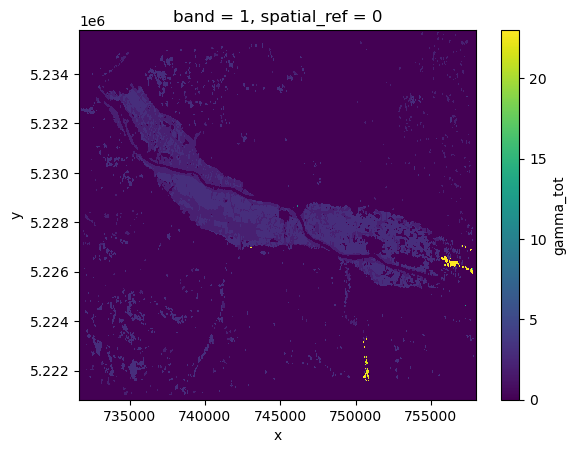

In [10]:
raster.plot()

In [2]:
cmap_ESAWC, normalizer_ESAWC, boundaries_ESAWC, ticks_ESAWC, tick_labels_ESAWC, values_ESAWC = defined_ESAWC_cmap()
cmap_SWOT, normalizer_SWOT, boundaries_SWOT, ticks_SWOT, tick_labels_SWOT, values_SWOT = defined_SWOT_cmap()

# PATHS DEFINITIONS

In [3]:
data_path = "/data/scratch/globc/bonassies/data"
workspace_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples"
project =  'Paper_SWOT'
PortoAlegre = "PortoAlegre"
Chinon = "Chinon"
EMSR692 = "EMSR_692"

PROJECT_PATH = os.path.join(workspace_path, project)
FIGS_FOLDER = os.path.join(PROJECT_PATH, 'Figs')

Chinon_PATH = os.path.join(workspace_path, Chinon)
Chinon_raster_PATH = os.path.join(Chinon_PATH, 'rasters')
Chinon_aux_PATH = os.path.join(Chinon_PATH, 'aux_data')

PortoAlegre_PATH = os.path.join(workspace_path, PortoAlegre)
PortoAlegre_raster_PATH = os.path.join(PortoAlegre_PATH, 'rasters')
PortoAlegre_aux_PATH = os.path.join(PortoAlegre_PATH, 'aux_data')

EMSR692_PATH = os.path.join(workspace_path, EMSR692)
EMSR692_raster_PATH = os.path.join(EMSR692_PATH, 'rasters')
EMSR692_aux_PATH = os.path.join(EMSR692_PATH, 'aux_data')

# Area of Interest

First step is to define an Area of Interest (AOI) for our analysis. 
One efficient method to quickly obtain the desired coordinates is by using the site https://geojson.io/. 
This platform offers an interactive map interface, allowing users to select their region of interest directly on the map.

In [4]:
####
file = os.path.join(PortoAlegre_aux_PATH, 'aoi.gpkg')
bbox_PortoAlegre = gpd.read_file(file)
aoi2_PortoAleger = box(bbox_PortoAlegre.bounds['minx'][0], bbox_PortoAlegre.bounds['miny'][0], bbox_PortoAlegre.bounds['maxx'][0], bbox_PortoAlegre.bounds['maxy'][0])

####
file = os.path.join(Chinon_aux_PATH, 'aoi.gpkg')
bbox_Chinon = gpd.read_file(file)
print(bbox_Chinon)
aoi2_Chinon = box(bbox_Chinon.bounds['minx'][0], bbox_Chinon.bounds['miny'][0], bbox_Chinon.bounds['maxx'][0], bbox_Chinon.bounds['maxy'][0])

####
file = os.path.join(EMSR692_aux_PATH, 'EMSR692_aois_V2.gpkg')
bbox_EMSR692 = gpd.read_file(file)
aoi2_EMSR692 = box(bbox_EMSR692.bounds['minx'][0], bbox_EMSR692.bounds['miny'][0], bbox_EMSR692.bounds['maxx'][0], bbox_EMSR692.bounds['maxy'][0])


                                            geometry
0  POLYGON ((0.06 47.225, 0.06 47.1, 0.4 47.1, 0....


# AUX data loading 

In [6]:
# ------------------------------------------------
# Porto Alegre
# ------------------------------------------------
PortoAlegre_list_var = ['sig0', 'coherent_power', 'incidence', 'gamma_tot', 'gamma_SNR', 'gamma_est', 'height', 'classification', 'bright_land_flag']
EPSG_32722 = "EPSG:32722" # Porto Alegre


PortoAlegre_TotalFlood_file = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/20240506_TotalFlood_delineation_dissolved.gpkg"
PortoAlegre_ControlArea_file = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/ControlArea_32722_v2.gpkg"

# ESA World Cover
PortoAlegre_ESA_WC_file = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/ESA_WorldCover_10m_merged_32722_clip.tif"
PortoAlegre_DEM = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/PortoAlegre/aux_data/FABDEM_merged_32722_clip.tif"

#  Open files
PortoAlegre_mask_flooded = gpd.read_file(PortoAlegre_TotalFlood_file)
PortoAlegre_mask_flooded = PortoAlegre_mask_flooded.to_crs(EPSG_32722)

PortoAlegre_mask_control = gpd.read_file(PortoAlegre_ControlArea_file, layer="ControlArea_32722")
PortoAlegre_mask_control = PortoAlegre_mask_control.to_crs(EPSG_32722)

PortoAlegre_mask_WC = rio.open(PortoAlegre_ESA_WC_file, crs=EPSG_32722)
PortoAlegre_mask_WC_resample, PortoAlegre_transform = rio.mask.mask(PortoAlegre_mask_WC, PortoAlegre_mask_flooded.geometry, crop=True)

PortoAlegre_DEM = rio.open(PortoAlegre_DEM, crs=EPSG_32722)
PortoAlegre_DEM_FloodArea = PortoAlegre_DEM.read(1)

# is forest
PortoAlegre_forest_mask = ~(PortoAlegre_mask_WC_resample == 10)
# is urban
PortoAlegre_urban_mask = ~(PortoAlegre_mask_WC_resample == 50)
# is not open water, not forest, not urban
PortoAlegre_open_mask = ~(PortoAlegre_urban_mask & PortoAlegre_forest_mask & ~(PortoAlegre_mask_WC_resample == 80))

# ------------------------------------------------
# Chinon
# ------------------------------------------------
Chinon_list_var = ['sig0', 'coherent_power', 'incidence', 'gamma_tot', 'gamma_SNR', 'gamma_est', 'power_plus_y', 'power_minus_y',  'interf_real', 'interf_imag', 'height', 'classification', 'bright_land_flag']
EPSG_32630 = "EPSG:32630" # Chinon

# Delineation
Chinon_TotalFlood_file = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon/aux_data/FloodedArea_32630.gpkg"
Chinon_ControlArea_file = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon/aux_data/ControlArea_32630.gpkg"

# ESA World Cover
Chinon_ESA_WC_file = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon/aux_data/ESA_WorldCover_10m_merged_32630_clip.tif"

#FABDEM
Chinon_DEM = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Chinon/aux_data/N47E000_FABDEM_V1-0_32630_cut.tif"

# Open files
Chinon_mask_flooded = gpd.read_file(Chinon_TotalFlood_file)
Chinon_mask_flooded = Chinon_mask_flooded.to_crs(EPSG_32630)

Chinon_mask_control = gpd.read_file(Chinon_ControlArea_file)
Chinon_mask_control = Chinon_mask_control.to_crs(EPSG_32630)

Chinon_mask_WC = rio.open(Chinon_ESA_WC_file, crs=EPSG_32630)
Chinon_mask_WC_resample, Chinon_transform = rio.mask.mask(Chinon_mask_WC, Chinon_mask_flooded.geometry, crop=True)

Chinon_DEM = rio.open(Chinon_DEM, crs=EPSG_32630)
Chinon_DEM_FloodArea = Chinon_DEM.read(1, out_shape=Chinon_mask_WC_resample[0].shape)

# is forest
Chinon_forest_mask = ~(Chinon_mask_WC_resample == 10)
# is urban
Chinon_urban_mask = ~(Chinon_mask_WC_resample == 50)
# is not open water, not forest, not urban
Chinon_open_mask = ~(Chinon_forest_mask & Chinon_urban_mask & ~(Chinon_mask_WC_resample == 80))



# ------------------------------------------------
# EMSR692
# ------------------------------------------------
EMSR692_list_var = ['sig0', 'coherent_power', 'incidence', 'gamma_tot', 'gamma_SNR', 'gamma_est', 'power_plus_y', 'power_minus_y',  'interf_real', 'interf_imag', 'height', 'classification', 'bright_land_flag']
EPSG_32634 = "EPSG:32634" # EMSR692

# Delineation
EMSR692_TotalFlood_file = os.path.join(EMSR692_aux_PATH, "FM_watermask.gpkg")
EMSR692_ControlArea_file = os.path.join(EMSR692_aux_PATH, "ControlArea_32634.gpkg")

# ESA World Cover
EMSR692_ESA_WC_file = os.path.join(EMSR692_aux_PATH, "ESA_WC_cut_V2_32634_nrow5624_ncol4610.tif")
EMSR692_ESA_WC_file = os.path.join(EMSR692_aux_PATH, "ESA_WC_cut_V2_32634_nrow5720_ncol5917.tif")

#FABDEM
EMSR692_DEM = os.path.join(EMSR692_aux_PATH, "FABDEM_fusion_cut_v2_32634_10m.tif")

# Open files
EMSR692_mask_flooded = gpd.read_file(EMSR692_TotalFlood_file)
EMSR692_mask_flooded = EMSR692_mask_flooded.to_crs(EPSG_32634)

EMSR692_mask_control = gpd.read_file(EMSR692_ControlArea_file)
EMSR692_mask_control = EMSR692_mask_control.to_crs(EPSG_32634)

EMSR692_mask_WC = rio.open(EMSR692_ESA_WC_file, crs=EPSG_32634)
EMSR692_mask_WC_resample, EMSR692_transform = rio.mask.mask(EMSR692_mask_WC, EMSR692_mask_flooded.geometry, crop=True)


EMSR692_DEM = rio.open(EMSR692_DEM, crs=EPSG_32634)
EMSR692_DEM_FloodArea = EMSR692_DEM.read(1, out_shape=EMSR692_mask_WC_resample[0].shape)

# is forest
EMSR692_forest_mask = ~(EMSR692_mask_WC_resample == 10)
# is urban
EMSR692_urban_mask = ~(EMSR692_mask_WC_resample == 50)
# is not open water, not forest, not urban
EMSR692_open_mask = ~(EMSR692_forest_mask & EMSR692_urban_mask & ~(EMSR692_mask_WC_resample == 80))

In [8]:
#compute xy position from transform and data
def get_xy_from_transform(transform, data):
    x = np.arange(data.shape[1]) * transform[0] + transform[2]
    y = np.arange(data.shape[0]) * transform[4] + transform[5]
    return x, y


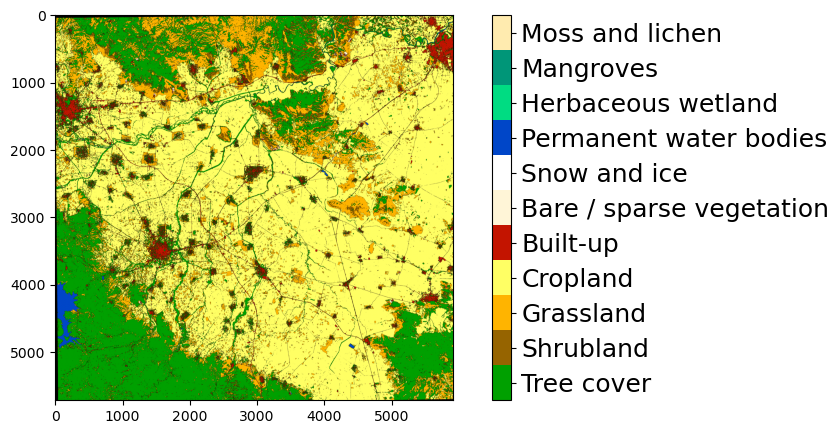

In [7]:
fig,ax = plt.subplots(1,1,figsize=(10,5))

show(EMSR692_mask_WC.read(1), cmap=cmap_ESAWC, ax=ax, norm=normalizer_ESAWC)

colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer_ESAWC, cmap=cmap_ESAWC),
    boundaries=boundaries_ESAWC,
    values=values_ESAWC,
    ax=ax,
)
colorbar.set_ticks(ticks_ESAWC, labels=tick_labels_ESAWC, fontsize=18)

# Dates

Dates d'interets (Porto Alegre):
- Flooded:
    - 2023/10/31
    - 2024/05/06 
- Dry:
    - 2023/12/12
    - 2024/01/23
    - 2024/03/04
    - 2024/03/25
    - 2024/06/17
    - 2024/07/08
    - 2025/02/01
    
Dates d'interets (Chinon):
- Flooded:
    - 31/03/2024
- Dry:
    - 21/04/2024 (still some water)
    - 2024/07/13
    - 2024/08/03
    - 2024/08/24
    - 2024/09/14
    - 2024/10/05
    - 2024/11/16

In [ ]:
PortoAlegre_list_dry_dates = [
    "20240123",
    "20240304",
    "20240325",
    "20250201",
    ]
PortoAlegre_list_flooded_dates = [
    "20231010",
    "20240506",
    ]
Chinon_list_dry_dates = [
    "20240803", 
    "20240824", 
    "20240914", 
    "20241005", 
    ]
Chinon_list_flooded_dates = [
    "20231218",
    "20240331",
    ]

EMSR692_list_dry_dates = [
    "20240410",
    "20240411",
    "20240501"
    ]
EMSR692_list_flooded_dates = [
    "20230915T202311",
    # "20230915T070816"
    ]

PortoAlegre_list_raster = glob.glob(os.path.join(PortoAlegre_raster_PATH, '*.tif'))
PortoAlegre_list_raster.sort()
Chinon_list_raster = glob.glob(os.path.join(Chinon_raster_PATH, '*.tif'))
Chinon_list_raster.sort()
EMSR692_list_raster = glob.glob(os.path.join(EMSR692_raster_PATH, '*.tif'))
EMSR692_list_raster.sort()

PortoAlegre_glob_dry_rasters = [glob.glob(os.path.join(PortoAlegre_raster_PATH, f'*{dry_date}*.tif') )[0] for dry_date in PortoAlegre_list_dry_dates]
Chinon_glob_dry_rasters = [glob.glob(os.path.join(Chinon_raster_PATH, f'*{dry_date}*.tif') )[0] for dry_date in Chinon_list_dry_dates]
EMSR692_glob_dry_rasters = [glob.glob(os.path.join(EMSR692_raster_PATH, f'*{dry_date}*.tif') )[0] for dry_date in EMSR692_list_dry_dates]

PortoAlgre_glob_flooded_rasters = [glob.glob(os.path.join(PortoAlegre_raster_PATH, f'*{flooded_date}*.tif') )[0] for flooded_date in PortoAlegre_list_flooded_dates]
Chinon_glob_flooded_rasters = [glob.glob(os.path.join(Chinon_raster_PATH, f'*{flooded_date}*.tif') )[0] for flooded_date in Chinon_list_flooded_dates]
EMSR692_glob_flooded_rasters = [glob.glob(os.path.join(EMSR692_raster_PATH, f'*{flooded_date}*.tif') )[0] for flooded_date in EMSR692_list_flooded_dates]

PortoAlegre_label_flooded_date = [datetime.datetime.strptime(flooded_date,'%Y%m%d') for flooded_date in PortoAlegre_list_flooded_dates]
PortoAlegre_label_dry_date = [datetime.datetime.strptime(flooded_date,'%Y%m%d') for flooded_date in PortoAlegre_list_dry_dates]
Chinon_label_flooded_date = [datetime.datetime.strptime(flooded_date,'%Y%m%d') for flooded_date in Chinon_list_flooded_dates]
Chinon_label_dry_date = [datetime.datetime.strptime(flooded_date,'%Y%m%d') for flooded_date in Chinon_list_dry_dates]
EMSR692_label_flooded_date = [datetime.datetime.strptime(flooded_date.split('T')[0],'%Y%m%d') for flooded_date in EMSR692_list_flooded_dates]
EMSR692_label_dry_date = [datetime.datetime.strptime(flooded_date,'%Y%m%d') for flooded_date in EMSR692_list_dry_dates]


# Mean dry raster

## Loading rasters list

In [10]:
# Load the rasters
PortoAlegre_dry_rasters = [rio.open(raster) for raster in PortoAlegre_glob_dry_rasters]
PortoAlegre_flooded_rasters = [rio.open(raster) for raster in PortoAlgre_glob_flooded_rasters]

PortoAlegre_FloodedArea_dry_rasters_masked = [rio.mask.mask(raster, PortoAlegre_mask_flooded.geometry, crop=True)[0] for raster in PortoAlegre_dry_rasters]
PortoAlegre_FloodedArea_flooded_raster_masked = [rio.mask.mask(raster, PortoAlegre_mask_flooded.geometry, crop=True)[0] for raster in PortoAlegre_flooded_rasters]

PortoAlegre_ControlArea_dry_rasters_masked = [rio.mask.mask(raster, PortoAlegre_mask_control.geometry, crop=True)[0] for raster in PortoAlegre_dry_rasters]
PortoAlegre_ControlArea_flooded_raster_masked = [rio.mask.mask(raster, PortoAlegre_mask_control.geometry, crop=True)[0] for raster in PortoAlegre_flooded_rasters]

Chinon_dry_rasters = [rio.open(raster) for raster in Chinon_glob_dry_rasters]
Chinon_flooded_rasters = [rio.open(raster) for raster in Chinon_glob_flooded_rasters]

Chinon_FloodedArea_dry_rasters_masked = [rio.mask.mask(raster, Chinon_mask_flooded.geometry, crop=True)[0] for raster in Chinon_dry_rasters]
Chinon_FloodedArea_flooded_raster_masked = [rio.mask.mask(raster, Chinon_mask_flooded.geometry, crop=True)[0] for raster in Chinon_flooded_rasters]

Chinon_ControlArea_dry_rasters_masked = [rio.mask.mask(raster, Chinon_mask_control.geometry, crop=True)[0] for raster in Chinon_dry_rasters]
Chinon_ControlArea_flooded_raster_masked = [rio.mask.mask(raster, Chinon_mask_control.geometry, crop=True)[0] for raster in Chinon_flooded_rasters]


EMSR692_dry_rasters = [rio.open(raster) for raster in EMSR692_glob_dry_rasters]
EMSR692_flooded_rasters = [rio.open(raster) for raster in EMSR692_glob_flooded_rasters]

EMSR692_FloodedArea_dry_rasters_masked = [rio.mask.mask(raster, EMSR692_mask_flooded.geometry, crop=True)[0] for raster in EMSR692_dry_rasters]
EMSR692_FloodedArea_flooded_raster_masked = [rio.mask.mask(raster, EMSR692_mask_flooded.geometry, crop=True)[0] for raster in EMSR692_flooded_rasters]

EMSR692_ControlArea_dry_rasters_masked = [rio.mask.mask(raster, EMSR692_mask_control.geometry, crop=True)[0] for raster in EMSR692_dry_rasters]
EMSR692_ControlArea_flooded_raster_masked = [rio.mask.mask(raster, EMSR692_mask_control.geometry, crop=True)[0] for raster in EMSR692_flooded_rasters]

In [32]:
EMSR692_FloodedArea_dry_rasters_masked[0].shape, EMSR692_mask_WC_resample.shape, EMSR692_FloodedArea_flooded_raster_masked[0].shape

((13, 5601, 4610), (1, 5601, 4610), (13, 5601, 4610))

## Porto Alegre pre-treatment

In [17]:
# ------------------------------------------------
# Porto Alegre
# ------------------------------------------------
# Load the dry rasters
PortoAlegre_FloodArea_sig0_rasters        = np.array([raster[PortoAlegre_list_var.index('sig0')] for raster in PortoAlegre_FloodedArea_dry_rasters_masked])
PortoAlegre_FloodArea_coh_rasters         = np.array([raster[PortoAlegre_list_var.index('coherent_power')] for raster in PortoAlegre_FloodedArea_dry_rasters_masked])
PortoAlegre_FloodArea_gamma_tot_rasters   = np.array([raster[PortoAlegre_list_var.index('gamma_tot')] for raster in PortoAlegre_FloodedArea_dry_rasters_masked])
PortoAlegre_FloodArea_gamma_SNR_rasters   = np.array([raster[PortoAlegre_list_var.index('gamma_SNR')] for raster in PortoAlegre_FloodedArea_dry_rasters_masked])
PortoAlegre_FloodArea_height_rasters      = np.array([raster[PortoAlegre_list_var.index('height')] for raster in PortoAlegre_FloodedArea_dry_rasters_masked])


PortoAlegre_FloodArea_sig0_rasters = np.where(PortoAlegre_FloodArea_sig0_rasters == -9999, np.nan, PortoAlegre_FloodArea_sig0_rasters)
PortoAlegre_FloodArea_coh_rasters  = np.where(PortoAlegre_FloodArea_coh_rasters == -9999,  np.nan, PortoAlegre_FloodArea_coh_rasters)
PortoAlegre_FloodArea_gamma_tot_rasters = np.where(PortoAlegre_FloodArea_gamma_tot_rasters == -9999, np.nan, PortoAlegre_FloodArea_gamma_tot_rasters)
PortoAlegre_FloodArea_gamma_SNR_rasters = np.where(PortoAlegre_FloodArea_gamma_SNR_rasters == -9999, np.nan, PortoAlegre_FloodArea_gamma_SNR_rasters)
PortoAlegre_FloodArea_height_rasters = np.where(PortoAlegre_FloodArea_height_rasters == -9999, np.nan, PortoAlegre_FloodArea_height_rasters)

PortoAlegre_FloodArea_sig0_rasters = np.where(PortoAlegre_FloodArea_sig0_rasters == 0, np.nan, PortoAlegre_FloodArea_sig0_rasters)
PortoAlegre_FloodArea_coh_rasters  = np.where(PortoAlegre_FloodArea_coh_rasters == 0,  np.nan, PortoAlegre_FloodArea_coh_rasters)
PortoAlegre_FloodArea_gamma_tot_rasters = np.where(PortoAlegre_FloodArea_gamma_tot_rasters == 0, np.nan, PortoAlegre_FloodArea_gamma_tot_rasters)
PortoAlegre_FloodArea_gamma_SNR_rasters = np.where(PortoAlegre_FloodArea_gamma_SNR_rasters == 0, np.nan, PortoAlegre_FloodArea_gamma_SNR_rasters)
PortoAlegre_FloodArea_height_rasters = np.where(PortoAlegre_FloodArea_height_rasters == 0, np.nan, PortoAlegre_FloodArea_height_rasters)

PortoAlegre_FloodArea_mean_dry_sig0 = np.nanmean(PortoAlegre_FloodArea_sig0_rasters, axis=0)
PortoAlegre_FloodArea_mean_dry_coh  = np.nanmean(PortoAlegre_FloodArea_coh_rasters, axis=0)
PortoAlegre_FloodArea_mean_dry_gamma_tot = np.nanmean(PortoAlegre_FloodArea_gamma_tot_rasters, axis=0)
PortoAlegre_FloodArea_mean_dry_gamma_SNR = np.nanmean(PortoAlegre_FloodArea_gamma_SNR_rasters, axis=0)
PortoAlegre_FloodArea_mean_dry_height = np.nanmean(PortoAlegre_FloodArea_height_rasters, axis=0)
PortoAlegre_FloodArea_mean_dry_gamma_est = PortoAlegre_FloodArea_mean_dry_gamma_tot / PortoAlegre_FloodArea_mean_dry_gamma_SNR


PortoAlegre_ControlArea_sig0_rasters        = np.array([raster[PortoAlegre_list_var.index('sig0')] for raster in PortoAlegre_ControlArea_dry_rasters_masked])
PortoAlegre_ControlArea_coh_rasters         = np.array([raster[PortoAlegre_list_var.index('coherent_power')] for raster in PortoAlegre_ControlArea_dry_rasters_masked])
PortoAlegre_ControlArea_gamma_tot_rasters   = np.array([raster[PortoAlegre_list_var.index('gamma_tot')] for raster in PortoAlegre_ControlArea_dry_rasters_masked])
PortoAlegre_ControlArea_gamma_SNR_rasters   = np.array([raster[PortoAlegre_list_var.index('gamma_SNR')] for raster in PortoAlegre_ControlArea_dry_rasters_masked])
PortoAlegre_ControlArea_height_rasters      = np.array([raster[PortoAlegre_list_var.index('height')] for raster in PortoAlegre_ControlArea_dry_rasters_masked])


PortoAlegre_ControlArea_sig0_rasters = np.where(PortoAlegre_ControlArea_sig0_rasters == -9999, np.nan, PortoAlegre_ControlArea_sig0_rasters)
PortoAlegre_ControlArea_coh_rasters  = np.where(PortoAlegre_ControlArea_coh_rasters == -9999,  np.nan, PortoAlegre_ControlArea_coh_rasters)
PortoAlegre_ControlArea_gamma_tot_rasters = np.where(PortoAlegre_ControlArea_gamma_tot_rasters == -9999, np.nan, PortoAlegre_ControlArea_gamma_tot_rasters)
PortoAlegre_ControlArea_gamma_SNR_rasters = np.where(PortoAlegre_ControlArea_gamma_SNR_rasters == -9999, np.nan, PortoAlegre_ControlArea_gamma_SNR_rasters)
PortoAlegre_ControlArea_height_rasters = np.where(PortoAlegre_ControlArea_height_rasters == -9999, np.nan, PortoAlegre_ControlArea_height_rasters)

PortoAlegre_ControlArea_sig0_rasters = np.where(PortoAlegre_ControlArea_sig0_rasters == 0, np.nan, PortoAlegre_ControlArea_sig0_rasters)
PortoAlegre_ControlArea_coh_rasters  = np.where(PortoAlegre_ControlArea_coh_rasters == 0,  np.nan, PortoAlegre_ControlArea_coh_rasters)
PortoAlegre_ControlArea_gamma_tot_rasters = np.where(PortoAlegre_ControlArea_gamma_tot_rasters == 0, np.nan, PortoAlegre_ControlArea_gamma_tot_rasters)
PortoAlegre_ControlArea_gamma_SNR_rasters = np.where(PortoAlegre_ControlArea_gamma_SNR_rasters == 0, np.nan, PortoAlegre_ControlArea_gamma_SNR_rasters)
PortoAlegre_ControlArea_height_rasters = np.where(PortoAlegre_ControlArea_height_rasters == 0, np.nan, PortoAlegre_ControlArea_height_rasters)

PortoAlegre_ControlArea_mean_dry_sig0 = np.nanmean(PortoAlegre_ControlArea_sig0_rasters, axis=0)
PortoAlegre_ControlArea_mean_dry_coh  = np.nanmean(PortoAlegre_ControlArea_coh_rasters, axis=0)
PortoAlegre_ControlArea_mean_dry_gamma_tot = np.nanmean(PortoAlegre_ControlArea_gamma_tot_rasters, axis=0)
PortoAlegre_ControlArea_mean_dry_gamma_SNR = np.nanmean(PortoAlegre_ControlArea_gamma_SNR_rasters, axis=0)
PortoAlegre_ControlArea_mean_dry_height = np.nanmean(PortoAlegre_ControlArea_height_rasters, axis=0)
PortoAlegre_ControlArea_mean_dry_gamma_est = PortoAlegre_ControlArea_mean_dry_gamma_tot / PortoAlegre_ControlArea_mean_dry_gamma_SNR


# Load the flooded raster
PortoAlegre_FloodArea_flooded_sig0         = np.array([raster[PortoAlegre_list_var.index('sig0')] for raster in PortoAlegre_FloodedArea_flooded_raster_masked])
PortoAlegre_FloodArea_flooded_coh          = np.array([raster[PortoAlegre_list_var.index('coherent_power')] for raster in PortoAlegre_FloodedArea_flooded_raster_masked])
PortoAlegre_FloodArea_flooded_gamma_tot    = np.array([raster[PortoAlegre_list_var.index('gamma_tot')] for raster in PortoAlegre_FloodedArea_flooded_raster_masked])
PortoAlegre_FloodArea_flooded_gamma_SNR    = np.array([raster[PortoAlegre_list_var.index('gamma_SNR')] for raster in PortoAlegre_FloodedArea_flooded_raster_masked])
PortoAlegre_FloodArea_flooded_height       = np.array([raster[PortoAlegre_list_var.index('height')] for raster in PortoAlegre_FloodedArea_flooded_raster_masked])

PortoAlegre_FloodArea_flooded_sig0 = np.where(PortoAlegre_FloodArea_flooded_sig0 == -9999, np.nan, PortoAlegre_FloodArea_flooded_sig0)
PortoAlegre_FloodArea_flooded_coh  = np.where(PortoAlegre_FloodArea_flooded_coh == -9999, np.nan,PortoAlegre_FloodArea_flooded_coh)
PortoAlegre_FloodArea_flooded_gamma_tot = np.where(PortoAlegre_FloodArea_flooded_gamma_tot == -9999, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot)
PortoAlegre_FloodArea_flooded_gamma_SNR = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR == -9999, np.nan, PortoAlegre_FloodArea_flooded_gamma_SNR)
PortoAlegre_FloodArea_flooded_height = np.where(PortoAlegre_FloodArea_flooded_height == -9999, np.nan, PortoAlegre_FloodArea_flooded_height)

PortoAlegre_FloodArea_flooded_sig0 = np.where(PortoAlegre_FloodArea_flooded_sig0 == 0, np.nan, PortoAlegre_FloodArea_flooded_sig0)
PortoAlegre_FloodArea_flooded_coh  = np.where(PortoAlegre_FloodArea_flooded_coh == 0, np.nan, PortoAlegre_FloodArea_flooded_coh)
PortoAlegre_FloodArea_flooded_gamma_tot = np.where(PortoAlegre_FloodArea_flooded_gamma_tot == 0, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot)
PortoAlegre_FloodArea_flooded_gamma_SNR = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR == 0, np.nan, PortoAlegre_FloodArea_flooded_gamma_SNR)
PortoAlegre_FloodArea_flooded_height = np.where(PortoAlegre_FloodArea_flooded_height == 0, np.nan, PortoAlegre_FloodArea_flooded_height)

# PortoAlegre_FloodArea_flooded_gamma_tot[1] = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<0.6, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot[1])
# PortoAlegre_FloodArea_flooded_coh[1] = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<0.6, np.nan, PortoAlegre_FloodArea_flooded_coh[1])
# PortoAlegre_FloodArea_flooded_sig0[1] = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<0.6, np.nan, PortoAlegre_FloodArea_flooded_sig0[1])
# PortoAlegre_FloodArea_flooded_height[1] = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<0.6, np.nan, PortoAlegre_FloodArea_flooded_height[1])

PortoAlegre_FloodArea_flooded_gamma_tot = np.where(PortoAlegre_FloodArea_mean_dry_gamma_tot==np.nan, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot)
PortoAlegre_FloodArea_flooded_coh = np.where(PortoAlegre_FloodArea_mean_dry_coh==np.nan, np.nan, PortoAlegre_FloodArea_flooded_coh)
PortoAlegre_FloodArea_flooded_sig0 = np.where(PortoAlegre_FloodArea_mean_dry_sig0==np.nan, np.nan, PortoAlegre_FloodArea_flooded_sig0)
PortoAlegre_FloodArea_flooded_height = np.where(PortoAlegre_FloodArea_mean_dry_height==np.nan, np.nan, PortoAlegre_FloodArea_flooded_height)

PortoAlegre_FloodArea_mean_dry_gamma_tot = np.where(PortoAlegre_FloodArea_mean_dry_gamma_tot==np.nan, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_tot)
PortoAlegre_FloodArea_mean_dry_coh = np.where(PortoAlegre_FloodArea_mean_dry_coh==np.nan, np.nan, PortoAlegre_FloodArea_mean_dry_coh)
PortoAlegre_FloodArea_mean_dry_sig0 = np.where(PortoAlegre_FloodArea_mean_dry_sig0==np.nan, np.nan, PortoAlegre_FloodArea_mean_dry_sig0)
PortoAlegre_FloodArea_mean_dry_height = np.where(PortoAlegre_FloodArea_mean_dry_height==np.nan, np.nan, PortoAlegre_FloodArea_mean_dry_height)

PortoAlegre_FloodArea_flooded_gamma_est = PortoAlegre_FloodArea_flooded_gamma_tot / PortoAlegre_FloodArea_flooded_gamma_SNR
PortoAlegre_FloodArea_flooded_sig0 = np.log10(PortoAlegre_FloodArea_flooded_sig0) * 10
PortoAlegre_FloodArea_mean_dry_sig0 = np.log10(PortoAlegre_FloodArea_mean_dry_sig0) * 10
PortoAlegre_FloodArea_flooded_coh = np.log10(PortoAlegre_FloodArea_flooded_coh) * 10
PortoAlegre_FloodArea_mean_dry_coh = np.log10(PortoAlegre_FloodArea_mean_dry_coh) * 10


PortoAlegre_ControlArea_flooded_sig0         = np.array([raster[PortoAlegre_list_var.index('sig0')] for raster in PortoAlegre_ControlArea_flooded_raster_masked])
PortoAlegre_ControlArea_flooded_coh          = np.array([raster[PortoAlegre_list_var.index('coherent_power')] for raster in PortoAlegre_ControlArea_flooded_raster_masked])
PortoAlegre_ControlArea_flooded_gamma_tot    = np.array([raster[PortoAlegre_list_var.index('gamma_tot')] for raster in PortoAlegre_ControlArea_flooded_raster_masked])
PortoAlegre_ControlArea_flooded_gamma_SNR    = np.array([raster[PortoAlegre_list_var.index('gamma_SNR')] for raster in PortoAlegre_ControlArea_flooded_raster_masked])
PortoAlegre_ControlArea_flooded_height       = np.array([raster[PortoAlegre_list_var.index('height')] for raster in PortoAlegre_ControlArea_flooded_raster_masked])

PortoAlegre_ControlArea_flooded_sig0 = np.where(PortoAlegre_ControlArea_flooded_sig0 == -9999, np.nan, PortoAlegre_ControlArea_flooded_sig0)
PortoAlegre_ControlArea_flooded_coh  = np.where(PortoAlegre_ControlArea_flooded_coh == -9999, np.nan,PortoAlegre_ControlArea_flooded_coh)
PortoAlegre_ControlArea_flooded_gamma_tot = np.where(PortoAlegre_ControlArea_flooded_gamma_tot == -9999, np.nan, PortoAlegre_ControlArea_flooded_gamma_tot)
PortoAlegre_ControlArea_flooded_gamma_SNR = np.where(PortoAlegre_ControlArea_flooded_gamma_SNR == -9999, np.nan, PortoAlegre_ControlArea_flooded_gamma_SNR)
PortoAlegre_ControlArea_flooded_height = np.where(PortoAlegre_ControlArea_flooded_height == -9999, np.nan, PortoAlegre_ControlArea_flooded_height)

PortoAlegre_ControlArea_flooded_sig0 = np.where(PortoAlegre_ControlArea_flooded_sig0 == 0, np.nan, PortoAlegre_ControlArea_flooded_sig0)
PortoAlegre_ControlArea_flooded_coh  = np.where(PortoAlegre_ControlArea_flooded_coh == 0, np.nan, PortoAlegre_ControlArea_flooded_coh)
PortoAlegre_ControlArea_flooded_gamma_tot = np.where(PortoAlegre_ControlArea_flooded_gamma_tot == 0, np.nan, PortoAlegre_ControlArea_flooded_gamma_tot)
PortoAlegre_ControlArea_flooded_gamma_SNR = np.where(PortoAlegre_ControlArea_flooded_gamma_SNR == 0, np.nan, PortoAlegre_ControlArea_flooded_gamma_SNR)
PortoAlegre_ControlArea_flooded_height = np.where(PortoAlegre_ControlArea_flooded_height == 0, np.nan, PortoAlegre_ControlArea_flooded_height)

PortoAlegre_ControlArea_flooded_gamma_est = PortoAlegre_ControlArea_flooded_gamma_tot / PortoAlegre_ControlArea_flooded_gamma_SNR
PortoAlegre_ControlArea_flooded_sig0 = np.log10(PortoAlegre_ControlArea_flooded_sig0) * 10
PortoAlegre_ControlArea_mean_dry_sig0 = np.log10(PortoAlegre_ControlArea_mean_dry_sig0) * 10
PortoAlegre_ControlArea_flooded_coh = np.log10(PortoAlegre_ControlArea_flooded_coh) * 10
PortoAlegre_ControlArea_mean_dry_coh = np.log10(PortoAlegre_ControlArea_mean_dry_coh) * 10

# apply WC mask
PortoAlegre_forest_flooded_sig0 = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_flooded_sig0)
PortoAlegre_forest_flooded_coh = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_flooded_coh)
PortoAlegre_forest_flooded_gamma_tot = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot)
PortoAlegre_forest_flooded_gamma_SNR = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_SNR)
PortoAlegre_forest_flooded_gamma_est = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_est)
PortoAlegre_forest_flooded_height = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_flooded_height)

PortoAlegre_forest_mean_dry_sig0 = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_mean_dry_sig0)
PortoAlegre_forest_mean_dry_coh = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_mean_dry_coh)
PortoAlegre_forest_mean_dry_gamma_tot = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_tot)
PortoAlegre_forest_mean_dry_gamma_SNR = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_SNR)
PortoAlegre_forest_mean_dry_gamma_est = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_est)
PortoAlegre_forest_mean_dry_height = np.where(PortoAlegre_forest_mask, np.nan, PortoAlegre_FloodArea_mean_dry_height)


# apply WC mask
PortoAlegre_urban_flooded_sig0 = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_flooded_sig0)
PortoAlegre_urban_flooded_coh = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_flooded_coh)
PortoAlegre_urban_flooded_gamma_tot = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot)
PortoAlegre_urban_flooded_gamma_SNR = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_SNR)
PortoAlegre_urban_flooded_gamma_est = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_est)
PortoAlegre_urban_flooded_height = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_flooded_height)

PortoAlegre_urban_mean_dry_sig0 = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_mean_dry_sig0)
PortoAlegre_urban_mean_dry_coh = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_mean_dry_coh)
PortoAlegre_urban_mean_dry_gamma_tot = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_tot)
PortoAlegre_urban_mean_dry_gamma_SNR = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_SNR)
PortoAlegre_urban_mean_dry_gamma_est = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_est)
PortoAlegre_urban_mean_dry_height = np.where(PortoAlegre_urban_mask, np.nan, PortoAlegre_FloodArea_mean_dry_height)



# apply WC mask
PortoAlegre_open_flooded_sig0 = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_flooded_sig0)
PortoAlegre_open_flooded_coh = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_flooded_coh)
PortoAlegre_open_flooded_gamma_tot = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot)
PortoAlegre_open_flooded_gamma_SNR = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_SNR)
PortoAlegre_open_flooded_gamma_est = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_flooded_gamma_est)
PortoAlegre_open_flooded_height = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_flooded_height)

PortoAlegre_open_mean_dry_sig0 = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_mean_dry_sig0)
PortoAlegre_open_mean_dry_coh = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_mean_dry_coh)
PortoAlegre_open_mean_dry_gamma_tot = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_tot)
PortoAlegre_open_mean_dry_gamma_SNR = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_SNR)
PortoAlegre_open_mean_dry_gamma_est = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_est)
PortoAlegre_open_mean_dry_height = np.where(PortoAlegre_open_mask, np.nan, PortoAlegre_FloodArea_mean_dry_height)



/tmp/ipykernel_2366530/3927268225.py:24: RuntimeWarning: Mean of empty slice
  PortoAlegre_FloodArea_mean_dry_sig0 = np.nanmean(PortoAlegre_FloodArea_sig0_rasters, axis=0)
/tmp/ipykernel_2366530/3927268225.py:25: RuntimeWarning: Mean of empty slice
  PortoAlegre_FloodArea_mean_dry_coh  = np.nanmean(PortoAlegre_FloodArea_coh_rasters, axis=0)
/tmp/ipykernel_2366530/3927268225.py:26: RuntimeWarning: Mean of empty slice
  PortoAlegre_FloodArea_mean_dry_gamma_tot = np.nanmean(PortoAlegre_FloodArea_gamma_tot_rasters, axis=0)
/tmp/ipykernel_2366530/3927268225.py:27: RuntimeWarning: Mean of empty slice
  PortoAlegre_FloodArea_mean_dry_gamma_SNR = np.nanmean(PortoAlegre_FloodArea_gamma_SNR_rasters, axis=0)
/tmp/ipykernel_2366530/3927268225.py:28: RuntimeWarning: Mean of empty slice
  PortoAlegre_FloodArea_mean_dry_height = np.nanmean(PortoAlegre_FloodArea_height_rasters, axis=0)
/tmp/ipykernel_2366530/3927268225.py:51: RuntimeWarning: Mean of empty slice
  PortoAlegre_ControlArea_mean_dry_sig0 

In [11]:
# threshold_SNR = 0.5

# PortoAlegre_FloodArea_flooded_gamma_tot_SNR_filtered = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<threshold_SNR, np.nan, PortoAlegre_FloodArea_flooded_gamma_tot[1])
# PortoAlegre_FloodArea_flooded_coh_SNR_filtered = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<threshold_SNR, np.nan, PortoAlegre_FloodArea_flooded_coh[1])
# PortoAlegre_FloodArea_flooded_sig0_SNR_filtered = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<threshold_SNR, np.nan, PortoAlegre_FloodArea_flooded_sig0[1])
# PortoAlegre_FloodArea_flooded_height_SNR_filtered = np.where(PortoAlegre_FloodArea_flooded_gamma_SNR[1]<threshold_SNR, np.nan, PortoAlegre_FloodArea_flooded_height[1])
# PortoAlegre_FloodArea_mean_dry_gamma_tot_SNR_filtered = np.where(PortoAlegre_FloodArea_mean_dry_gamma_SNR<threshold_SNR, np.nan, PortoAlegre_FloodArea_mean_dry_gamma_tot)

# test_raster = PortoAlegre_flooded_rasters[1]
# test_gamma_tot = test_raster.read(4)
# test_coh = test_raster.read(PortoAlegre_list_var.index('coherent_power')+1)
# test_classif = test_raster.read(PortoAlegre_list_var.index('classification')+1)
# test_SNR = test_raster.read(5)
# test_gamma_tot = np.where(test_gamma_tot == -9999, np.nan, test_gamma_tot)
# test_SNR = np.where(test_SNR == -9999, np.nan, test_SNR)
# test_gamma_tot = np.where(test_gamma_tot == 0, np.nan, test_gamma_tot)
# # test_SNR = np.where(test_SNR == 0, np.nan, test_SNR)
# # test_gamma_tot = np.where(test_SNR<threshold_SNR, np.nan, test_gamma_tot)

# test_gamma_tot = test_gamma_tot[:,:]
# test_SNR_filter = (test_SNR[:,:] < threshold_SNR)*1
# classif_bad = np.where(test_classif==5, 3, 0)
# test_PA = PortoAlegre_FloodArea_flooded_gamma_tot_SNR_filtered[:,:] - PortoAlegre_FloodArea_mean_dry_gamma_tot_SNR_filtered[:,:]
# # plt.hist(test_SNR.flatten(), bins=100, range=(0,1))
# # plt.title('Gamma SNR (unfiltered)')
# # plt.show()
# plt.imshow(test_SNR, vmin=0, vmax=1)
# plt.title('Gamma SNR (unfiltered)')
# plt.colorbar()
# plt.show()
# plt.imshow(test_gamma_tot, vmin=0, vmax=1)
# plt.title('Gamma total (unfiltered)')
# plt.colorbar()
# plt.show()
# # plt.imshow((test_coh<1e5)*1, vmin=0, vmax=1)
# # plt.title('coherent power')
# # plt.colorbar()
# # plt.show()

# # from matplotlib.colors import ListedColormap
# # cmap = ListedColormap(["white", "gold", "blue", "red"])
# # combined = test_SNR_filter+classif_bad
# # combined = np.where(combined==4, 2, combined)
# # plt.imshow(combined, vmin=-0., vmax=3., cmap=cmap)
# # plt.title('SNR + classif dark-warter')
# # plt.colorbar()
# # plt.show()

## Chinon pre-treatment

In [10]:
# ------------------------------------------------
# Chinon
# ------------------------------------------------
# Load the dry rasters
Chinon_FloodArea_sig0_rasters        = np.array([raster[Chinon_list_var.index('sig0')] for raster in Chinon_FloodedArea_dry_rasters_masked])
Chinon_FloodArea_coh_rasters         = np.array([raster[Chinon_list_var.index('coherent_power')] for raster in Chinon_FloodedArea_dry_rasters_masked])
Chinon_FloodArea_gamma_tot_rasters   = np.array([raster[Chinon_list_var.index('gamma_tot')] for raster in Chinon_FloodedArea_dry_rasters_masked])
Chinon_FloodArea_gamma_SNR_rasters   = np.array([raster[Chinon_list_var.index('gamma_SNR')] for raster in Chinon_FloodedArea_dry_rasters_masked])
Chinon_FloodArea_height_rasters      = np.array([raster[Chinon_list_var.index('height')] for raster in Chinon_FloodedArea_dry_rasters_masked])


Chinon_FloodArea_sig0_rasters = np.where(Chinon_FloodArea_sig0_rasters == -9999, np.nan, Chinon_FloodArea_sig0_rasters)
Chinon_FloodArea_coh_rasters  = np.where(Chinon_FloodArea_coh_rasters == -9999,  np.nan, Chinon_FloodArea_coh_rasters)
Chinon_FloodArea_gamma_tot_rasters = np.where(Chinon_FloodArea_gamma_tot_rasters == -9999, np.nan, Chinon_FloodArea_gamma_tot_rasters)
Chinon_FloodArea_gamma_SNR_rasters = np.where(Chinon_FloodArea_gamma_SNR_rasters == -9999, np.nan, Chinon_FloodArea_gamma_SNR_rasters)
Chinon_FloodArea_height_rasters = np.where(Chinon_FloodArea_height_rasters == -9999, np.nan, Chinon_FloodArea_height_rasters)

Chinon_FloodArea_sig0_rasters = np.where(Chinon_FloodArea_sig0_rasters == 0, np.nan, Chinon_FloodArea_sig0_rasters)
Chinon_FloodArea_coh_rasters  = np.where(Chinon_FloodArea_coh_rasters == 0,  np.nan, Chinon_FloodArea_coh_rasters)
Chinon_FloodArea_gamma_tot_rasters = np.where(Chinon_FloodArea_gamma_tot_rasters == 0, np.nan, Chinon_FloodArea_gamma_tot_rasters)
Chinon_FloodArea_gamma_SNR_rasters = np.where(Chinon_FloodArea_gamma_SNR_rasters == 0, np.nan, Chinon_FloodArea_gamma_SNR_rasters)
Chinon_FloodArea_height_rasters = np.where(Chinon_FloodArea_height_rasters == 0, np.nan, Chinon_FloodArea_height_rasters)

Chinon_FloodArea_mean_dry_sig0 = np.nanmean(Chinon_FloodArea_sig0_rasters, axis=0)
Chinon_FloodArea_mean_dry_coh  = np.nanmean(Chinon_FloodArea_coh_rasters, axis=0)
Chinon_FloodArea_mean_dry_gamma_tot = np.nanmean(Chinon_FloodArea_gamma_tot_rasters, axis=0)
Chinon_FloodArea_mean_dry_gamma_SNR = np.nanmean(Chinon_FloodArea_gamma_SNR_rasters, axis=0)
Chinon_FloodArea_mean_dry_height = np.nanmean(Chinon_FloodArea_height_rasters, axis=0)
Chinon_FloodArea_mean_dry_gamma_est = Chinon_FloodArea_mean_dry_gamma_tot / Chinon_FloodArea_mean_dry_gamma_SNR


Chinon_ControlArea_sig0_rasters        = np.array([raster[Chinon_list_var.index('sig0')] for raster in Chinon_ControlArea_dry_rasters_masked])
Chinon_ControlArea_coh_rasters         = np.array([raster[Chinon_list_var.index('coherent_power')] for raster in Chinon_ControlArea_dry_rasters_masked])
Chinon_ControlArea_gamma_tot_rasters   = np.array([raster[Chinon_list_var.index('gamma_tot')] for raster in Chinon_ControlArea_dry_rasters_masked])
Chinon_ControlArea_gamma_SNR_rasters   = np.array([raster[Chinon_list_var.index('gamma_SNR')] for raster in Chinon_ControlArea_dry_rasters_masked])
Chinon_ControlArea_height_rasters      = np.array([raster[Chinon_list_var.index('height')] for raster in Chinon_ControlArea_dry_rasters_masked])


Chinon_ControlArea_sig0_rasters = np.where(Chinon_ControlArea_sig0_rasters == -9999, np.nan, Chinon_ControlArea_sig0_rasters)
Chinon_ControlArea_coh_rasters  = np.where(Chinon_ControlArea_coh_rasters == -9999,  np.nan, Chinon_ControlArea_coh_rasters)
Chinon_ControlArea_gamma_tot_rasters = np.where(Chinon_ControlArea_gamma_tot_rasters == -9999, np.nan, Chinon_ControlArea_gamma_tot_rasters)
Chinon_ControlArea_gamma_SNR_rasters = np.where(Chinon_ControlArea_gamma_SNR_rasters == -9999, np.nan, Chinon_ControlArea_gamma_SNR_rasters)
Chinon_ControlArea_height_rasters = np.where(Chinon_ControlArea_height_rasters == -9999, np.nan, Chinon_ControlArea_height_rasters)

Chinon_ControlArea_sig0_rasters = np.where(Chinon_ControlArea_sig0_rasters == 0, np.nan, Chinon_ControlArea_sig0_rasters)
Chinon_ControlArea_coh_rasters  = np.where(Chinon_ControlArea_coh_rasters == 0,  np.nan, Chinon_ControlArea_coh_rasters)
Chinon_ControlArea_gamma_tot_rasters = np.where(Chinon_ControlArea_gamma_tot_rasters == 0, np.nan, Chinon_ControlArea_gamma_tot_rasters)
Chinon_ControlArea_gamma_SNR_rasters = np.where(Chinon_ControlArea_gamma_SNR_rasters == 0, np.nan, Chinon_ControlArea_gamma_SNR_rasters)
Chinon_ControlArea_height_rasters = np.where(Chinon_ControlArea_height_rasters == 0, np.nan, Chinon_ControlArea_height_rasters)

Chinon_ControlArea_mean_dry_sig0 = np.nanmean(Chinon_ControlArea_sig0_rasters, axis=0)
Chinon_ControlArea_mean_dry_coh  = np.nanmean(Chinon_ControlArea_coh_rasters, axis=0)
Chinon_ControlArea_mean_dry_gamma_tot = np.nanmean(Chinon_ControlArea_gamma_tot_rasters, axis=0)
Chinon_ControlArea_mean_dry_gamma_SNR = np.nanmean(Chinon_ControlArea_gamma_SNR_rasters, axis=0)
Chinon_ControlArea_mean_dry_height = np.nanmean(Chinon_ControlArea_height_rasters, axis=0)
Chinon_ControlArea_mean_dry_gamma_est = Chinon_ControlArea_mean_dry_gamma_tot / Chinon_ControlArea_mean_dry_gamma_SNR


# Load the flooded raster
Chinon_FloodArea_flooded_sig0         = np.array([raster[Chinon_list_var.index('sig0')] for raster in Chinon_FloodedArea_flooded_raster_masked])
Chinon_FloodArea_flooded_coh          = np.array([raster[Chinon_list_var.index('coherent_power')] for raster in Chinon_FloodedArea_flooded_raster_masked])
Chinon_FloodArea_flooded_gamma_tot    = np.array([raster[Chinon_list_var.index('gamma_tot')] for raster in Chinon_FloodedArea_flooded_raster_masked])
Chinon_FloodArea_flooded_gamma_SNR    = np.array([raster[Chinon_list_var.index('gamma_SNR')] for raster in Chinon_FloodedArea_flooded_raster_masked])
Chinon_FloodArea_flooded_height       = np.array([raster[Chinon_list_var.index('height')] for raster in Chinon_FloodedArea_flooded_raster_masked])

Chinon_FloodArea_flooded_sig0 = np.where(Chinon_FloodArea_flooded_sig0 == -9999, np.nan, Chinon_FloodArea_flooded_sig0)
Chinon_FloodArea_flooded_coh  = np.where(Chinon_FloodArea_flooded_coh == -9999, np.nan,Chinon_FloodArea_flooded_coh)
Chinon_FloodArea_flooded_gamma_tot = np.where(Chinon_FloodArea_flooded_gamma_tot == -9999, np.nan, Chinon_FloodArea_flooded_gamma_tot)
Chinon_FloodArea_flooded_gamma_SNR = np.where(Chinon_FloodArea_flooded_gamma_SNR == -9999, np.nan, Chinon_FloodArea_flooded_gamma_SNR)
Chinon_FloodArea_flooded_height = np.where(Chinon_FloodArea_flooded_height == -9999, np.nan, Chinon_FloodArea_flooded_height)

Chinon_FloodArea_flooded_sig0 = np.where(Chinon_FloodArea_flooded_sig0 == 0, np.nan, Chinon_FloodArea_flooded_sig0)
Chinon_FloodArea_flooded_coh  = np.where(Chinon_FloodArea_flooded_coh == 0, np.nan, Chinon_FloodArea_flooded_coh)
Chinon_FloodArea_flooded_gamma_tot = np.where(Chinon_FloodArea_flooded_gamma_tot == 0, np.nan, Chinon_FloodArea_flooded_gamma_tot)
Chinon_FloodArea_flooded_gamma_SNR = np.where(Chinon_FloodArea_flooded_gamma_SNR == 0, np.nan, Chinon_FloodArea_flooded_gamma_SNR)
Chinon_FloodArea_flooded_height = np.where(Chinon_FloodArea_flooded_height == 0, np.nan, Chinon_FloodArea_flooded_height)

Chinon_FloodArea_flooded_gamma_est = Chinon_FloodArea_flooded_gamma_tot / Chinon_FloodArea_flooded_gamma_SNR
Chinon_FloodArea_flooded_sig0 = np.log10(Chinon_FloodArea_flooded_sig0) * 10
Chinon_FloodArea_mean_dry_sig0 = np.log10(Chinon_FloodArea_mean_dry_sig0) * 10
Chinon_FloodArea_flooded_coh = np.log10(Chinon_FloodArea_flooded_coh) * 10
Chinon_FloodArea_mean_dry_coh = np.log10(Chinon_FloodArea_mean_dry_coh) * 10


Chinon_ControlArea_flooded_sig0         = np.array([raster[Chinon_list_var.index('sig0')] for raster in Chinon_ControlArea_flooded_raster_masked])
Chinon_ControlArea_flooded_coh          = np.array([raster[Chinon_list_var.index('coherent_power')] for raster in Chinon_ControlArea_flooded_raster_masked])
Chinon_ControlArea_flooded_gamma_tot    = np.array([raster[Chinon_list_var.index('gamma_tot')] for raster in Chinon_ControlArea_flooded_raster_masked])
Chinon_ControlArea_flooded_gamma_SNR    = np.array([raster[Chinon_list_var.index('gamma_SNR')] for raster in Chinon_ControlArea_flooded_raster_masked])
Chinon_ControlArea_flooded_height       = np.array([raster[Chinon_list_var.index('height')] for raster in Chinon_ControlArea_flooded_raster_masked])

Chinon_ControlArea_flooded_sig0 = np.where(Chinon_ControlArea_flooded_sig0 == -9999, np.nan, Chinon_ControlArea_flooded_sig0)
Chinon_ControlArea_flooded_coh  = np.where(Chinon_ControlArea_flooded_coh == -9999, np.nan,Chinon_ControlArea_flooded_coh)
Chinon_ControlArea_flooded_gamma_tot = np.where(Chinon_ControlArea_flooded_gamma_tot == -9999, np.nan, Chinon_ControlArea_flooded_gamma_tot)
Chinon_ControlArea_flooded_gamma_SNR = np.where(Chinon_ControlArea_flooded_gamma_SNR == -9999, np.nan, Chinon_ControlArea_flooded_gamma_SNR)
Chinon_ControlArea_flooded_height = np.where(Chinon_ControlArea_flooded_height == -9999, np.nan, Chinon_ControlArea_flooded_height)

Chinon_ControlArea_flooded_sig0 = np.where(Chinon_ControlArea_flooded_sig0 == 0, np.nan, Chinon_ControlArea_flooded_sig0)
Chinon_ControlArea_flooded_coh  = np.where(Chinon_ControlArea_flooded_coh == 0, np.nan, Chinon_ControlArea_flooded_coh)
Chinon_ControlArea_flooded_gamma_tot = np.where(Chinon_ControlArea_flooded_gamma_tot == 0, np.nan, Chinon_ControlArea_flooded_gamma_tot)
Chinon_ControlArea_flooded_gamma_SNR = np.where(Chinon_ControlArea_flooded_gamma_SNR == 0, np.nan, Chinon_ControlArea_flooded_gamma_SNR)
Chinon_ControlArea_flooded_height = np.where(Chinon_ControlArea_flooded_height == 0, np.nan, Chinon_ControlArea_flooded_height)

Chinon_ControlArea_flooded_gamma_est = Chinon_ControlArea_flooded_gamma_tot / Chinon_ControlArea_flooded_gamma_SNR
Chinon_ControlArea_flooded_sig0 = np.log10(Chinon_ControlArea_flooded_sig0) * 10
Chinon_ControlArea_mean_dry_sig0 = np.log10(Chinon_ControlArea_mean_dry_sig0) * 10
Chinon_ControlArea_flooded_coh = np.log10(Chinon_ControlArea_flooded_coh) * 10
Chinon_ControlArea_mean_dry_coh = np.log10(Chinon_ControlArea_mean_dry_coh) * 10

# apply WC mask
Chinon_forest_flooded_sig0 = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_flooded_sig0)
Chinon_forest_flooded_coh = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_flooded_coh)
Chinon_forest_flooded_gamma_tot = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_flooded_gamma_tot)
Chinon_forest_flooded_gamma_SNR = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_flooded_gamma_SNR)
Chinon_forest_flooded_gamma_est = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_flooded_gamma_est)
Chinon_forest_flooded_height = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_flooded_height)

Chinon_forest_mean_dry_sig0 = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_mean_dry_sig0)
Chinon_forest_mean_dry_coh = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_mean_dry_coh)
Chinon_forest_mean_dry_gamma_tot = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_tot)
Chinon_forest_mean_dry_gamma_SNR = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_SNR)
Chinon_forest_mean_dry_gamma_est = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_est)
Chinon_forest_mean_dry_height = np.where(Chinon_forest_mask, np.nan, Chinon_FloodArea_mean_dry_height)


# apply WC mask
Chinon_urban_flooded_sig0 = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_flooded_sig0)
Chinon_urban_flooded_coh = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_flooded_coh)
Chinon_urban_flooded_gamma_tot = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_flooded_gamma_tot)
Chinon_urban_flooded_gamma_SNR = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_flooded_gamma_SNR)
Chinon_urban_flooded_gamma_est = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_flooded_gamma_est)
Chinon_urban_flooded_height = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_flooded_height)

Chinon_urban_mean_dry_sig0 = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_mean_dry_sig0)
Chinon_urban_mean_dry_coh = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_mean_dry_coh)
Chinon_urban_mean_dry_gamma_tot = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_tot)
Chinon_urban_mean_dry_gamma_SNR = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_SNR)
Chinon_urban_mean_dry_gamma_est = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_est)
Chinon_urban_mean_dry_height = np.where(Chinon_urban_mask, np.nan, Chinon_FloodArea_mean_dry_height)



# apply WC mask
Chinon_open_flooded_sig0 = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_flooded_sig0)
Chinon_open_flooded_coh = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_flooded_coh)
Chinon_open_flooded_gamma_tot = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_flooded_gamma_tot)
Chinon_open_flooded_gamma_SNR = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_flooded_gamma_SNR)
Chinon_open_flooded_gamma_est = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_flooded_gamma_est)
Chinon_open_flooded_height = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_flooded_height)

Chinon_open_mean_dry_sig0 = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_mean_dry_sig0)
Chinon_open_mean_dry_coh = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_mean_dry_coh)
Chinon_open_mean_dry_gamma_tot = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_tot)
Chinon_open_mean_dry_gamma_SNR = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_SNR)
Chinon_open_mean_dry_gamma_est = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_mean_dry_gamma_est)
Chinon_open_mean_dry_height = np.where(Chinon_open_mask, np.nan, Chinon_FloodArea_mean_dry_height)


/tmp/ipykernel_2366530/3044794730.py:24: RuntimeWarning: Mean of empty slice
  Chinon_FloodArea_mean_dry_sig0 = np.nanmean(Chinon_FloodArea_sig0_rasters, axis=0)
/tmp/ipykernel_2366530/3044794730.py:25: RuntimeWarning: Mean of empty slice
  Chinon_FloodArea_mean_dry_coh  = np.nanmean(Chinon_FloodArea_coh_rasters, axis=0)
/tmp/ipykernel_2366530/3044794730.py:26: RuntimeWarning: Mean of empty slice
  Chinon_FloodArea_mean_dry_gamma_tot = np.nanmean(Chinon_FloodArea_gamma_tot_rasters, axis=0)
/tmp/ipykernel_2366530/3044794730.py:27: RuntimeWarning: Mean of empty slice
  Chinon_FloodArea_mean_dry_gamma_SNR = np.nanmean(Chinon_FloodArea_gamma_SNR_rasters, axis=0)
/tmp/ipykernel_2366530/3044794730.py:28: RuntimeWarning: Mean of empty slice
  Chinon_FloodArea_mean_dry_height = np.nanmean(Chinon_FloodArea_height_rasters, axis=0)
/tmp/ipykernel_2366530/3044794730.py:51: RuntimeWarning: Mean of empty slice
  Chinon_ControlArea_mean_dry_sig0 = np.nanmean(Chinon_ControlArea_sig0_rasters, axis=0)
/

## EMSN 692 pre-treatment

In [11]:
# ------------------------------------------------
# EMSR692
# ------------------------------------------------
# Load the dry rasters
EMSR692_FloodArea_sig0_rasters        = np.array([raster[EMSR692_list_var.index('sig0')] for raster in EMSR692_FloodedArea_dry_rasters_masked])
EMSR692_FloodArea_coh_rasters         = np.array([raster[EMSR692_list_var.index('coherent_power')] for raster in EMSR692_FloodedArea_dry_rasters_masked])
EMSR692_FloodArea_gamma_tot_rasters   = np.array([raster[EMSR692_list_var.index('gamma_tot')] for raster in EMSR692_FloodedArea_dry_rasters_masked])
EMSR692_FloodArea_gamma_SNR_rasters   = np.array([raster[EMSR692_list_var.index('gamma_SNR')] for raster in EMSR692_FloodedArea_dry_rasters_masked])
EMSR692_FloodArea_height_rasters      = np.array([raster[EMSR692_list_var.index('height')] for raster in EMSR692_FloodedArea_dry_rasters_masked])


EMSR692_FloodArea_sig0_rasters = np.where(EMSR692_FloodArea_sig0_rasters == -9999, np.nan, EMSR692_FloodArea_sig0_rasters)
EMSR692_FloodArea_coh_rasters  = np.where(EMSR692_FloodArea_coh_rasters == -9999,  np.nan, EMSR692_FloodArea_coh_rasters)
EMSR692_FloodArea_gamma_tot_rasters = np.where(EMSR692_FloodArea_gamma_tot_rasters == -9999, np.nan, EMSR692_FloodArea_gamma_tot_rasters)
EMSR692_FloodArea_gamma_SNR_rasters = np.where(EMSR692_FloodArea_gamma_SNR_rasters == -9999, np.nan, EMSR692_FloodArea_gamma_SNR_rasters)
EMSR692_FloodArea_height_rasters = np.where(EMSR692_FloodArea_height_rasters == -9999, np.nan, EMSR692_FloodArea_height_rasters)

EMSR692_FloodArea_sig0_rasters = np.where(EMSR692_FloodArea_sig0_rasters == 0, np.nan, EMSR692_FloodArea_sig0_rasters)
EMSR692_FloodArea_coh_rasters  = np.where(EMSR692_FloodArea_coh_rasters == 0,  np.nan, EMSR692_FloodArea_coh_rasters)
EMSR692_FloodArea_gamma_tot_rasters = np.where(EMSR692_FloodArea_gamma_tot_rasters == 0, np.nan, EMSR692_FloodArea_gamma_tot_rasters)
EMSR692_FloodArea_gamma_SNR_rasters = np.where(EMSR692_FloodArea_gamma_SNR_rasters == 0, np.nan, EMSR692_FloodArea_gamma_SNR_rasters)
EMSR692_FloodArea_height_rasters = np.where(EMSR692_FloodArea_height_rasters == 0, np.nan, EMSR692_FloodArea_height_rasters)

EMSR692_FloodArea_mean_dry_sig0 = np.nanmean(EMSR692_FloodArea_sig0_rasters, axis=0)
EMSR692_FloodArea_mean_dry_coh  = np.nanmean(EMSR692_FloodArea_coh_rasters, axis=0)
EMSR692_FloodArea_mean_dry_gamma_tot = np.nanmean(EMSR692_FloodArea_gamma_tot_rasters, axis=0)
EMSR692_FloodArea_mean_dry_gamma_SNR = np.nanmean(EMSR692_FloodArea_gamma_SNR_rasters, axis=0)
EMSR692_FloodArea_mean_dry_height = np.nanmean(EMSR692_FloodArea_height_rasters, axis=0)
EMSR692_FloodArea_mean_dry_gamma_est = EMSR692_FloodArea_mean_dry_gamma_tot / EMSR692_FloodArea_mean_dry_gamma_SNR


EMSR692_ControlArea_sig0_rasters        = np.array([raster[EMSR692_list_var.index('sig0')] for raster in EMSR692_ControlArea_dry_rasters_masked])
EMSR692_ControlArea_coh_rasters         = np.array([raster[EMSR692_list_var.index('coherent_power')] for raster in EMSR692_ControlArea_dry_rasters_masked])
EMSR692_ControlArea_gamma_tot_rasters   = np.array([raster[EMSR692_list_var.index('gamma_tot')] for raster in EMSR692_ControlArea_dry_rasters_masked])
EMSR692_ControlArea_gamma_SNR_rasters   = np.array([raster[EMSR692_list_var.index('gamma_SNR')] for raster in EMSR692_ControlArea_dry_rasters_masked])
EMSR692_ControlArea_height_rasters      = np.array([raster[EMSR692_list_var.index('height')] for raster in EMSR692_ControlArea_dry_rasters_masked])


EMSR692_ControlArea_sig0_rasters = np.where(EMSR692_ControlArea_sig0_rasters == -9999, np.nan, EMSR692_ControlArea_sig0_rasters)
EMSR692_ControlArea_coh_rasters  = np.where(EMSR692_ControlArea_coh_rasters == -9999,  np.nan, EMSR692_ControlArea_coh_rasters)
EMSR692_ControlArea_gamma_tot_rasters = np.where(EMSR692_ControlArea_gamma_tot_rasters == -9999, np.nan, EMSR692_ControlArea_gamma_tot_rasters)
EMSR692_ControlArea_gamma_SNR_rasters = np.where(EMSR692_ControlArea_gamma_SNR_rasters == -9999, np.nan, EMSR692_ControlArea_gamma_SNR_rasters)
EMSR692_ControlArea_height_rasters = np.where(EMSR692_ControlArea_height_rasters == -9999, np.nan, EMSR692_ControlArea_height_rasters)

EMSR692_ControlArea_sig0_rasters = np.where(EMSR692_ControlArea_sig0_rasters == 0, np.nan, EMSR692_ControlArea_sig0_rasters)
EMSR692_ControlArea_coh_rasters  = np.where(EMSR692_ControlArea_coh_rasters == 0,  np.nan, EMSR692_ControlArea_coh_rasters)
EMSR692_ControlArea_gamma_tot_rasters = np.where(EMSR692_ControlArea_gamma_tot_rasters == 0, np.nan, EMSR692_ControlArea_gamma_tot_rasters)
EMSR692_ControlArea_gamma_SNR_rasters = np.where(EMSR692_ControlArea_gamma_SNR_rasters == 0, np.nan, EMSR692_ControlArea_gamma_SNR_rasters)
EMSR692_ControlArea_height_rasters = np.where(EMSR692_ControlArea_height_rasters == 0, np.nan, EMSR692_ControlArea_height_rasters)

EMSR692_ControlArea_mean_dry_sig0 = np.nanmean(EMSR692_ControlArea_sig0_rasters, axis=0)
EMSR692_ControlArea_mean_dry_coh  = np.nanmean(EMSR692_ControlArea_coh_rasters, axis=0)
EMSR692_ControlArea_mean_dry_gamma_tot = np.nanmean(EMSR692_ControlArea_gamma_tot_rasters, axis=0)
EMSR692_ControlArea_mean_dry_gamma_SNR = np.nanmean(EMSR692_ControlArea_gamma_SNR_rasters, axis=0)
EMSR692_ControlArea_mean_dry_height = np.nanmean(EMSR692_ControlArea_height_rasters, axis=0)
EMSR692_ControlArea_mean_dry_gamma_est = EMSR692_ControlArea_mean_dry_gamma_tot / EMSR692_ControlArea_mean_dry_gamma_SNR


# Load the flooded raster
EMSR692_FloodArea_flooded_sig0         = np.array([raster[EMSR692_list_var.index('sig0')] for raster in EMSR692_FloodedArea_flooded_raster_masked])
EMSR692_FloodArea_flooded_coh          = np.array([raster[EMSR692_list_var.index('coherent_power')] for raster in EMSR692_FloodedArea_flooded_raster_masked])
EMSR692_FloodArea_flooded_gamma_tot    = np.array([raster[EMSR692_list_var.index('gamma_tot')] for raster in EMSR692_FloodedArea_flooded_raster_masked])
EMSR692_FloodArea_flooded_gamma_SNR    = np.array([raster[EMSR692_list_var.index('gamma_SNR')] for raster in EMSR692_FloodedArea_flooded_raster_masked])
EMSR692_FloodArea_flooded_height       = np.array([raster[EMSR692_list_var.index('height')] for raster in EMSR692_FloodedArea_flooded_raster_masked])

EMSR692_FloodArea_flooded_sig0 = np.where(EMSR692_FloodArea_flooded_sig0 == -9999, np.nan, EMSR692_FloodArea_flooded_sig0)
EMSR692_FloodArea_flooded_coh  = np.where(EMSR692_FloodArea_flooded_coh == -9999, np.nan,EMSR692_FloodArea_flooded_coh)
EMSR692_FloodArea_flooded_gamma_tot = np.where(EMSR692_FloodArea_flooded_gamma_tot == -9999, np.nan, EMSR692_FloodArea_flooded_gamma_tot)
EMSR692_FloodArea_flooded_gamma_SNR = np.where(EMSR692_FloodArea_flooded_gamma_SNR == -9999, np.nan, EMSR692_FloodArea_flooded_gamma_SNR)
EMSR692_FloodArea_flooded_height = np.where(EMSR692_FloodArea_flooded_height == -9999, np.nan, EMSR692_FloodArea_flooded_height)

EMSR692_FloodArea_flooded_sig0 = np.where(EMSR692_FloodArea_flooded_sig0 == 0, np.nan, EMSR692_FloodArea_flooded_sig0)
EMSR692_FloodArea_flooded_coh  = np.where(EMSR692_FloodArea_flooded_coh == 0, np.nan, EMSR692_FloodArea_flooded_coh)
EMSR692_FloodArea_flooded_gamma_tot = np.where(EMSR692_FloodArea_flooded_gamma_tot == 0, np.nan, EMSR692_FloodArea_flooded_gamma_tot)
EMSR692_FloodArea_flooded_gamma_SNR = np.where(EMSR692_FloodArea_flooded_gamma_SNR == 0, np.nan, EMSR692_FloodArea_flooded_gamma_SNR)
EMSR692_FloodArea_flooded_height = np.where(EMSR692_FloodArea_flooded_height == 0, np.nan, EMSR692_FloodArea_flooded_height)

EMSR692_FloodArea_flooded_gamma_est = EMSR692_FloodArea_flooded_gamma_tot / EMSR692_FloodArea_flooded_gamma_SNR
EMSR692_FloodArea_flooded_sig0 = np.log10(EMSR692_FloodArea_flooded_sig0) * 10
EMSR692_FloodArea_mean_dry_sig0 = np.log10(EMSR692_FloodArea_mean_dry_sig0) * 10
EMSR692_FloodArea_flooded_coh = np.log10(EMSR692_FloodArea_flooded_coh) * 10
EMSR692_FloodArea_mean_dry_coh = np.log10(EMSR692_FloodArea_mean_dry_coh) * 10

EMSR692_ControlArea_flooded_sig0         = np.array([raster[EMSR692_list_var.index('sig0')] for raster in EMSR692_ControlArea_flooded_raster_masked])
EMSR692_ControlArea_flooded_coh          = np.array([raster[EMSR692_list_var.index('coherent_power')] for raster in EMSR692_ControlArea_flooded_raster_masked])
EMSR692_ControlArea_flooded_gamma_tot    = np.array([raster[EMSR692_list_var.index('gamma_tot')] for raster in EMSR692_ControlArea_flooded_raster_masked])
EMSR692_ControlArea_flooded_gamma_SNR    = np.array([raster[EMSR692_list_var.index('gamma_SNR')] for raster in EMSR692_ControlArea_flooded_raster_masked])
EMSR692_ControlArea_flooded_height       = np.array([raster[EMSR692_list_var.index('height')] for raster in EMSR692_ControlArea_flooded_raster_masked])

EMSR692_ControlArea_flooded_sig0 = np.where(EMSR692_ControlArea_flooded_sig0 == -9999, np.nan, EMSR692_ControlArea_flooded_sig0)
EMSR692_ControlArea_flooded_coh  = np.where(EMSR692_ControlArea_flooded_coh == -9999, np.nan,EMSR692_ControlArea_flooded_coh)
EMSR692_ControlArea_flooded_gamma_tot = np.where(EMSR692_ControlArea_flooded_gamma_tot == -9999, np.nan, EMSR692_ControlArea_flooded_gamma_tot)
EMSR692_ControlArea_flooded_gamma_SNR = np.where(EMSR692_ControlArea_flooded_gamma_SNR == -9999, np.nan, EMSR692_ControlArea_flooded_gamma_SNR)
EMSR692_ControlArea_flooded_height = np.where(EMSR692_ControlArea_flooded_height == -9999, np.nan, EMSR692_ControlArea_flooded_height)

EMSR692_ControlArea_flooded_sig0 = np.where(EMSR692_ControlArea_flooded_sig0 == 0, np.nan, EMSR692_ControlArea_flooded_sig0)
EMSR692_ControlArea_flooded_coh  = np.where(EMSR692_ControlArea_flooded_coh == 0, np.nan, EMSR692_ControlArea_flooded_coh)
EMSR692_ControlArea_flooded_gamma_tot = np.where(EMSR692_ControlArea_flooded_gamma_tot == 0, np.nan, EMSR692_ControlArea_flooded_gamma_tot)
EMSR692_ControlArea_flooded_gamma_SNR = np.where(EMSR692_ControlArea_flooded_gamma_SNR == 0, np.nan, EMSR692_ControlArea_flooded_gamma_SNR)
EMSR692_ControlArea_flooded_height = np.where(EMSR692_ControlArea_flooded_height == 0, np.nan, EMSR692_ControlArea_flooded_height)

EMSR692_ControlArea_flooded_gamma_est = EMSR692_ControlArea_flooded_gamma_tot / EMSR692_ControlArea_flooded_gamma_SNR
EMSR692_ControlArea_flooded_sig0 = np.log10(EMSR692_ControlArea_flooded_sig0) * 10
EMSR692_ControlArea_mean_dry_sig0 = np.log10(EMSR692_ControlArea_mean_dry_sig0) * 10
EMSR692_ControlArea_flooded_coh = np.log10(EMSR692_ControlArea_flooded_coh) * 10
EMSR692_ControlArea_mean_dry_coh = np.log10(EMSR692_ControlArea_mean_dry_coh) * 10

print(EMSR692_forest_mask.shape, EMSR692_FloodArea_flooded_sig0.shape)
# apply WC mask
EMSR692_forest_flooded_sig0 = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_flooded_sig0)
EMSR692_forest_flooded_coh = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_flooded_coh)
EMSR692_forest_flooded_gamma_tot = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_flooded_gamma_tot)
EMSR692_forest_flooded_gamma_SNR = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_flooded_gamma_SNR)
EMSR692_forest_flooded_gamma_est = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_flooded_gamma_est)
EMSR692_forest_flooded_height = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_flooded_height)

EMSR692_forest_mean_dry_sig0 = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_mean_dry_sig0)
EMSR692_forest_mean_dry_coh = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_mean_dry_coh)
EMSR692_forest_mean_dry_gamma_tot = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_tot)
EMSR692_forest_mean_dry_gamma_SNR = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_SNR)
EMSR692_forest_mean_dry_gamma_est = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_est)
EMSR692_forest_mean_dry_height = np.where(EMSR692_forest_mask, np.nan, EMSR692_FloodArea_mean_dry_height)


# apply WC mask
EMSR692_urban_flooded_sig0 = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_flooded_sig0)
EMSR692_urban_flooded_coh = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_flooded_coh)
EMSR692_urban_flooded_gamma_tot = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_flooded_gamma_tot)
EMSR692_urban_flooded_gamma_SNR = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_flooded_gamma_SNR)
EMSR692_urban_flooded_gamma_est = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_flooded_gamma_est)
EMSR692_urban_flooded_height = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_flooded_height)

EMSR692_urban_mean_dry_sig0 = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_mean_dry_sig0)
EMSR692_urban_mean_dry_coh = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_mean_dry_coh)
EMSR692_urban_mean_dry_gamma_tot = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_tot)
EMSR692_urban_mean_dry_gamma_SNR = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_SNR)
EMSR692_urban_mean_dry_gamma_est = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_est)
EMSR692_urban_mean_dry_height = np.where(EMSR692_urban_mask, np.nan, EMSR692_FloodArea_mean_dry_height)



# apply WC mask
EMSR692_open_flooded_sig0 = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_flooded_sig0)
EMSR692_open_flooded_coh = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_flooded_coh)
EMSR692_open_flooded_gamma_tot = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_flooded_gamma_tot)
EMSR692_open_flooded_gamma_SNR = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_flooded_gamma_SNR)
EMSR692_open_flooded_gamma_est = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_flooded_gamma_est)
EMSR692_open_flooded_height = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_flooded_height)

EMSR692_open_mean_dry_sig0 = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_mean_dry_sig0)
EMSR692_open_mean_dry_coh = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_mean_dry_coh)
EMSR692_open_mean_dry_gamma_tot = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_tot)
EMSR692_open_mean_dry_gamma_SNR = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_SNR)
EMSR692_open_mean_dry_gamma_est = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_mean_dry_gamma_est)
EMSR692_open_mean_dry_height = np.where(EMSR692_open_mask, np.nan, EMSR692_FloodArea_mean_dry_height)


/tmp/ipykernel_2368579/2325323661.py:24: RuntimeWarning: Mean of empty slice
  EMSR692_FloodArea_mean_dry_sig0 = np.nanmean(EMSR692_FloodArea_sig0_rasters, axis=0)
/tmp/ipykernel_2368579/2325323661.py:25: RuntimeWarning: Mean of empty slice
  EMSR692_FloodArea_mean_dry_coh  = np.nanmean(EMSR692_FloodArea_coh_rasters, axis=0)
/tmp/ipykernel_2368579/2325323661.py:26: RuntimeWarning: Mean of empty slice
  EMSR692_FloodArea_mean_dry_gamma_tot = np.nanmean(EMSR692_FloodArea_gamma_tot_rasters, axis=0)
/tmp/ipykernel_2368579/2325323661.py:27: RuntimeWarning: Mean of empty slice
  EMSR692_FloodArea_mean_dry_gamma_SNR = np.nanmean(EMSR692_FloodArea_gamma_SNR_rasters, axis=0)
/tmp/ipykernel_2368579/2325323661.py:28: RuntimeWarning: Mean of empty slice
  EMSR692_FloodArea_mean_dry_height = np.nanmean(EMSR692_FloodArea_height_rasters, axis=0)
/tmp/ipykernel_2368579/2325323661.py:51: RuntimeWarning: Mean of empty slice
  EMSR692_ControlArea_mean_dry_sig0 = np.nanmean(EMSR692_ControlArea_sig0_raster

(1, 5601, 4610) (1, 5601, 4610)


# ESA WC global maps

In [ ]:
PortoAlegre_mask_WC_raster = PortoAlegre_mask_WC.read(1)
PA_ESA_WC_trsfm = PortoAlegre_mask_WC.transform
Chinon_mask_WC_raster = Chinon_mask_WC.read(1)
C_ESA_WC_trsfm = Chinon_mask_WC.transform
EMSR692_mask_WC_raster = EMSR692_mask_WC.read(1)
EMSR692_ESA_WC_trsfm = EMSR692_mask_WC.transform

fig, ax  = plt.subplots(1, 3, figsize=(30, 15))
show(Chinon_mask_WC_raster, transform=C_ESA_WC_trsfm, ax=ax[0], cmap=cmap_ESAWC, norm=normalizer_ESAWC)
show(PortoAlegre_mask_WC_raster, transform=PA_ESA_WC_trsfm, ax=ax[1], cmap=cmap_ESAWC, norm=normalizer_ESAWC)
show(EMSR692_mask_WC_raster, transform=EMSR692_ESA_WC_trsfm, ax=ax[2], cmap=cmap_ESAWC, norm=normalizer_ESAWC)

poly_Chinon = Polygon(Chinon_mask_control.geometry[0].exterior.coords, edgecolor='r', facecolor='none', linewidth=4)
poly_PortoAlegre = Polygon(PortoAlegre_mask_control.geometry[0].exterior.coords, edgecolor='r', facecolor='none', linewidth=4)
poly_EMSR692 = Polygon(EMSR692_mask_control.geometry[0].exterior.coords, edgecolor='r', facecolor='none', linewidth=4)
ax[0].add_patch(poly_Chinon)
ax[1].add_patch(poly_PortoAlegre)
ax[2].add_patch(poly_EMSR692)

Chinon_mask_flooded.plot(ax=ax[0], edgecolor='k', facecolor='none', linewidth=4)
PortoAlegre_mask_flooded.plot(ax=ax[1], edgecolor='k', facecolor='none', linewidth=4,)
EMSR692_mask_flooded.plot(ax=ax[2], edgecolor='k', facecolor='none', linewidth=4,)

colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer_ESAWC, cmap=cmap_ESAWC),
    boundaries=boundaries_ESAWC,
    values=values_ESAWC,
    ax=ax[2],
)
colorbar.set_ticks(ticks_ESAWC, labels=tick_labels_ESAWC, fontsize=18)

C_bounds = Chinon_flooded_rasters[0].bounds
ax[0].set_xlim(C_bounds[0], C_bounds[2])
ax[0].set_ylim(C_bounds[1], C_bounds[3])

PA_bounds = PortoAlegre_flooded_rasters[0].bounds
ax[1].set_xlim(PA_bounds[0], PA_bounds[2])
ax[1].set_ylim(PA_bounds[1], PA_bounds[3])

EMSR692_bounds = EMSR692_flooded_rasters[0].bounds
ax[2].set_xlim(EMSR692_bounds[0], EMSR692_bounds[2])
ax[2].set_ylim(EMSR692_bounds[1], EMSR692_bounds[3])

# create false line for legend
ax[0].plot([], [], color='k', label="Handmade Flooded Area")
ax[0].plot([], [], color='r', label="Control Area")

ax[0].legend(fontsize=18)

ax[0].set_title("Chinon", fontsize=20, fontweight='bold')
ax[1].set_title("Porto Alegre", fontsize=20, fontweight='bold')
ax[2].set_title("EMSN 692", fontsize=20, fontweight='bold')

ax[0].set_xlabel("Longitude (EPSG:32630) [m]")
ax[0].set_ylabel("Latitude (EPSG:32630) [m]")
ax[1].set_xlabel("Longitude (EPSG:32722) [m]")
ax[1].set_ylabel("Latitude (EPSG:32722) [m]")
ax[2].set_xlabel("Longitude (EPSG:32634) [m]")
ax[2].set_ylabel("Latitude (EPSG:32634) [m]")

xvals,yvals = ax[0].get_xlim(),ax[0].get_ylim()
ratio=1/2
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[0].set_aspect(ratio*(xrange/yrange), adjustable='box')

xvals,yvals = ax[1].get_xlim(),ax[1].get_ylim()
ratio=0.6
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[1].set_aspect(ratio*(xrange/yrange), adjustable='box')

fig.savefig(os.path.join(FIGS_FOLDER, "Chinon_PA_EMSN_FloodedArea.png"), dpi=300)
plt.close()

# Classifications comparison

In [ ]:
# --- SWOT Classification figures ---
Classif_C = Chinon_flooded_rasters[1].read(Chinon_list_var.index('classification')+1)
Classif_PA = PortoAlegre_flooded_rasters[1].read(PortoAlegre_list_var.index('classification')+1)
Classif_C = np.where(Classif_C == -9999,np.ma.masked, Classif_C)
Classif_PA = np.where(Classif_PA == -9999, np.ma.masked, Classif_PA)
Classif_C = Classif_C.astype(np.int32)
Classif_PA = Classif_PA.astype(np.int32)

# --- Control figures ---
FloodML = rio.open('/data/scratch/globc/bonassies/data/S1/Chinon/FloodMapping_30TYT_20240331T174856_S1_132/FM_30TYT_20240331T174856_S1_132_POST.tif', crs=EPSG_32630)
S2A = rio.open('/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/S2A/S2A_merged_32722_20240506T131349_clip.tif', crs=EPSG_32630)
FloodML_date = "2024/03/31 17:48:56"
S2A_date = "2024/05/06 13:13:49"
PA_bounds = [geom.bounds for geom in PortoAlegre_mask_flooded.geometry]
C_bounds = [geom.bounds for geom in Chinon_mask_flooded.geometry]
minx = min([b[0] for b in PA_bounds])
miny = min([b[1] for b in PA_bounds])
maxx = max([b[2] for b in PA_bounds])
maxy = max([b[3] for b in PA_bounds])
polygon_PortoAlegre = shapely.geometry.box(minx, miny, maxx, maxy)
minx = min([b[0] for b in C_bounds])
miny = min([b[1] for b in C_bounds])
maxx = max([b[2] for b in C_bounds])
maxy = max([b[3] for b in C_bounds])
polygon_Chinon = shapely.geometry.box(minx, miny, maxx, maxy)
S2A_clip,_ = rio.mask.mask(S2A, [polygon_PortoAlegre], crop=True)
FloodML_clip,_ = rio.mask.mask(FloodML, [polygon_Chinon], crop=True)

# --- Plot ---
fig, ax = plt.subplots(2, 2, figsize=(20, 14), constrained_layout=True)

SWOT_C_date = "2024/03/31 15:16:13"
im = ax[0,0].imshow(Classif_C, cmap=cmap_SWOT, norm=normalizer_SWOT)
# colorbar = plt.colorbar(
#     cm.ScalarMappable(norm=normalizer, cmap=cmap),
#     boundaries=boundaries,
#     values=values,
#     ax=ax[0,0],
# )
# colorbar.set_ticks(ticks, labels=tick_labels)
ax[0,0].spines['left'].set_visible(False)
ax[0,0].spines['bottom'].set_visible(False)
ax[0,0].set_xticks([])
ax[0,0].set_yticks([])
ax[0,0].set_xticklabels([])
ax[0,0].set_yticklabels([])
ax[0,0].set_title(SWOT_C_date)

xvals,yvals = ax[0,0].get_xlim(),ax[0,0].get_ylim()
ratio=1/2
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[0,0].set_aspect(ratio*(xrange/yrange), adjustable='box')

ax[0,1].imshow(FloodML_clip[0], cmap='grey', vmin=0, vmax=1)
ax[0,1].set_title(FloodML_date)
ax[0,1].axis('off')
xvals,yvals = ax[0,1].get_xlim(),ax[0,1].get_ylim()
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[0,1].set_aspect(ratio*(xrange/yrange), adjustable='box')

SWOT_PA_date = "2024/05/06 11:46:43"
ax[1,0].imshow(Classif_PA, cmap=cmap_SWOT, norm=normalizer_SWOT)
# ax[1,0].axis('off')
ax[1,0].spines['left'].set_visible(False)
ax[1,0].spines['bottom'].set_visible(False)
ax[1,0].set_xticks([])
ax[1,0].set_xticklabels([])
ax[1,0].set_yticks([])
ax[1,0].set_yticklabels([])
ax[1,0].set_title(SWOT_PA_date)
xvals,yvals = ax[1,0].get_xlim(),ax[1,0].get_ylim()
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[1,0].set_aspect(ratio*(xrange/yrange), adjustable='box')

xvals,yvals = ax[1,0].get_xlim(),ax[1,0].get_ylim()
ratio=.75
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[1,0].set_aspect(ratio*(xrange/yrange), adjustable='box')
# Better as a table in powerpoint
# colorbar = plt.colorbar(
    # cm.ScalarMappable(norm=normalizer, cmap=cmap),
    # boundaries=boundaries,
    # values=values,
    # ax=ax[0,1],
# )
# colorbar.set_ticks(ticks, labels=tick_labels)

show(S2A_clip, ax = ax[1,1])
ax[1,1].axis('off')
ax[1,1].set_title(S2A_date)
xvals,yvals = ax[1,1].get_xlim(),ax[1,1].get_ylim()
xrange = xvals[1]-xvals[0]
yrange = abs(yvals[1]-yvals[0])
ax[1,1].set_aspect(ratio*(xrange/yrange), adjustable='box')

ax[0,0].set_ylabel('Chinon', fontsize=20, fontweight='bold')
ax[1,0].set_ylabel('Porto Alegre', fontsize=20, fontweight='bold')

# plt.show()
fig.savefig(os.path.join(FIGS_FOLDER, 'SWOT_Classification_comparison.png'), dpi=300, bbox_inches='tight')
plt.close()

# Control Area plot

In [ ]:
Chinon_mask_WC_control = rio.mask.mask(Chinon_mask_WC, Chinon_mask_control.geometry, crop=True)[0]
PortoAlegre_mask_WC_control = rio.mask.mask(PortoAlegre_mask_WC, PortoAlegre_mask_control.geometry, crop=True)[0]

# ESA WC for Control areas
fig,axs = plt.subplots(1, 2, figsize=(15,5), constrained_layout=True)
ax = axs[0]
ax.imshow(Chinon_mask_WC_control[0], label='Chinon', cmap=cmap_ESAWC, norm=normalizer_ESAWC)
ax = axs[1]
ax.imshow(PortoAlegre_mask_WC_control[0], label='Porto Alegre', cmap=cmap_ESAWC, norm=normalizer_ESAWC)


colorbar = fig.colorbar(
    cm.ScalarMappable(norm=normalizer_ESAWC, cmap=cmap_ESAWC),
    boundaries=boundaries_ESAWC,
    values=values_ESAWC,
    ax=axs[1],
)
colorbar.set_ticks(ticks_ESAWC, labels=tick_labels_ESAWC)

axs[0].set_title('Chinon')
axs[1].set_title('Porto Alegre')

axs[0].axis('off')
axs[1].axis('off')

axs[0].set_facecolor('white')
axs[1].set_facecolor('white')

fig.savefig(os.path.join(FIGS_FOLDER, 'ESA_WC_control_areas.png'), dpi=300, bbox_inches='tight')
plt.close()

In [ ]:

Chinon_ControlArea_delta_sig0 = Chinon_ControlArea_flooded_sig0 - Chinon_ControlArea_mean_dry_sig0
Chinon_ControlArea_delta_coh = Chinon_ControlArea_flooded_coh - Chinon_ControlArea_mean_dry_coh
Chinon_ControlArea_delta_gamma_tot = Chinon_ControlArea_flooded_gamma_tot - Chinon_ControlArea_mean_dry_gamma_tot
PortoAlegre_ControlArea_delta_sig0 = PortoAlegre_ControlArea_flooded_sig0 - PortoAlegre_ControlArea_mean_dry_sig0
PortoAlegre_ControlArea_delta_coh = PortoAlegre_ControlArea_flooded_coh - PortoAlegre_ControlArea_mean_dry_coh
PortoAlegre_ControlArea_delta_gamma_tot = PortoAlegre_ControlArea_flooded_gamma_tot - PortoAlegre_ControlArea_mean_dry_gamma_tot
EMSR692_ControlArea_delta_sig0 = EMSR692_ControlArea_flooded_sig0 - EMSR692_ControlArea_mean_dry_sig0
EMSR692_ControlArea_delta_coh = EMSR692_ControlArea_flooded_coh - EMSR692_ControlArea_mean_dry_coh
EMSR692_ControlArea_delta_gamma_tot = EMSR692_ControlArea_flooded_gamma_tot - EMSR692_ControlArea_mean_dry_gamma_tot


In [ ]:
# | ------------ | Histograms      |
# | Chinon       | 2 x 3  subplots
# | Porto Alegre |
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

axs[0, 0].hist(Chinon_ControlArea_delta_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[0, 0].hist(Chinon_ControlArea_delta_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='red', range=(-20,20))
axs[0, 0].axvline(np.nanmedian(Chinon_ControlArea_delta_sig0[0]), color='blue', linestyle='--')
axs[0, 0].axvline(np.nanmedian(Chinon_ControlArea_delta_sig0[1]), color='red', linestyle='--')
axs[0, 0].set_title(f'{LABEL_SIG0}', fontsize=20, fontweight='bold')
axs[0, 0].legend()

axs[1, 0].hist(PortoAlegre_ControlArea_delta_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[1, 0].hist(PortoAlegre_ControlArea_delta_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='red', range=(-20,20))
axs[1, 0].axvline(np.nanmedian(PortoAlegre_ControlArea_delta_sig0[0]), color='blue', linestyle='--')
axs[1, 0].axvline(np.nanmedian(PortoAlegre_ControlArea_delta_sig0[1]), color='red', linestyle='--')
axs[1, 0].legend()

axs[0, 1].hist(Chinon_ControlArea_delta_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[0, 1].hist(Chinon_ControlArea_delta_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='red', range=(-20,20))
axs[0, 1].axvline(np.nanmedian(Chinon_ControlArea_delta_coh[0]), color='blue', linestyle='--')
axs[0, 1].axvline(np.nanmedian(Chinon_ControlArea_delta_coh[1]), color='red', linestyle='--')
axs[0, 1].set_title(f'{LABEL_PCOH}', fontsize=20, fontweight='bold')
axs[0, 1].legend()

axs[1, 1].hist(PortoAlegre_ControlArea_delta_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[1, 1].hist(PortoAlegre_ControlArea_delta_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='red', range=(-20,20))
axs[1, 1].axvline(np.nanmedian(PortoAlegre_ControlArea_delta_coh[0]), color='blue', linestyle='--')
axs[1, 1].axvline(np.nanmedian(PortoAlegre_ControlArea_delta_coh[1]), color='red', linestyle='--')
axs[1, 1].legend()

axs[0, 2].hist(Chinon_ControlArea_delta_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-1,1))
axs[0, 2].hist(Chinon_ControlArea_delta_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='red', range=(-1,1))
axs[0, 2].axvline(np.nanmedian(Chinon_ControlArea_delta_gamma_tot[0]), color='blue', linestyle='--')
axs[0, 2].axvline(np.nanmedian(Chinon_ControlArea_delta_gamma_tot[1]), color='red', linestyle='--')
axs[0, 2].set_title(f'{LABEL_GAMMA_TOT}', fontsize=20, fontweight='bold')
axs[0, 2].legend()

axs[1, 2].hist(PortoAlegre_ControlArea_delta_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-1,1))
axs[1, 2].hist(PortoAlegre_ControlArea_delta_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='red', range=(-1,1))
axs[1, 2].axvline(np.nanmedian(PortoAlegre_ControlArea_delta_gamma_tot[0]), color='blue', linestyle='--')
axs[1, 2].axvline(np.nanmedian(PortoAlegre_ControlArea_delta_gamma_tot[1]), color='red', linestyle='--')
axs[1, 2].legend()

for ax in axs.flatten():
    ax.axvline(0, color='black', linestyle='--')
axs[0,0].set_ylabel('Chinon', fontsize=20, fontweight='bold')
axs[1,0].set_ylabel('Porto Alegre', fontsize=20, fontweight='bold')
axs[1,0].set_xlabel('Delta')
axs[1,1].set_xlabel('Delta')
axs[1,2].set_xlabel('Delta')

fig.suptitle('Control Area', fontsize=20, fontweight='bold')

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/delta_control_area.png', dpi=300)
# plt.show()
plt.close()

In [ ]:
# | ------------ | Dry maps | Flooded maps | histograms |
# | Chinon       | 2 x 3  subplots
# | Porto Alegre |
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(Chinon_ControlArea_mean_dry_sig0, cmap='viridis', vmin=-20, vmax=20)
axs[0, 0].set_title(f'Mean Dry')
axs[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')

axs[0, 1].imshow(Chinon_ControlArea_flooded_sig0[0], cmap='viridis', vmin=-20, vmax=20)
axs[0, 1].set_title(f'{Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0, 2].hist(Chinon_ControlArea_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(-20,20))
axs[0, 2].hist(Chinon_ControlArea_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[0, 2].legend()

axs[1, 0].imshow(PortoAlegre_ControlArea_mean_dry_sig0, cmap='viridis', vmin=-20, vmax=20)
axs[1, 0].set_title(f'Mean Dry')
axs[1, 0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')

axs[1, 1].imshow(PortoAlegre_ControlArea_flooded_sig0[0], cmap='viridis', vmin=-20, vmax=20)
axs[1, 1].set_title(f'{PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[1, 2].hist(PortoAlegre_ControlArea_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(-20,20))
axs[1, 2].hist(PortoAlegre_ControlArea_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[1, 2].legend()

fig.suptitle(f'{LABEL_SIG0} - Control Area')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/sig0_control_area_C{Chinon_label_flooded_date[0].strftime("%Y%m%d")}_PA{PortoAlegre_label_flooded_date[0].strftime("%Y%m%d")}.png', dpi=300)
# plt.show()
plt.close()

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(Chinon_ControlArea_mean_dry_sig0, cmap='viridis', vmin=-20, vmax=20)
axs[0, 0].set_title(f'Mean Dry')
axs[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')

axs[0, 1].imshow(Chinon_ControlArea_flooded_sig0[1], cmap='viridis', vmin=-20, vmax=20)
axs[0, 1].set_title(f'{Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')

axs[0, 2].hist(Chinon_ControlArea_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(-20,20))
axs[0, 2].hist(Chinon_ControlArea_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[0, 2].legend()

axs[1, 0].imshow(PortoAlegre_ControlArea_mean_dry_sig0, cmap='viridis', vmin=-20, vmax=20)
axs[1, 0].set_title(f'Mean Dry')
axs[1, 0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')

axs[1, 1].imshow(PortoAlegre_ControlArea_flooded_sig0[1], cmap='viridis', vmin=-20, vmax=20)
axs[1, 1].set_title(f'{PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')

axs[1, 2].hist(PortoAlegre_ControlArea_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(-20,20))
axs[1, 2].hist(PortoAlegre_ControlArea_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))
axs[1, 2].legend()

fig.suptitle(f'{LABEL_SIG0} - Control Area')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/sig0_control_area_C{Chinon_label_flooded_date[1].strftime("%Y%m%d")}_PA{PortoAlegre_label_flooded_date[1].strftime("%Y%m%d")}.png', dpi=300)
# plt.show()
plt.close()

In [ ]:
# | ------------ | Dry maps | Flooded maps | histograms |
# | Chinon       | 2 x 3  subplots
# | Porto Alegre |
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(Chinon_ControlArea_mean_dry_coh, cmap='viridis', vmin=50, vmax=85)
axs[0, 0].set_title(f'Mean Dry')
axs[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')

axs[0, 1].imshow(Chinon_ControlArea_flooded_coh[0], cmap='viridis', vmin=50, vmax=85)
axs[0, 1].set_title(f'{Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0, 2].hist(Chinon_ControlArea_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(50,85))
axs[0, 2].hist(Chinon_ControlArea_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
axs[0, 2].legend()

axs[1, 0].imshow(PortoAlegre_ControlArea_mean_dry_coh, cmap='viridis', vmin=50, vmax=85)
axs[1, 0].set_title(f'Mean Dry')
axs[1, 0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')

axs[1, 1].imshow(PortoAlegre_ControlArea_flooded_coh[0], cmap='viridis', vmin=50, vmax=85)
axs[1, 1].set_title(f'{PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[1, 2].hist(PortoAlegre_ControlArea_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(50,85))
axs[1, 2].hist(PortoAlegre_ControlArea_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
axs[1, 2].legend()

fig.suptitle(f'{LABEL_PCOH} - Control Area')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/coh_control_area_C{Chinon_label_flooded_date[0].strftime("%Y%m%d")}_PA{PortoAlegre_label_flooded_date[0].strftime("%Y%m%d")}.png', dpi=300)
# plt.show()
plt.close()

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(Chinon_ControlArea_mean_dry_coh, cmap='viridis', vmin=50, vmax=85)
axs[0, 0].set_title(f'Mean Dry')
axs[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')

axs[0, 1].imshow(Chinon_ControlArea_flooded_coh[1], cmap='viridis', vmin=50, vmax=85)
axs[0, 1].set_title(f'{Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')

axs[0, 2].hist(Chinon_ControlArea_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(50,85))
axs[0, 2].hist(Chinon_ControlArea_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
axs[0, 2].legend()

axs[1, 0].imshow(PortoAlegre_ControlArea_mean_dry_coh, cmap='viridis', vmin=50, vmax=85)
axs[1, 0].set_title(f'Mean Dry')
axs[1, 0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')

axs[1, 1].imshow(PortoAlegre_ControlArea_flooded_coh[1], cmap='viridis', vmin=50, vmax=85)
axs[1, 1].set_title(f'{PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')

axs[1, 2].hist(PortoAlegre_ControlArea_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(50,85))
axs[1, 2].hist(PortoAlegre_ControlArea_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
axs[1, 2].legend()

fig.suptitle(f'{LABEL_PCOH} - Control Area')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/coh_control_area_C{Chinon_label_flooded_date[1].strftime("%Y%m%d")}_PA{PortoAlegre_label_flooded_date[1].strftime("%Y%m%d")}.png', dpi=300)
# plt.show()
plt.close()

In [ ]:
# | ------------ | Dry maps | Flooded maps | histograms |
# | Chinon       | 2 x 3  subplots
# | Porto Alegre |
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(Chinon_ControlArea_mean_dry_gamma_tot, cmap='viridis', vmin=0, vmax=1)
axs[0, 0].set_title(f'Mean Dry')
axs[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')

axs[0, 1].imshow(Chinon_ControlArea_flooded_gamma_tot[0], cmap='viridis', vmin=0, vmax=1)
axs[0, 1].set_title(f'{Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0, 2].hist(Chinon_ControlArea_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[0, 2].hist(Chinon_ControlArea_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
axs[0, 2].legend()

axs[1, 0].imshow(PortoAlegre_ControlArea_mean_dry_gamma_tot, cmap='viridis', vmin=0, vmax=1)
axs[1, 0].set_title(f'Mean Dry')
axs[1, 0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')

axs[1, 1].imshow(PortoAlegre_ControlArea_flooded_gamma_tot[0], cmap='viridis', vmin=0, vmax=1)
axs[1, 1].set_title(f'{PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[1, 2].hist(PortoAlegre_ControlArea_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[1, 2].hist(PortoAlegre_ControlArea_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
axs[1, 2].legend()

fig.suptitle(f'{LABEL_GAMMA_TOT} - Control Area')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/gamma_tot_control_area_C{Chinon_label_flooded_date[0].strftime("%Y%m%d")}_PA{PortoAlegre_label_flooded_date[0].strftime("%Y%m%d")}.png', dpi=300)
# plt.show()
plt.close()

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0, 0].imshow(Chinon_ControlArea_mean_dry_gamma_tot, cmap='viridis', vmin=0, vmax=1)
axs[0, 0].set_title(f'Mean Dry')
axs[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')

axs[0, 1].imshow(Chinon_ControlArea_flooded_gamma_tot[1], cmap='viridis', vmin=0, vmax=1)
axs[0, 1].set_title(f'{Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')

axs[0, 2].hist(Chinon_ControlArea_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[0, 2].hist(Chinon_ControlArea_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
axs[0, 2].legend()

axs[1, 0].imshow(PortoAlegre_ControlArea_mean_dry_gamma_tot, cmap='viridis', vmin=0, vmax=1)
axs[1, 0].set_title(f'Mean Dry')
axs[1, 0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')

axs[1, 1].imshow(PortoAlegre_ControlArea_flooded_gamma_tot[1], cmap='viridis', vmin=0, vmax=1)
axs[1, 1].set_title(f'{PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')

axs[1, 2].hist(PortoAlegre_ControlArea_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[1, 2].hist(PortoAlegre_ControlArea_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
axs[1, 2].legend()

fig.suptitle(f'{LABEL_GAMMA_TOT} - Control Area')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/gamma_tot_control_area_C{Chinon_label_flooded_date[1].strftime("%Y%m%d")}_PA{PortoAlegre_label_flooded_date[1].strftime("%Y%m%d")}.png', dpi=300)
# plt.show()
plt.close()

In [ ]:
# EMSR692
# | ------------ | Histograms      |
# | EMSR692      | 2 x 3  subplots
fig, axs = plt.subplots(3, 3, figsize=(15, 10))

axs[0,0].imshow(EMSR692_ControlArea_mean_dry_sig0, cmap='viridis', vmin=-20, vmax=20)
axs[0,0].set_title('Mean Dry')

axs[0,1].imshow(EMSR692_ControlArea_flooded_sig0[0], cmap='viridis', vmin=-20, vmax=20)
axs[0,1].set_title(f'{EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,2].hist(EMSR692_ControlArea_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(-20,20))
axs[0,2].hist(EMSR692_ControlArea_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'{EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,20))

axs[1,0].imshow(EMSR692_ControlArea_mean_dry_coh, cmap='viridis', vmin=50, vmax=85)
axs[1,0].set_title('Mean Dry')

axs[1,1].imshow(EMSR692_ControlArea_flooded_coh[0], cmap='viridis', vmin=50, vmax=85)
axs[1,1].set_title(f'{EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[1,2].hist(EMSR692_ControlArea_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(50,85))
axs[1,2].hist(EMSR692_ControlArea_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'{EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))

axs[2,0].imshow(EMSR692_ControlArea_mean_dry_gamma_tot, cmap='viridis', vmin=0, vmax=1)
axs[2,0].set_title('Mean Dry')

axs[2,1].imshow(EMSR692_ControlArea_flooded_gamma_tot[0], cmap='viridis', vmin=0, vmax=1)
axs[2,1].set_title(f'{EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[2,2].hist(EMSR692_ControlArea_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[2,2].hist(EMSR692_ControlArea_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'{EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))

axs[0,2].set_xlabel(LABEL_SIG0, fontsize=18, fontweight='bold')
axs[1,2].set_xlabel(LABEL_PCOH, fontsize=18, fontweight='bold')
axs[2,2].set_xlabel(LABEL_GAMMA_TOT, fontsize=18, fontweight='bold')

fig.suptitle('Control Area - EMSN 692', fontsize=20, fontweight='bold')

plt.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/EMSR692_control_area.png', dpi=300)
plt.close()

# Mean computation

In [ ]:
fig, ax = plt.subplots(3, 3, figsize=(30, 10))
for i, masked in enumerate(Chinon_FloodArea_sig0_rasters):
    ax[0,0].hist(10*np.log10(masked.flatten()), histtype="step", bins=100, range=(-20,40), label=Chinon_label_dry_date[i].strftime("%Y/%m/%d"))
ax[0, 0].hist(Chinon_FloodArea_mean_dry_sig0.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(-20,40))
ax[0, 0].set_title(LABEL_SIG0)
ax[0, 0].set_ylabel('Chinon', fontsize=12, fontweight='bold')
ax[0, 0].legend()

for masked in Chinon_FloodArea_coh_rasters:
    ax[0, 1].hist(10*np.log10(masked.flatten()), histtype="step", bins=100, range=(45,85))
ax[0, 1].hist(Chinon_FloodArea_mean_dry_coh.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(45,85))
ax[0, 1].set_title(LABEL_PCOH)

for masked in Chinon_FloodArea_gamma_tot_rasters:
    ax[0,2].hist(masked.flatten(), histtype="step", bins=100, range=(0,1))
ax[0,2].hist(Chinon_FloodArea_mean_dry_gamma_tot.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(0,1))
ax[0,2].set_title(LABEL_GAMMA_TOT)

for i, masked in enumerate(PortoAlegre_FloodArea_sig0_rasters):
    ax[1,0].hist(10*np.log10(masked.flatten()), histtype="step", bins=100, range=(-20,40), label=PortoAlegre_label_dry_date[i].strftime("%Y/%m/%d"))
ax[1,0].hist(PortoAlegre_FloodArea_mean_dry_sig0.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(-20,40))
ax[1,0].set_ylabel('Porto Alegre', fontsize=12, fontweight='bold')
ax[1, 0].legend()
# ax[1,0].set_title("Porto Alegre - " + LABEL_SIG0)

for masked in PortoAlegre_FloodArea_coh_rasters:
    ax[1,1].hist(10*np.log10(masked.flatten()), histtype="step", bins=100, range=(45,85))
ax[1,1].hist(PortoAlegre_FloodArea_mean_dry_coh.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(45,85))
# ax[1,1].set_title("Porto Alegre - " + LABEL_PCOH)

for masked in PortoAlegre_FloodArea_gamma_tot_rasters:
    ax[1,2].hist(masked.flatten(), histtype="step", bins=100, range=(0,1))
ax[1,2].hist(PortoAlegre_FloodArea_mean_dry_gamma_tot.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(0,1))
# ax[1,2].set_title("Porto Alegre - " + LABEL_GAMMA_TOT)

for i, masked in enumerate(EMSR692_FloodArea_sig0_rasters):
    ax[2,0].hist(10*np.log10(masked.flatten()), histtype="step", bins=100, range=(-20,40), label=EMSR692_label_dry_date[i].strftime("%Y/%m/%d"))
ax[2,0].hist(EMSR692_FloodArea_mean_dry_sig0.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(-20,40))
# ax[2,0].set_title("EMSR692 - " + LABEL_SIG0)
ax[2,0].set_ylabel('EMSR692', fontsize=12, fontweight='bold')
ax[2,0].legend()

for masked in EMSR692_FloodArea_coh_rasters:
    ax[2,1].hist(10*np.log10(masked.flatten()), histtype="step", bins=100, range=(45,85))
ax[2,1].hist(EMSR692_FloodArea_mean_dry_coh.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(45,85))
# ax[2,1].set_title("EMSR692 - " + LABEL_PCOH)

for masked in EMSR692_FloodArea_gamma_tot_rasters:
    ax[2,2].hist(masked.flatten(), histtype="step", bins=100, range=(0,1))
ax[2,2].hist(EMSR692_FloodArea_mean_dry_gamma_tot.flatten(), bins=100, color='grey', alpha=0.5, label='dry mean', range=(0,1))
# ax[2,2].set_title("EMSR692 - " + LABEL_GAMMA_TOT)


fig.suptitle('Histograms of dry variables pixels within floodplains')
fig.tight_layout()
fig.savefig(os.path.join(FIGS_FOLDER, f"histograms_dry_with_mean_floodplain.png"), dpi=300)
# plt.show()
plt.close()

# HISTOGRAMS

In [ ]:
# | ---------- | Chinon                  | Porto Alegre           |
# | ---------- | 31/03/2024 | 18/12/2023 | 10/10/2023 | 06/05/2024|
# | Open       |
# | Forest     | 3 x 4 histograms with dry and flooded gamma tot  |
# | Urban      |                   --------------                 |

fig, axs = plt.subplots(3, 5 , figsize=(20, 10))
axs[0, 0].hist(Chinon_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
axs[0, 0].hist(Chinon_open_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
median_val_dry = np.nanmedian(Chinon_open_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(Chinon_open_flooded_gamma_tot[0])
axs[0, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1,     )
axs[0, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1,)
# add grey dashline for legend only
axs[0, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')

axs[0, 1].hist(Chinon_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(0,1))
axs[0, 1].hist(Chinon_open_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(Chinon_open_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(Chinon_open_flooded_gamma_tot[1])
axs[0, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 2].hist(PortoAlegre_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(0,1))
axs[0, 2].hist(PortoAlegre_open_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(PortoAlegre_open_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(PortoAlegre_open_flooded_gamma_tot[0])
axs[0, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 3].hist(PortoAlegre_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(0,1))
axs[0, 3].hist(PortoAlegre_open_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(PortoAlegre_open_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(PortoAlegre_open_flooded_gamma_tot[1])
axs[0, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 4].hist(EMSR692_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(0,1))
axs[0, 4].hist(EMSR692_open_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(EMSR692_open_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(EMSR692_open_flooded_gamma_tot[0])
axs[0, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 0].hist(Chinon_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(0,1))
axs[1, 0].hist(Chinon_forest_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(Chinon_forest_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(Chinon_forest_flooded_gamma_tot[0])
axs[1, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 1].hist(Chinon_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(0,1))
axs[1, 1].hist(Chinon_forest_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(Chinon_forest_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(Chinon_forest_flooded_gamma_tot[1])
axs[1, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 2].hist(PortoAlegre_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(0,1))
axs[1, 2].hist(PortoAlegre_forest_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(PortoAlegre_forest_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(PortoAlegre_forest_flooded_gamma_tot[0])
axs[1, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 3].hist(PortoAlegre_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(0,1))
axs[1, 3].hist(PortoAlegre_forest_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(PortoAlegre_forest_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(PortoAlegre_forest_flooded_gamma_tot[1])
axs[1, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 4].hist(EMSR692_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(0,1))
axs[1, 4].hist(EMSR692_forest_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(EMSR692_forest_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(EMSR692_forest_flooded_gamma_tot[0])
axs[1, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

# axs[2, 0].hist(Chinon_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(0,1))
# axs[2, 0].hist(Chinon_urban_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
# median_val_dry = np.nanmedian(Chinon_urban_mean_dry_gamma_tot)
# median_val_flooded = np.nanmedian(Chinon_urban_flooded_gamma_tot[0])
# axs[2, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
# axs[2, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

# axs[2, 1].hist(Chinon_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(0,1))
# axs[2, 1].hist(Chinon_urban_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
# median_val_dry = np.nanmedian(Chinon_urban_mean_dry_gamma_tot)
# median_val_flooded = np.nanmedian(Chinon_urban_flooded_gamma_tot[1])
# axs[2, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
# axs[2, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 2].hist(PortoAlegre_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(0,1))
axs[2, 2].hist(PortoAlegre_urban_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(PortoAlegre_urban_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(PortoAlegre_urban_flooded_gamma_tot[0])
axs[2, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 3].hist(PortoAlegre_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(0,1))
axs[2, 3].hist(PortoAlegre_urban_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(PortoAlegre_urban_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(PortoAlegre_urban_flooded_gamma_tot[1])
axs[2, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 4].hist(EMSR692_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(0,1))
axs[2, 4].hist(EMSR692_urban_flooded_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(0,1))
median_val_dry = np.nanmedian(EMSR692_urban_mean_dry_gamma_tot)
median_val_flooded = np.nanmedian(EMSR692_urban_flooded_gamma_tot[0])
axs[2, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')


axs[0, 0].legend()
# axs[0, 1].legend()
# axs[0, 2].legend()
# axs[0, 3].legend()

axs[0, 0].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 3].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 4].set_title(f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,0].set_ylabel('Open areas', fontsize=12, fontweight='bold')
axs[1,0].set_ylabel('Forest areas', fontsize=12, fontweight='bold')
axs[2,2].set_ylabel('Urban areas', fontsize=12, fontweight='bold')

axs[1,0].set_xlabel(LABEL_GAMMA_TOT)
axs[1,1].set_xlabel(LABEL_GAMMA_TOT)
axs[2,2].set_xlabel(LABEL_GAMMA_TOT)
axs[2,3].set_xlabel(LABEL_GAMMA_TOT)
axs[2,4].set_xlabel(LABEL_GAMMA_TOT)

# axs[2, 0].set_facecolor('grey')
# axs[2, 1].set_facecolor('grey')

axs[0,0].xaxis.set_visible(False)
axs[0,1].xaxis.set_visible(False)
axs[0,2].xaxis.set_visible(False)
axs[0,3].xaxis.set_visible(False)
axs[0,4].xaxis.set_visible(False)
# axs[1,0].xaxis.set_visible(False)
# axs[1,1].xaxis.set_visible(False)
axs[1,2].xaxis.set_visible(False)
axs[1,3].xaxis.set_visible(False)
axs[1,4].xaxis.set_visible(False)

axs[2, 0].set_visible(False)
axs[2, 1].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/gamma_tot_histo.png', dpi=300)
plt.close()

In [ ]:
# | ---------- | Chinon                  | Porto Alegre           |
# | ---------- | 31/03/2024 | 18/12/2023 | 10/10/2023 | 06/05/2024|
# | Open       |
# | Forest     | 3 x 4 histograms with dry and flooded gamma tot  |
# | Urban      |                   --------------                 |

fig, axs = plt.subplots(3, 5, figsize=(20, 10))
axs[0, 0].hist(Chinon_open_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(50,85))
axs[0, 0].hist(Chinon_open_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(50,85))
median_val_dry = np.nanmedian(Chinon_open_mean_dry_coh)
median_val_flooded = np.nanmedian(Chinon_open_flooded_coh[0])
axs[0, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1,     )
axs[0, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1,)
# add grey dashline for legend only
axs[0, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')

axs[0, 1].hist(Chinon_open_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(50,85))
axs[0, 1].hist(Chinon_open_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(Chinon_open_mean_dry_coh)
median_val_flooded = np.nanmedian(Chinon_open_flooded_coh[1])
axs[0, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 2].hist(PortoAlegre_open_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(50,85))
axs[0, 2].hist(PortoAlegre_open_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(PortoAlegre_open_mean_dry_coh)
median_val_flooded = np.nanmedian(PortoAlegre_open_flooded_coh[0])
axs[0, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 3].hist(PortoAlegre_open_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(50,85))
axs[0, 3].hist(PortoAlegre_open_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(PortoAlegre_open_mean_dry_coh)
median_val_flooded = np.nanmedian(PortoAlegre_open_flooded_coh[1])
axs[0, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 4].hist(EMSR692_open_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(50,85))
axs[0, 4].hist(EMSR692_open_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(EMSR692_open_mean_dry_coh)
median_val_flooded = np.nanmedian(EMSR692_open_flooded_coh[0])
axs[0, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 0].hist(Chinon_forest_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(50,85))
axs[1, 0].hist(Chinon_forest_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(Chinon_forest_mean_dry_coh)
median_val_flooded = np.nanmedian(Chinon_forest_flooded_coh[0])
axs[1, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 1].hist(Chinon_forest_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(50,85))
axs[1, 1].hist(Chinon_forest_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(Chinon_forest_mean_dry_coh)
median_val_flooded = np.nanmedian(Chinon_forest_flooded_coh[1])
axs[1, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 2].hist(PortoAlegre_forest_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(50,85))
axs[1, 2].hist(PortoAlegre_forest_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(PortoAlegre_forest_mean_dry_coh)
median_val_flooded = np.nanmedian(PortoAlegre_forest_flooded_coh[0])
axs[1, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 3].hist(PortoAlegre_forest_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(50,85))
axs[1, 3].hist(PortoAlegre_forest_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(PortoAlegre_forest_mean_dry_coh)
median_val_flooded = np.nanmedian(PortoAlegre_forest_flooded_coh[1])
axs[1, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 4].hist(EMSR692_forest_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(50,85))
axs[1, 4].hist(EMSR692_forest_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(EMSR692_forest_mean_dry_coh)
median_val_flooded = np.nanmedian(EMSR692_forest_flooded_coh[0])
axs[1, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

# axs[2, 0].hist(Chinon_urban_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(50,85))
# axs[2, 0].hist(Chinon_urban_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
# median_val_dry = np.nanmedian(Chinon_urban_mean_dry_coh)
# median_val_flooded = np.nanmedian(Chinon_urban_flooded_coh[0])
# axs[2, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
# axs[2, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

# axs[2, 1].hist(Chinon_urban_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(50,85))
# axs[2, 1].hist(Chinon_urban_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
# median_val_dry = np.nanmedian(Chinon_urban_mean_dry_coh)
# median_val_flooded = np.nanmedian(Chinon_urban_flooded_coh[1])
# axs[2, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
# axs[2, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 2].hist(PortoAlegre_urban_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(50,85))
axs[2, 2].hist(PortoAlegre_urban_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(PortoAlegre_urban_mean_dry_coh)
median_val_flooded = np.nanmedian(PortoAlegre_urban_flooded_coh[0])
axs[2, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 3].hist(PortoAlegre_urban_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(50,85))
axs[2, 3].hist(PortoAlegre_urban_flooded_coh[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(PortoAlegre_urban_mean_dry_coh)
median_val_flooded = np.nanmedian(PortoAlegre_urban_flooded_coh[1])
axs[2, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 4].hist(EMSR692_urban_mean_dry_coh.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(50,85))
axs[2, 4].hist(EMSR692_urban_flooded_coh[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(50,85))
median_val_dry = np.nanmedian(EMSR692_urban_mean_dry_coh)
median_val_flooded = np.nanmedian(EMSR692_urban_flooded_coh[0])
axs[2, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 0].legend()
# axs[0, 1].legend()
# axs[0, 2].legend()
# axs[0, 3].legend()

axs[0, 0].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 3].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 4].set_title(f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,0].set_ylabel('Open areas', fontsize=12, fontweight='bold')
axs[1,0].set_ylabel('Forest areas', fontsize=12, fontweight='bold')
axs[2,2].set_ylabel('Urban areas', fontsize=12, fontweight='bold')

axs[1,0].set_xlabel(LABEL_PCOH)
axs[1,1].set_xlabel(LABEL_PCOH)
axs[2,2].set_xlabel(LABEL_PCOH)
axs[2,3].set_xlabel(LABEL_PCOH)
axs[2,4].set_xlabel(LABEL_PCOH)

# axs[2, 0].set_facecolor('grey')
# axs[2, 1].set_facecolor('grey')

axs[0,0].xaxis.set_visible(False)
axs[0,1].xaxis.set_visible(False)
axs[0,2].xaxis.set_visible(False)
axs[0,3].xaxis.set_visible(False)
axs[0,4].xaxis.set_visible(False)
# axs[1,0].xaxis.set_visible(False)
# axs[1,1].xaxis.set_visible(False)
axs[1,2].xaxis.set_visible(False)
axs[1,3].xaxis.set_visible(False)
axs[1,4].xaxis.set_visible(False)

axs[2, 0].set_visible(False)
axs[2, 1].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/coh_histo.png', dpi=300)
plt.close()

In [ ]:
# | ---------- | Chinon                  | Porto Alegre           |
# | ---------- | 31/03/2024 | 18/12/2023 | 10/10/2023 | 06/05/2024|
# | Open       | 3 x 4 histograms with dry and flooded gamma tot  |
# | Forest     |
# | Urban      |

fig, axs = plt.subplots(3, 5, figsize=(20, 10))
axs[0, 0].hist(Chinon_open_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(-20,40))
axs[0, 0].hist(Chinon_open_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(Chinon_open_mean_dry_sig0)
median_val_flooded = np.nanmedian(Chinon_open_flooded_sig0[0])
axs[0, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1,     )
axs[0, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1,)
# add grey dashline for legend only
axs[0, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')

axs[0, 1].hist(Chinon_open_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(-20,40))
axs[0, 1].hist(Chinon_open_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(Chinon_open_mean_dry_sig0)
median_val_flooded = np.nanmedian(Chinon_open_flooded_sig0[1])
axs[0, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 2].hist(PortoAlegre_open_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(-20,40))
axs[0, 2].hist(PortoAlegre_open_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(PortoAlegre_open_mean_dry_sig0)
median_val_flooded = np.nanmedian(PortoAlegre_open_flooded_sig0[0])
axs[0, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 3].hist(PortoAlegre_open_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(-20,40))
axs[0, 3].hist(PortoAlegre_open_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(PortoAlegre_open_mean_dry_sig0)
median_val_flooded = np.nanmedian(PortoAlegre_open_flooded_sig0[1])
axs[0, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 4].hist(EMSR692_open_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(-20,40))
axs[0, 4].hist(EMSR692_open_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(EMSR692_open_mean_dry_sig0)
median_val_flooded = np.nanmedian(EMSR692_open_flooded_sig0[0])
axs[0, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[0, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 0].hist(Chinon_forest_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(-20,40))
axs[1, 0].hist(Chinon_forest_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(Chinon_forest_mean_dry_sig0)
median_val_flooded = np.nanmedian(Chinon_forest_flooded_sig0[0])
axs[1, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 1].hist(Chinon_forest_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(-20,40))
axs[1, 1].hist(Chinon_forest_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(Chinon_forest_mean_dry_sig0)
median_val_flooded = np.nanmedian(Chinon_forest_flooded_sig0[1])
axs[1, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 2].hist(PortoAlegre_forest_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(-20,40))
axs[1, 2].hist(PortoAlegre_forest_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(PortoAlegre_forest_mean_dry_sig0)
median_val_flooded = np.nanmedian(PortoAlegre_forest_flooded_sig0[0])
axs[1, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 3].hist(PortoAlegre_forest_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(-20,40))
axs[1, 3].hist(PortoAlegre_forest_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(PortoAlegre_forest_mean_dry_sig0)
median_val_flooded = np.nanmedian(PortoAlegre_forest_flooded_sig0[1])
axs[1, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[1, 4].hist(EMSR692_forest_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(-20,40))
axs[1, 4].hist(EMSR692_forest_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(EMSR692_forest_mean_dry_sig0)
median_val_flooded = np.nanmedian(EMSR692_forest_flooded_sig0[0])
axs[1, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[1, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

# axs[2, 0].hist(Chinon_urban_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(-20,40))
# axs[2, 0].hist(Chinon_urban_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
# median_val_dry = np.nanmedian(Chinon_urban_mean_dry_sig0)
# median_val_flooded = np.nanmedian(Chinon_urban_flooded_sig0[0])
# axs[2, 0].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
# axs[2, 0].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

# axs[2, 1].hist(Chinon_urban_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Chinon: Dry mean', color='red', range=(-20,40))
# axs[2, 1].hist(Chinon_urban_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
# median_val_dry = np.nanmedian(Chinon_urban_mean_dry_sig0)
# median_val_flooded = np.nanmedian(Chinon_urban_flooded_sig0[1])
# axs[2, 1].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
# axs[2, 1].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 2].hist(PortoAlegre_urban_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(-20,40))
axs[2, 2].hist(PortoAlegre_urban_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(PortoAlegre_urban_mean_dry_sig0)
median_val_flooded = np.nanmedian(PortoAlegre_urban_flooded_sig0[0])
axs[2, 2].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 2].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 3].hist(PortoAlegre_urban_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='Porto Alegre: Dry mean', color='red', range=(-20,40))
axs[2, 3].hist(PortoAlegre_urban_flooded_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(PortoAlegre_urban_mean_dry_sig0)
median_val_flooded = np.nanmedian(PortoAlegre_urban_flooded_sig0[1])
axs[2, 3].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 3].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[2, 4].hist(EMSR692_urban_mean_dry_sig0.flatten(), bins=100, alpha=0.5, label='EMSR692: Dry mean', color='red', range=(-20,40))
axs[2, 4].hist(EMSR692_urban_flooded_sig0[0].flatten(), bins=100, alpha=0.5, label=f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}', color='blue', range=(-20,40))
median_val_dry = np.nanmedian(EMSR692_urban_mean_dry_sig0)
median_val_flooded = np.nanmedian(EMSR692_urban_flooded_sig0[0])
axs[2, 4].axvline(median_val_dry, color='red', linestyle='dashed', linewidth=1     , label='Dry median')
axs[2, 4].axvline(median_val_flooded, color='blue', linestyle='dashed', linewidth=1, label='Flooded median')

axs[0, 0].legend()
# axs[0, 1].legend()
# axs[0, 2].legend()
# axs[0, 3].legend()

axs[0, 0].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 3].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 4].set_title(f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,0].set_ylabel('Open areas', fontsize=12, fontweight='bold')
axs[1,0].set_ylabel('Forest areas', fontsize=12, fontweight='bold')
axs[2,2].set_ylabel('Urban areas', fontsize=12, fontweight='bold')

axs[1,0].set_xlabel(LABEL_SIG0)
axs[1,1].set_xlabel(LABEL_SIG0)
axs[2,2].set_xlabel(LABEL_SIG0)
axs[2,3].set_xlabel(LABEL_SIG0)
axs[2,4].set_xlabel(LABEL_SIG0)

# axs[2, 0].set_facecolor('grey')
# axs[2, 1].set_facecolor('grey')

axs[0,0].xaxis.set_visible(False)
axs[0,1].xaxis.set_visible(False)
axs[0,2].xaxis.set_visible(False)
axs[0,3].xaxis.set_visible(False)
axs[0,4].xaxis.set_visible(False)
# axs[1,0].xaxis.set_visible(False)
# axs[1,1].xaxis.set_visible(False)
axs[1,2].xaxis.set_visible(False)
axs[1,3].xaxis.set_visible(False)
axs[1,4].xaxis.set_visible(False)

axs[2, 0].set_visible(False)
axs[2, 1].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/sig0_histo.png', dpi=300)
plt.close()


# DELTA HISTOGRAMS

In [ ]:
Chinon_delta_flooded_dry_open_gamma_tot = [gamma_tot - Chinon_open_mean_dry_gamma_tot for gamma_tot in Chinon_open_flooded_gamma_tot]
Chinon_delta_flooded_dry_open_coh = [coh - Chinon_open_mean_dry_coh for coh in Chinon_open_flooded_coh]
Chinon_delta_flooded_dry_open_sig0 = [sig0 - Chinon_open_mean_dry_sig0 for sig0 in Chinon_open_flooded_sig0]


PortoAlegre_delta_flooded_dry_open_gamma_tot = [gamma_tot - PortoAlegre_open_mean_dry_gamma_tot for gamma_tot in PortoAlegre_open_flooded_gamma_tot]
PortoAlegre_delta_flooded_dry_open_sig0 = [sig0 - PortoAlegre_open_mean_dry_sig0 for sig0 in PortoAlegre_open_flooded_sig0]
PortoAlegre_delta_flooded_dry_open_coh = [coh - PortoAlegre_open_mean_dry_coh for coh in PortoAlegre_open_flooded_coh]


EMSR692_delta_flooded_dry_open_gamma_tot = [gamma_tot - EMSR692_open_mean_dry_gamma_tot for gamma_tot in EMSR692_open_flooded_gamma_tot]
EMSR692_delta_flooded_dry_open_sig0 = [sig0 - EMSR692_open_mean_dry_sig0 for sig0 in EMSR692_open_flooded_sig0]
EMSR692_delta_flooded_dry_open_coh = [coh - EMSR692_open_mean_dry_coh for coh in EMSR692_open_flooded_coh]

Chinon_delta_flooded_dry_forest_gamma_tot = [gamma_tot - Chinon_forest_mean_dry_gamma_tot for gamma_tot in Chinon_forest_flooded_gamma_tot]
Chinon_delta_flooded_dry_forest_coh = [coh - Chinon_forest_mean_dry_coh for coh in Chinon_forest_flooded_coh]
Chinon_delta_flooded_dry_forest_sig0 = [sig0 - Chinon_forest_mean_dry_sig0 for sig0 in Chinon_forest_flooded_sig0]

PortoAlegre_delta_flooded_dry_forest_gamma_tot = [gamma_tot - PortoAlegre_forest_mean_dry_gamma_tot for gamma_tot in PortoAlegre_forest_flooded_gamma_tot]
PortoAlegre_delta_flooded_dry_forest_sig0 = [sig0 - PortoAlegre_forest_mean_dry_sig0 for sig0 in PortoAlegre_forest_flooded_sig0]
PortoAlegre_delta_flooded_dry_forest_coh = [coh - PortoAlegre_forest_mean_dry_coh for coh in PortoAlegre_forest_flooded_coh]

EMSR692_delta_flooded_dry_forest_gamma_tot = [gamma_tot - EMSR692_forest_mean_dry_gamma_tot for gamma_tot in EMSR692_forest_flooded_gamma_tot]
EMSR692_delta_flooded_dry_forest_sig0 = [sig0 - EMSR692_forest_mean_dry_sig0 for sig0 in EMSR692_forest_flooded_sig0]
EMSR692_delta_flooded_dry_forest_coh = [coh - EMSR692_forest_mean_dry_coh for coh in EMSR692_forest_flooded_coh]

Chinon_delta_flooded_dry_urban_gamma_tot = [gamma_tot - Chinon_urban_mean_dry_gamma_tot for gamma_tot in Chinon_urban_flooded_gamma_tot]
Chinon_delta_flooded_dry_urban_coh = [coh - Chinon_urban_mean_dry_coh for coh in Chinon_urban_flooded_coh]
Chinon_delta_flooded_dry_urban_sig0 = [sig0 - Chinon_urban_mean_dry_sig0 for sig0 in Chinon_urban_flooded_sig0]

PortoAlegre_delta_flooded_dry_urban_gamma_tot = [gamma_tot - PortoAlegre_urban_mean_dry_gamma_tot for gamma_tot in PortoAlegre_urban_flooded_gamma_tot]
PortoAlegre_delta_flooded_dry_urban_sig0 = [sig0 - PortoAlegre_urban_mean_dry_sig0 for sig0 in PortoAlegre_urban_flooded_sig0]
PortoAlegre_delta_flooded_dry_urban_coh = [coh - PortoAlegre_urban_mean_dry_coh for coh in PortoAlegre_urban_flooded_coh]

EMSR692_delta_flooded_dry_urban_gamma_tot = [gamma_tot - EMSR692_urban_mean_dry_gamma_tot for gamma_tot in EMSR692_urban_flooded_gamma_tot]
EMSR692_delta_flooded_dry_urban_sig0 = [sig0 - EMSR692_urban_mean_dry_sig0 for sig0 in EMSR692_urban_flooded_sig0]
EMSR692_delta_flooded_dry_urban_coh = [coh - EMSR692_urban_mean_dry_coh for coh in EMSR692_urban_flooded_coh]

In [ ]:
# | ---------- | Chinon                  | Porto Alegre           |
# | ---------- | 31/03/2024 | 18/12/2023 | 10/10/2023 | 06/05/2024|
# | Open       | 3 x 4 histograms with dry and flooded gamma tot  |
# | Forest     |
# | Urban      |

fig, axs = plt.subplots(3, 5, figsize=(20, 10))
axs[0, 0].hist(Chinon_delta_flooded_dry_open_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta (Flooded - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_open_sig0[0])
axs[0, 0].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1,)
# add grey dashline for legend only
axs[0, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')

axs[0, 1].hist(Chinon_delta_flooded_dry_open_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_open_sig0[1])
axs[0, 1].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 2].hist(PortoAlegre_delta_flooded_dry_open_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_open_sig0[0])
axs[0, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 3].hist(PortoAlegre_delta_flooded_dry_open_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_open_sig0[1])
axs[0, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 4].hist(EMSR692_delta_flooded_dry_open_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_open_sig0[0])
axs[0, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 0].hist(Chinon_delta_flooded_dry_forest_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_forest_sig0[0])
axs[1, 0].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 1].hist(Chinon_delta_flooded_dry_forest_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_forest_sig0[1])
axs[1, 1].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 2].hist(PortoAlegre_delta_flooded_dry_forest_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_forest_sig0[0])
axs[1, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 3].hist(PortoAlegre_delta_flooded_dry_forest_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_forest_sig0[1])
axs[1, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 4].hist(EMSR692_delta_flooded_dry_forest_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_forest_sig0[0])
axs[1, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 2].hist(PortoAlegre_delta_flooded_dry_urban_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_urban_sig0[0])
axs[2, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 3].hist(PortoAlegre_delta_flooded_dry_urban_sig0[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_urban_sig0[1])
axs[2, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 4].hist(EMSR692_delta_flooded_dry_urban_sig0[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_urban_sig0[0])
axs[2, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

for xx in axs:
    for yy in xx:
        yy.axvline(0, color='grey',  linewidth=1)
        yy.axvline(-10, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(10, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-20, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(20, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-30, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(30, color='grey', linestyle='dotted', linewidth=1)
        
axs[0, 0].legend()
# axs[0, 1].legend()
# axs[0, 2].legend()
# axs[0, 3].legend()

axs[0, 0].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 3].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 4].set_title(f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,0].set_ylabel('Open areas', fontsize=12, fontweight='bold')
axs[1,0].set_ylabel('Forest areas', fontsize=12, fontweight='bold')
axs[2,2].set_ylabel('Urban areas', fontsize=12, fontweight='bold')

axs[1,0].set_xlabel(LABEL_SIG0)
axs[1,1].set_xlabel(LABEL_SIG0)
axs[2,2].set_xlabel(LABEL_SIG0)
axs[2,3].set_xlabel(LABEL_SIG0)
axs[2,4].set_xlabel(LABEL_SIG0)

# axs[2, 0].set_facecolor('grey')
# axs[2, 1].set_facecolor('grey')

axs[0,0].xaxis.set_visible(False)
axs[0,1].xaxis.set_visible(False)
axs[0,2].xaxis.set_visible(False)
axs[0,3].xaxis.set_visible(False)
axs[0,4].xaxis.set_visible(False)
# axs[1,0].xaxis.set_visible(False)
# axs[1,1].xaxis.set_visible(False)
axs[1,2].xaxis.set_visible(False)
axs[1,3].xaxis.set_visible(False)
axs[1,4].xaxis.set_visible(False)

axs[2, 0].set_visible(False)
axs[2, 1].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/sig0_delta_histo.png', dpi=300)
plt.close()


In [ ]:
# | ---------- | Chinon                  | Porto Alegre           |
# | ---------- | 31/03/2024 | 18/12/2023 | 10/10/2023 | 06/05/2024|
# | Open       | 3 x 4 histograms with dry and flooded gamma tot  |
# | Forest     |
# | Urban      |

fig, axs = plt.subplots(3, 5, figsize=(20, 10))
axs[0, 0].hist(Chinon_delta_flooded_dry_open_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta (Flooded - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_open_coh[0])
axs[0, 0].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1,)
# add grey dashline for legend only
axs[0, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')

axs[0, 1].hist(Chinon_delta_flooded_dry_open_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_open_coh[1])
axs[0, 1].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 2].hist(PortoAlegre_delta_flooded_dry_open_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_open_coh[0])
axs[0, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 3].hist(PortoAlegre_delta_flooded_dry_open_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_open_coh[1])
axs[0, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 4].hist(EMSR692_delta_flooded_dry_open_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_open_coh[0])
axs[0, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 0].hist(Chinon_delta_flooded_dry_forest_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_forest_coh[0])
axs[1, 0].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 1].hist(Chinon_delta_flooded_dry_forest_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_forest_coh[1])
axs[1, 1].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 2].hist(PortoAlegre_delta_flooded_dry_forest_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_forest_coh[0])
axs[1, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 3].hist(PortoAlegre_delta_flooded_dry_forest_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_forest_coh[1])
axs[1, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 4].hist(EMSR692_delta_flooded_dry_forest_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_forest_coh[0])
axs[1, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 2].hist(PortoAlegre_delta_flooded_dry_urban_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_urban_coh[0])
axs[2, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 3].hist(PortoAlegre_delta_flooded_dry_urban_coh[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_urban_coh[1])
axs[2, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 4].hist(EMSR692_delta_flooded_dry_urban_coh[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-30,30))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_urban_coh[0])
axs[2, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

for xx in axs:
    for yy in xx:
        yy.axvline(0, color='grey',  linewidth=1)
        yy.axvline(-10, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(10, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-20, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(20, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-30, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(30, color='grey', linestyle='dotted', linewidth=1)
        
axs[0, 0].legend()
# axs[0, 1].legend()
# axs[0, 2].legend()
# axs[0, 3].legend()

axs[0, 0].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 3].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 4].set_title(f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,0].set_ylabel('Open areas', fontsize=12, fontweight='bold')
axs[1,0].set_ylabel('Forest areas', fontsize=12, fontweight='bold')
axs[2,2].set_ylabel('Urban areas', fontsize=12, fontweight='bold')

axs[1,0].set_xlabel(LABEL_PCOH)
axs[1,1].set_xlabel(LABEL_PCOH)
axs[2,2].set_xlabel(LABEL_PCOH)
axs[2,3].set_xlabel(LABEL_PCOH)
axs[2,4].set_xlabel(LABEL_PCOH)

# axs[2, 0].set_facecolor('grey')
# axs[2, 1].set_facecolor('grey')

axs[0,0].xaxis.set_visible(False)
axs[0,1].xaxis.set_visible(False)
axs[0,2].xaxis.set_visible(False)
axs[0,3].xaxis.set_visible(False)
axs[0,4].xaxis.set_visible(False)
# axs[1,0].xaxis.set_visible(False)
# axs[1,1].xaxis.set_visible(False)
axs[1,2].xaxis.set_visible(False)
axs[1,3].xaxis.set_visible(False)
axs[1,4].xaxis.set_visible(False)

axs[2, 0].set_visible(False)
axs[2, 1].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/coh_delta_histo.png', dpi=300)
plt.close()


In [ ]:
# | ---------- | Chinon                  | Porto Alegre           |
# | ---------- | 31/03/2024 | 18/12/2023 | 10/10/2023 | 06/05/2024|
# | Open       | 3 x 4 histograms with dry and flooded gamma tot  |
# | Forest     |
# | Urban      |

fig, axs = plt.subplots(3, 5, figsize=(20, 10))
axs[0, 0].hist(Chinon_delta_flooded_dry_open_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta (Flooded - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_open_gamma_tot[0])
axs[0, 0].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1,)
# add grey dashline for legend only
axs[0, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')

axs[0, 1].hist(Chinon_delta_flooded_dry_open_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_open_gamma_tot[1])
axs[0, 1].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 2].hist(PortoAlegre_delta_flooded_dry_open_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_open_gamma_tot[0])
axs[0, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 3].hist(PortoAlegre_delta_flooded_dry_open_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_open_gamma_tot[1])
axs[0, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[0, 4].hist(EMSR692_delta_flooded_dry_open_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_open_gamma_tot[0])
axs[0, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 0].hist(Chinon_delta_flooded_dry_forest_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_forest_gamma_tot[0])
axs[1, 0].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 1].hist(Chinon_delta_flooded_dry_forest_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({Chinon_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(Chinon_delta_flooded_dry_forest_gamma_tot[1])
axs[1, 1].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 2].hist(PortoAlegre_delta_flooded_dry_forest_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_forest_gamma_tot[0])
axs[1, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 3].hist(PortoAlegre_delta_flooded_dry_forest_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_forest_gamma_tot[1])
axs[1, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[1, 4].hist(EMSR692_delta_flooded_dry_forest_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_forest_gamma_tot[0])
axs[1, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 2].hist(PortoAlegre_delta_flooded_dry_urban_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_urban_gamma_tot[0])
axs[2, 2].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 3].hist(PortoAlegre_delta_flooded_dry_urban_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Delta ({PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(PortoAlegre_delta_flooded_dry_urban_gamma_tot[1])
axs[2, 3].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

axs[2, 4].hist(EMSR692_delta_flooded_dry_urban_gamma_tot[0].flatten(), bins=100, alpha=0.5, label=f'Delta ({EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")} - Dry mean)', color='green', range=(-1,1))
median_val_delta = np.nanmedian(EMSR692_delta_flooded_dry_urban_gamma_tot[0])
axs[2, 4].axvline(median_val_delta, color='green', linestyle='dashed', linewidth=1)

for xx in axs:
    for yy in xx:
        yy.axvline(0, color='grey',  linewidth=1)
        yy.axvline(-0.25, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(0.25, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-.5, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(.5, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-.75, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(.75, color='grey', linestyle='dotted', linewidth=1)
        
axs[0, 0].legend()
# axs[0, 1].legend()
# axs[0, 2].legend()
# axs[0, 3].legend()

axs[0, 0].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}')
axs[0, 3].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}')
axs[0, 4].set_title(f'EMSR692: {EMSR692_label_flooded_date[0].strftime("%Y/%m/%d")}')

axs[0,0].set_ylabel('Open areas', fontsize=12, fontweight='bold')
axs[1,0].set_ylabel('Forest areas', fontsize=12, fontweight='bold')
axs[2,2].set_ylabel('Urban areas', fontsize=12, fontweight='bold')

axs[1,0].set_xlabel(LABEL_GAMMA_TOT)
axs[1,1].set_xlabel(LABEL_GAMMA_TOT)
axs[2,2].set_xlabel(LABEL_GAMMA_TOT)
axs[2,3].set_xlabel(LABEL_GAMMA_TOT)
axs[2,4].set_xlabel(LABEL_GAMMA_TOT)

# axs[2, 0].set_facecolor('grey')
# axs[2, 1].set_facecolor('grey')

axs[0,0].xaxis.set_visible(False)
axs[0,1].xaxis.set_visible(False)
axs[0,2].xaxis.set_visible(False)
axs[0,3].xaxis.set_visible(False)
axs[0,4].xaxis.set_visible(False)
# axs[1,0].xaxis.set_visible(False)
# axs[1,1].xaxis.set_visible(False)
axs[1,2].xaxis.set_visible(False)
axs[1,3].xaxis.set_visible(False)
axs[1,4].xaxis.set_visible(False)

axs[2, 0].set_visible(False)
axs[2, 1].set_visible(False)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/gamma_tot_delta_histo.png', dpi=300)
plt.close()


# TEST

In [12]:
def pretreat_data(data, size):
    data = np.where(data == 0, np.nan, data)
    data = np.where(data == -9999, np.nan, data)
    data = (data - np.nanmin(data))/(np.nanmax(data) - np.nanmin(data))
    data = majority(data, morphology.disk(size)) / 255
    data = np.where(data == 0, np.nan, data)
    data = np.where(data == -9999, np.nan, data)
    return data

In [ ]:
from eomaps import Maps

fig, axs = plt.subplots(3, 2, figsize=(10, 10))

axs[2, 0].hist(Chinon_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[2, 0].axvline(np.nanmedian(Chinon_open_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 0].hist(Chinon_open_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[1].strftime("%d-%m-%Y")}', color='blue', range=(0,1))
axs[2, 0].axvline(np.nanmedian(Chinon_open_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')
axs[2, 0].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 0].legend()
axs[2, 0].set_title('Open Areas')

axs[2, 1].hist(Chinon_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
axs[2, 1].axvline(np.nanmedian(Chinon_forest_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 1].hist(Chinon_forest_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
axs[2, 1].axvline(np.nanmedian(Chinon_forest_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 1].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 1].set_title('Forest Areas')

# axs[2, 1].hist(Chinon_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
# axs[2, 1].axvline(np.nanmedian(Chinon_urban_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
# axs[2, 1].hist(Chinon_urban_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
# axs[2, 1].axvline(np.nanmedian(Chinon_urban_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
# axs[2, 1].set_title('Urban Areas')

axs[0, 0].set_visible(False)
axs[0, 1].set_visible(False)
axs[1, 0].set_visible(False)
axs[1, 1].set_visible(False)


# EPSG_32630 = 32630
m = Maps(crs=EPSG_32630, f=fig, ax=(3, 2, (2,3)))

xmin, ymin, xmax, ymax = aoi2_Chinon.bounds
buffer = 0.0

m.set_extent(extents=[xmin-buffer, xmax+buffer, ymin-buffer, ymax+buffer], crs=4326)
g = m.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
gl = g.add_labels(fontsize=8, every = 2)
c = m.add_compass(style='compass', pos=(0.9, 0.85), scale=7)
# sc = m.add_scalebar()

x, y = get_xy_from_transform(Chinon_transform, Chinon_FloodArea_flooded_gamma_tot[1])

# remove nan values
data = Chinon_FloodArea_flooded_gamma_tot[1]

# gdf = pd.DataFrame({'x': gridded_x.flatten(), 'y': gridded_y.flatten(), 'data': data.flatten()})
# gdf = gdf.dropna()
# print(gdf)
m_bkg = m.new_layer()
m_bkg.add_wms.OpenStreetMap.add_layer.default()


m_data = m.new_layer()
m_data.set_data(data.T, x,y, crs=EPSG_32630, parameter=LABEL_GAMMA_TOT)
m_data.set_shape.raster()

m_data.plot_map(vmin=0, vmax=1, cmap='magma')
m_data.add_colorbar()

m_data.show()

In [ ]:
index_raster = 1

Chinon_WC = Chinon_mask_WC.read(1)
Chinon_WC_trfm = Chinon_mask_WC.transform
# is forest
all_Chinon_forest_mask = (Chinon_WC == 10)
# is urban
all_Chinon_urban_mask = (Chinon_WC == 50)
# is not open water, not forest, not urban
all_Chinon_open_mask = (~all_Chinon_forest_mask & ~all_Chinon_urban_mask & ~(Chinon_WC == 80))



index_raster = 1
gamma_tot = Chinon_flooded_rasters[index_raster].read(Chinon_list_var.index('gamma_tot')+1)
gamma_tot = pretreat_data(gamma_tot, 2)

gamma_tot_urban = np.where(all_Chinon_urban_mask, gamma_tot, np.nan)
gamma_tot_forest = np.where(all_Chinon_forest_mask, gamma_tot, np.nan)
gamma_tot_open = np.where(all_Chinon_open_mask, gamma_tot, np.nan)

gamma_tot_mean_dry = [reader.read(Chinon_list_var.index("gamma_tot")+1) for reader in Chinon_dry_rasters]
for i in range(len(gamma_tot_mean_dry)):
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == 0, np.nan, gamma_tot_mean_dry[i])
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == -9999, np.nan, gamma_tot_mean_dry[i])
gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)

mask_holes = np.zeros_like(gamma_tot)
mask_holes[np.isnan(gamma_tot)] = 1
# mask_holes[np.isnan(gamma_tot_mean_dry)] = 1

gamma_tot_mean_dry_urban = np.where(all_Chinon_urban_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_forest = np.where(all_Chinon_forest_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_open = np.where(all_Chinon_open_mask, gamma_tot_mean_dry, np.nan)

diff_open = gamma_tot_open - gamma_tot_mean_dry_open
diff_forest = gamma_tot_forest - gamma_tot_mean_dry_forest
diff_urban = gamma_tot_urban - gamma_tot_mean_dry_urban


In [ ]:
from eomaps import Maps

fig, axs = plt.subplots(3, 2, figsize=(10, 10))

axs[2, 0].hist(Chinon_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[2, 0].axvline(np.nanmedian(Chinon_open_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 0].hist(Chinon_open_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'{Chinon_label_flooded_date[1].strftime("%d-%m-%Y")}', color='blue', range=(0,1))
axs[2, 0].axvline(np.nanmedian(Chinon_open_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 0].axvline(0.65, color='black', linewidth=1)
axs[2, 0].plot([],[], color='black', linewidth=1, label='Threshold')
axs[2, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')
axs[2, 0].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 0].legend()
axs[2, 0].set_title('Open Areas')

axs[2, 1].hist(Chinon_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
axs[2, 1].axvline(np.nanmedian(Chinon_forest_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 1].hist(Chinon_forest_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
axs[2, 1].axvline(np.nanmedian(Chinon_forest_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 1].axvline(0.65, color='black', linewidth=1)
axs[2, 1].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 1].set_title('Forest Areas')

# axs[2, 1].hist(Chinon_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
# axs[2, 1].axvline(np.nanmedian(Chinon_urban_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
# axs[2, 1].hist(Chinon_urban_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
# axs[2, 1].axvline(np.nanmedian(Chinon_urban_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
# axs[2, 1].set_title('Urban Areas')

axs[0, 0].set_visible(False)
axs[0, 1].set_visible(False)
axs[1, 0].set_visible(False)
axs[1, 1].set_visible(False)


# EPSG_32630 = 32630
m = Maps(crs=EPSG_32630, f=fig, ax=(3, 2, (2,3)))

xmin, ymin, xmax, ymax = aoi2_Chinon.bounds
buffer = 0.0

m.set_extent(extents=[xmin-buffer, xmax+buffer, ymin-buffer, ymax+buffer], crs=4326)
g = m.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
gl = g.add_labels(fontsize=8, every = 2)
c = m.add_compass(style='compass', pos=(0.9, 0.85), scale=7)
# sc = m.add_scalebar()

# x, y = get_xy_from_transform(Chinon_transform, Chinon_FloodArea_flooded_gamma_tot[1])

# remove nan values
data = Chinon_FloodArea_flooded_gamma_tot[1]
mask_open = gamma_tot_open > 0.65
mask_forest = gamma_tot_forest > 0.65
# mask_urban = gamma_tot_urban > 0.85
global_mask = (mask_open | mask_forest )*1.
# global_mask[global_mask == 0] = np.nan

mask_holes = global_mask == 0

footprint = morphology.disk(3)
res = morphology.white_tophat(global_mask, footprint) 
mask_intersection = binary_erosion(global_mask - res, structure=morphology.disk(3)).astype(float)
mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(3)).astype(float)
mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)

x,y = get_xy_from_transform(Chinon_WC_trfm, global_mask)

# gdf = pd.DataFrame({'x': gridded_x.flatten(), 'y': gridded_y.flatten(), 'data': data.flatten()})
# gdf = gdf.dropna()
# print(gdf)

# m_bkg = m.new_layer()
# m_bkg.add_wms.OpenStreetMap.add_layer.default()

m_data = m.new_layer()
m_data.set_data(mask_intersection.T, x,y, crs=EPSG_32630, parameter=LABEL_GAMMA_TOT)
m_data.set_shape.raster()

m_data.plot_map(vmin=0, vmax=1, cmap='Blues')
# m_data.add_colorbar()

m_FM = m.new_layer()
data =rio.open("/data/scratch/globc/bonassies/data/S1/Chinon/FloodMapping_30TYT_20240331T174856_S1_132/FM_30TYT_20240331T174856_S1_132_POST.tif")
FM = data.read(1).astype(float)
trfm = data.transform

x,y = get_xy_from_transform(trfm, FM)
FM[FM==0] = np.nan

m_FM.set_data(FM.T, x, y, crs=EPSG_32630, parameter='Flood Mapping')
m_FM.set_shape.raster()
m_FM.plot_map(vmin=0, vmax=1, cmap='viridis', alpha=0.8)

m_FM.show()

In [ ]:
from eomaps import Maps

fig, axs = plt.subplots(3, 3, figsize=(10, 10))

axs[2, 0].hist(PortoAlegre_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
axs[2, 0].axvline(np.nanmedian(PortoAlegre_open_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 0].hist(PortoAlegre_open_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'{PortoAlegre_label_flooded_date[1].strftime("%d-%m-%Y")}', color='blue', range=(0,1))
axs[2, 0].axvline(np.nanmedian(PortoAlegre_open_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')
axs[2, 0].legend()
axs[2, 0].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 0].set_title('Open Areas')

axs[2, 1].hist(PortoAlegre_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
axs[2, 1].axvline(np.nanmedian(PortoAlegre_forest_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 1].hist(PortoAlegre_forest_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
axs[2, 1].axvline(np.nanmedian(PortoAlegre_forest_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 1].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 1].set_title('Forest Areas')

axs[2, 2].hist(PortoAlegre_urban_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
axs[2, 2].axvline(np.nanmedian(PortoAlegre_urban_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 2].hist(PortoAlegre_urban_flooded_gamma_tot[1].flatten(), bins=100, alpha=0.5, label=f'Flooded', color='blue', range=(0,1))
axs[2, 2].axvline(np.nanmedian(PortoAlegre_urban_flooded_gamma_tot[1]), color='blue', linestyle='dashed', linewidth=1)
axs[2, 2].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 2].set_title('Urban Areas')

axs[0, 0].set_visible(False)
axs[0, 1].set_visible(False)
axs[0, 2].set_visible(False)
axs[1, 0].set_visible(False)
axs[1, 1].set_visible(False)
axs[1, 2].set_visible(False)


# EPSG_32630 = 32630

gs = axs[0, 0].get_gridspec()
for axx in axs[:2,:].flatten():
    axx.remove()

m = Maps(crs=EPSG_32722,f=fig, ax=(3, 3, (1, 6)))

xmin, ymin, xmax, ymax = aoi2_PortoAleger.bounds
buffer = 0.0

m.set_extent(extents=[xmin-buffer, xmax+buffer, ymin-buffer, ymax+buffer], crs=4326)
g = m.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
gl = g.add_labels(fontsize=8, every = 2)
c = m.add_compass(style='compass', pos=(0.9, 0.85), scale=7)
# sc = m.add_scalebar()

x, y = get_xy_from_transform(PortoAlegre_transform, PortoAlegre_FloodArea_flooded_gamma_tot[1])

# remove nan values
data = PortoAlegre_FloodArea_flooded_gamma_tot[1]

# gdf = pd.DataFrame({'x': gridded_x.flatten(), 'y': gridded_y.flatten(), 'data': data.flatten()})
# gdf = gdf.dropna()
# print(gdf)
# m_bkg = m.new_layer()
# m_bkg.add_wms.OpenStreetMap.add_layer.default()

m_data = m.new_layer()


m_data.set_data(data.T, x,y, crs=EPSG_32722, parameter=LABEL_GAMMA_TOT)
m_data.set_shape.raster()

m_data.plot_map(vmin=0, vmax=1, cmap='magma')
m_data.add_colorbar()

m_data.show()

In [13]:
index_raster = 0

PortoAlegre_WC = PortoAlegre_mask_WC.read(1)
PortoAlegre_WC_trfm = PortoAlegre_mask_WC.transform
# is forest
all_PortoAlegre_forest_mask = (PortoAlegre_WC == 10)
# is urban
all_PortoAlegre_urban_mask = (PortoAlegre_WC == 50)
# is not open water, not forest, not urban
all_PortoAlegre_open_mask = (~all_PortoAlegre_forest_mask & ~all_PortoAlegre_urban_mask & ~(PortoAlegre_WC == 80))



gamma_tot = PortoAlegre_flooded_rasters[index_raster].read(PortoAlegre_list_var.index('gamma_tot')+1)
gamma_tot = pretreat_data(gamma_tot, 2)

gamma_SNR = PortoAlegre_flooded_rasters[index_raster].read(PortoAlegre_list_var.index('gamma_SNR')+1)
# gamma_SNR = pretreat_data(gamma_SNR, 2)

gamma_tot_urban = np.where(all_PortoAlegre_urban_mask, gamma_tot, np.nan)
gamma_tot_forest = np.where(all_PortoAlegre_forest_mask, gamma_tot, np.nan)
gamma_tot_open = np.where(all_PortoAlegre_open_mask, gamma_tot, np.nan)

gamma_tot_mean_dry = [reader.read(PortoAlegre_list_var.index("gamma_tot")+1) for reader in PortoAlegre_dry_rasters]
for i in range(len(gamma_tot_mean_dry)):
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == 0, np.nan, gamma_tot_mean_dry[i])
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == -9999, np.nan, gamma_tot_mean_dry[i])
gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)

mask_holes = np.zeros_like(gamma_tot)
mask_holes[np.isnan(gamma_tot)] = 1
# mask_holes[np.isnan(gamma_tot_mean_dry)] = 1

gamma_tot_mean_dry_urban = np.where(all_PortoAlegre_urban_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_forest = np.where(all_PortoAlegre_forest_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_open = np.where(all_PortoAlegre_open_mask, gamma_tot_mean_dry, np.nan)

diff_open = gamma_tot_open - gamma_tot_mean_dry_open
diff_forest = gamma_tot_forest - gamma_tot_mean_dry_forest
diff_urban = gamma_tot_urban - gamma_tot_mean_dry_urban


/tmp/ipykernel_2314792/1688992874.py:15: UserWarning: Possible precision loss converting image of type float32 to uint8 as required by rank filters. Convert manually using skimage.util.img_as_ubyte to silence this warning.
  gamma_tot = pretreat_data(gamma_tot, 2)
/data/home/globc/bonassies/.conda/envs/conda3.10/lib/python3.10/site-packages/skimage/util/dtype.py:338: RuntimeWarning: invalid value encountered in cast
  return image_out.astype(dtype_out)
/tmp/ipykernel_2314792/1688992874.py:28: RuntimeWarning: Mean of empty slice
  gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)


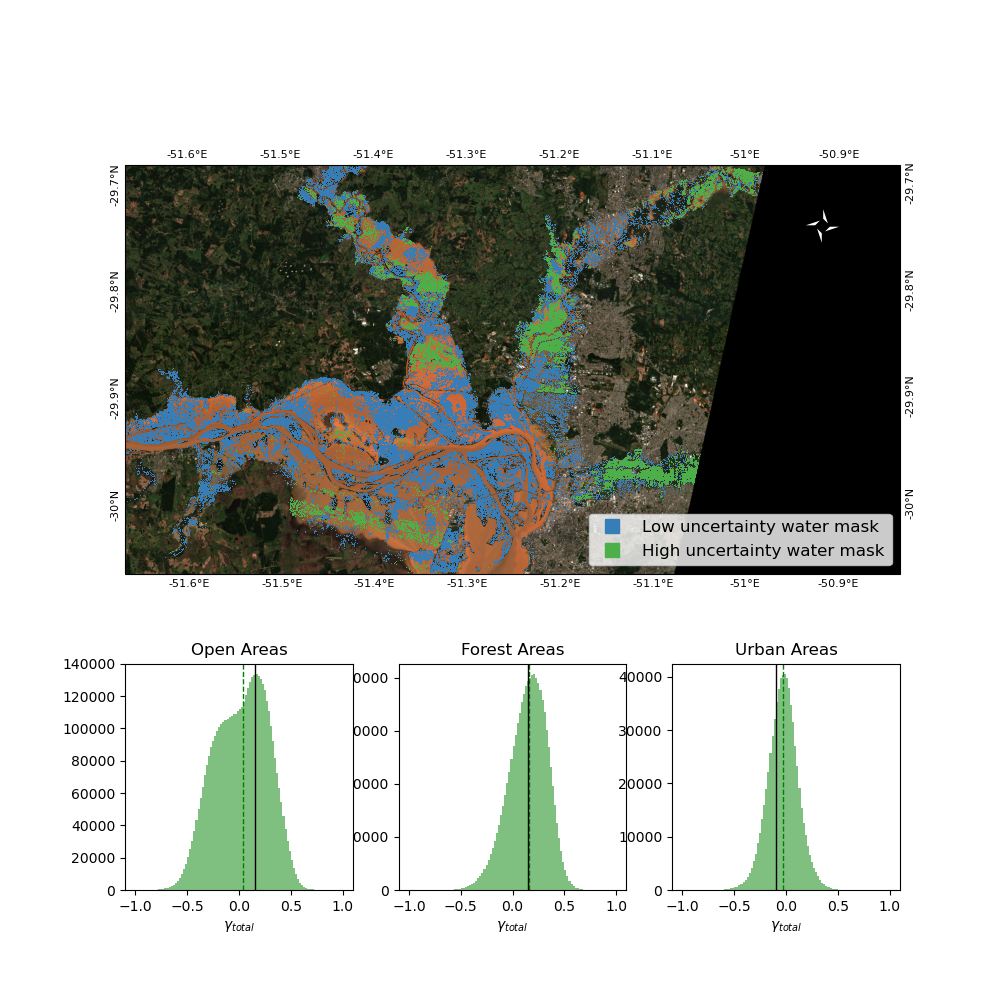

In [29]:
from eomaps import Maps

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
index_raster = 1

diff_open = PortoAlegre_open_flooded_gamma_tot[index_raster] - PortoAlegre_open_mean_dry_gamma_tot
# axs[2, 0].hist(PortoAlegre_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
# axs[2, 0].axvline(np.nanmedian(PortoAlegre_open_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 0].hist(diff_open.flatten(), bins=100, alpha=0.5, label=f'difference {PortoAlegre_label_flooded_date[index_raster].strftime("%d-%m-%Y")} - dry mean', color='green', range=(-1,1))
axs[2, 0].axvline(np.nanmedian(diff_open), color='green', linestyle='dashed', linewidth=1)
axs[2, 0].axvline(0.15, color='black', linewidth=1)
# axs[2, 0].axvline(-0.2, color='black', linewidth=1)
axs[2, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')
axs[2, 0].plot([],[], color='black', linewidth=1, label='Threshold')
# axs[2, 0].legend()
axs[2, 0].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 0].set_title('Open Areas')

diff_forest = PortoAlegre_forest_flooded_gamma_tot[index_raster] - PortoAlegre_forest_mean_dry_gamma_tot
# axs[2, 1].hist(PortoAlegre_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
# axs[2, 1].axvline(np.nanmedian(PortoAlegre_forest_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 1].hist(diff_forest.flatten(), bins=100, alpha=0.5, label=f'Flooded', color='green', range=(-1,1))
axs[2, 1].axvline(np.nanmedian(diff_forest), color='green', linestyle='dashed', linewidth=1)
axs[2, 1].axvline(0.15, color='black', linewidth=1)
axs[2, 1].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 1].set_title('Forest Areas')

diff_urban = PortoAlegre_urban_flooded_gamma_tot[index_raster] - PortoAlegre_urban_mean_dry_gamma_tot
axs[2, 2].hist(diff_urban.flatten(), bins=100, alpha=0.5, label='Difference between dry and flooded', color='green', range=(-1,1))
axs[2, 2].axvline(np.nanmedian(diff_urban), color='green', linestyle='dashed', linewidth=1)
axs[2, 2].axvline(-0.1, color='black', linewidth=1)
axs[2, 2].plot([],[], color='black', linewidth=1, label='Threshold')
axs[2, 2].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 2].set_title('Urban Areas')

axs[0, 0].set_visible(False)
axs[0, 1].set_visible(False)
axs[0, 2].set_visible(False)
axs[1, 0].set_visible(False)
axs[1, 1].set_visible(False)
axs[1, 2].set_visible(False)


gs = axs[0, 0].get_gridspec()
for axx in axs[:2,:].flatten():
    axx.remove()

############################################################################################################
# Base Maps
m = Maps(crs=EPSG_32722,f=fig, ax=(3, 3, (1, 6)))

xmin, ymin, xmax, ymax = aoi2_PortoAleger.bounds
buffer = 0.0

m.set_extent(extents=[xmin-buffer, xmax+buffer, ymin-buffer, ymax+buffer], crs=4326)
g = m.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
gl = g.add_labels(fontsize=8, every = 2)
c = m.add_compass(style='compass', pos=(0.9, 0.85), scale=7)
# sc = m.add_scalebar()


############################################################################################################
# S2 DATA
m_bkg = m.new_layer()
file = '/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/S2A/S2A_merged_32722_20240506T131349.tif'
S2_file = rio.open(file)
S2_trfm = S2_file.transform
show(S2_file,transform=S2_trfm, ax=m_bkg.ax)


############################################################################################################
# Flood MASK
m_data = m.new_layer()

mask_open = np.logical_or(diff_open > 0.15, PortoAlegre_open_flooded_gamma_SNR[index_raster] < 0.5)
mask_forest = diff_forest > 0.15
mask_urban = diff_urban < -0.1
global_mask = (mask_open | mask_forest | mask_urban )*1.

# global_mask[global_mask == 0] = np.nan
# x, y = get_xy_from_transform(PortoAlegre_WC_tfrm, global_mask)
x, y = get_xy_from_transform(PortoAlegre_transform, global_mask[0])

mask_holes = (global_mask[0] == 0)*1

footprint = morphology.disk(2)
# res = morphology.white_tophat(global_mask[0], footprint) 
# mask_intersection = binary_erosion(global_mask[0] - res, structure=morphology.disk(2)).astype(float)
# mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(2)).astype(float)
# mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)
# print(mask_intersection.shape, x.shape, y.shape)

global_mask[global_mask==0] = np.nan
global_mask[0][global_mask[0] == 1] = 0.5 #0.75
global_mask[0][PortoAlegre_open_flooded_gamma_SNR[index_raster] < 0.5] = 1. # 0.25
print(np.unique(global_mask))

m_data.set_data(global_mask[0].T, x, y, crs=EPSG_32722, parameter=LABEL_GAMMA_TOT)
m_data.set_shape.raster()

from matplotlib import lines as mlines
from cmap import Colormap
# cm = Colormap('matplotlib:bwr').reversed() #
# cm = Colormap('colorbrewer:bupu_3').reversed() #
# cm = Colormap('colorbrewer:gnbu_3') #
# cm = Colormap('colorbrewer:pubu_3') #
cm = Colormap('colorbrewer:Set1_3') #
cm = cm.to_matplotlib()
print(cm)

m_data.plot_map(vmin=0, vmax=1, cmap=cm)

# m_data.show()


############################################################################################################
# SNR MASK
# m_mask = m.new_layer()
# mask_SNR = PortoAlegre_open_flooded_gamma_SNR[index_raster]<0.5
# mask_SNR = mask_SNR*1.
# mask_SNR[mask_SNR == 0] = np.nan
# print(np.unique(mask_SNR))
# m_mask.set_data(mask_SNR.T, x,y, crs=EPSG_32722, parameter=LABEL_GAMMA_TOT)
# m_mask.plot_map(cmap='coolwarm', alpha=1)

ax_ = m_data.ax
# cm = plt.cm.plasma
low = cm(90)
high = cm(255)
rect1 = mlines.Line2D([], [], marker="s", markersize=10, linewidth=0, color=(0.216,0.494,0.722))
rect2 = mlines.Line2D([], [], marker="s", markersize=10, linewidth=0, color=high)
ax_.legend((rect1, rect2), ('Low uncertainty water mask', 'High uncertainty water mask'), loc='lower right', fontsize=12)

# fig.set_tight_layout(True)
# fig.axes[-1].set_visible(False)
m_data.show()
plt.close("all")

In [13]:
#!/usr/bin/env python
import psutil
# gives a single float value
print(psutil.cpu_percent())
# gives an object with many fields
print( psutil.virtual_memory())
# you can convert that object to a dictionary 
dict(psutil.virtual_memory()._asdict())
# you can have the percentage of used RAM
print(psutil.virtual_memory().percent)
# you can calculate percentage of available memory
print(psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)


8.3
svmem(total=404576632832, available=349805453312, percent=13.5, used=52073164800, free=351062876160, active=684204032, inactive=41667088384, buffers=16384, cached=1440575488, shared=561164288, slab=898461696)
13.5
86.46158175557693


In [1]:
print("opening flooded")
EMSR692_flooded_rasters = [rio.open(f) for f in EMSR692_glob_flooded_rasters]
print("opening dry")
EMSR692_dry_rasters = [rio.open(f) for f in EMSR692_glob_dry_rasters]
print(EMSR692_flooded_rasters)

print(psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)

print("reading flooded")
EMSR692_flooded_gamma_tot = [reader.read(EMSR692_list_var.index('gamma_tot')+1) for reader in EMSR692_flooded_rasters]
print("reading dry")
EMSR692_dry_gamma_tot = [reader.read(EMSR692_list_var.index('gamma_tot')+1) for reader in EMSR692_dry_rasters]


print("Memory available:", psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)

print("treat flooded")
EMSR692_flooded_gamma_tot = np.where(EMSR692_flooded_gamma_tot == 0, np.nan, EMSR692_flooded_gamma_tot)
EMSR692_flooded_gamma_tot = np.where(EMSR692_flooded_gamma_tot == -9999, np.nan, EMSR692_flooded_gamma_tot)

print("Memory available:", psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)

print("treat dry")
print("Memory available:", psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)
for i in range(len(EMSR692_dry_gamma_tot)):
    EMSR692_dry_gamma_tot[i] = np.where(EMSR692_dry_gamma_tot[i] == 0, np.nan, EMSR692_dry_gamma_tot[i])
    EMSR692_dry_gamma_tot[i] = np.where(EMSR692_dry_gamma_tot[i] == -9999, np.nan, EMSR692_dry_gamma_tot[i])
    print("Memory available:", psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)
    print(np.unique(EMSR692_dry_gamma_tot[i]))
    
print("mean dry")
print("Memory available:", psutil.virtual_memory().available * 100 / psutil.virtual_memory().total)
EMSR692_dry_mean_gamma_tot = np.nanmean(EMSR692_dry_gamma_tot, axis=0)
del EMSR692_dry_gamma_tot

print("WC open and treat")
EMSR_WC = rio.open(EMSR692_ESA_WC_file, crs=EPSG_32634)
EMSR_WC = EMSR_WC.read(1)
EMSR_WC_trfm = EMSR_WC.transform

all_EMSR692_forest_mask = (EMSR_WC == 10)
all_EMSR692_urban_mask = (EMSR_WC == 50)
all_EMSR692_open_mask = (~all_EMSR692_forest_mask & ~all_EMSR692_urban_mask & ~(EMSR_WC == 80))

del EMSR_WC

print("mask data flooded")
EMSR692_flooded_gamma_tot_urban = np.where(all_EMSR692_urban_mask, EMSR692_flooded_gamma_tot[1], np.nan)
EMSR692_flooded_gamma_tot_forest = np.where(all_EMSR692_forest_mask, EMSR692_flooded_gamma_tot[1], np.nan)
EMSR692_flooded_gamma_tot_open = np.where(all_EMSR692_open_mask, EMSR692_flooded_gamma_tot[1], np.nan)

print("mask data dry")
EMSR692_dry_mean_gamma_tot_urban = np.where(all_EMSR692_urban_mask, EMSR692_dry_mean_gamma_tot, np.nan)
EMSR692_dry_mean_gamma_tot_forest = np.where(all_EMSR692_forest_mask, EMSR692_dry_mean_gamma_tot, np.nan)
EMSR692_dry_mean_gamma_tot_open = np.where(all_EMSR692_open_mask, EMSR692_dry_mean_gamma_tot, np.nan)

opening flooded


NameError: name 'EMSR692_glob_flooded_rasters' is not defined

In [ ]:
from eomaps import Maps

fig, axs = plt.subplots(3, 3, figsize=(10, 10))
index_raster = 0

diff_open = EMSR692_flooded_gamma_tot_open[index_raster] - EMSR692_dry_mean_gamma_tot_open
# axs[2, 0].hist(EMSR692_open_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry mean', color='red', range=(0,1))
# axs[2, 0].axvline(np.nanmedian(EMSR692_open_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 0].hist(diff_open.flatten(), bins=100, alpha=0.5, label=f'difference {EMSR692_label_flooded_date[index_raster].strftime("%d-%m-%Y")} - dry mean', color='green', range=(-1,1))
axs[2, 0].axvline(np.nanmedian(diff_open), color='green', linestyle='dashed', linewidth=1)
axs[2, 0].axvline(0.15, color='black', linewidth=1)
# axs[2, 0].axvline(-0.2, color='black', linewidth=1)
axs[2, 0].plot([],[], color='grey', linestyle='dashed', linewidth=1, label='Medians')
axs[2, 0].plot([],[], color='black', linewidth=1, label='Threshold')
# axs[2, 0].legend()
axs[2, 0].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 0].set_title('Open Areas')

diff_forest = EMSR692_flooded_gamma_tot_forest[index_raster] - EMSR692_dry_mean_gamma_tot_forest
# axs[2, 1].hist(EMSR692_forest_mean_dry_gamma_tot.flatten(), bins=100, alpha=0.5, label='Dry', color='red', range=(0,1))
# axs[2, 1].axvline(np.nanmedian(EMSR692_forest_mean_dry_gamma_tot), color='red', linestyle='dashed', linewidth=1)
axs[2, 1].hist(diff_forest.flatten(), bins=100, alpha=0.5, label=f'Flooded', color='green', range=(-1,1))
axs[2, 1].axvline(np.nanmedian(diff_forest), color='green', linestyle='dashed', linewidth=1)
axs[2, 1].axvline(0.15, color='black', linewidth=1)
axs[2, 1].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 1].set_title('Forest Areas')

diff_urban = EMSR692_flooded_gamma_tot_urban[index_raster] - EMSR692_dry_mean_gamma_tot_urban
axs[2, 2].hist(diff_urban.flatten(), bins=100, alpha=0.5, label='Difference between dry and flooded', color='green', range=(-1,1))
axs[2, 2].axvline(np.nanmedian(diff_urban), color='green', linestyle='dashed', linewidth=1)
axs[2, 2].axvline(-0.1, color='black', linewidth=1)
axs[2, 2].plot([],[], color='black', linewidth=1, label='Threshold')
axs[2, 2].set_xlabel(LABEL_GAMMA_TOT)
axs[2, 2].set_title('Urban Areas')

axs[0, 0].set_visible(False)
axs[0, 1].set_visible(False)
axs[0, 2].set_visible(False)
axs[1, 0].set_visible(False)
axs[1, 1].set_visible(False)
axs[1, 2].set_visible(False)


gs = axs[0, 0].get_gridspec()
for axx in axs[:2,:].flatten():
    axx.remove()

############################################################################################################
# Base Maps
m = Maps(crs=EPSG_32634,f=fig, ax=(3, 3, (1, 6)))

xmin, ymin, xmax, ymax = aoi2_EMSR692.bounds
buffer = 0.0

m.set_extent(extents=[xmin-buffer, xmax+buffer, ymin-buffer, ymax+buffer], crs=4326)
g = m.add_gridlines(lw=0.25, alpha=0.5, zorder=0)
gl = g.add_labels(fontsize=8, every = 2)
c = m.add_compass(style='compass', pos=(0.9, 0.85), scale=7)
# sc = m.add_scalebar()


############################################################################################################
# S2 DATA
# m_bkg = m.new_layer()
# file = '/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/Paper_SWOT/S2A/S2A_merged_32722_20240506T131349.tif'
# S2_file = rio.open(file)
# S2_trfm = S2_file.transform
# show(S2_file,transform=S2_trfm, ax=m_bkg.ax)


############################################################################################################
# Flood MASK
m_data = m.new_layer()

mask_open = diff_open > 0.15
mask_forest = diff_forest > 0.15
mask_urban = diff_urban < -0.1
global_mask = (mask_open | mask_forest | mask_urban )*1.

# global_mask[global_mask == 0] = np.nan
# x, y = get_xy_from_transform(EMSR692_WC_tfrm, global_mask)
x, y = get_xy_from_transform(EMSR692_transform, global_mask[0])

mask_holes = (global_mask[0] == 0)*1

footprint = morphology.disk(2)
# res = morphology.white_tophat(global_mask[0], footprint) 
# mask_intersection = binary_erosion(global_mask[0] - res, structure=morphology.disk(2)).astype(float)
# mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(2)).astype(float)
# mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)
print(mask_intersection.shape, x.shape, y.shape)

global_mask[global_mask==0] = np.nan
print(np.unique(global_mask))

m_data.set_data(EMSR692_flooded_gamma_tot[index_raster].T, x, y, crs=EPSG_32634, parameter=LABEL_GAMMA_TOT)
m_data.set_shape.raster()

m_data.plot_map(vmin=0, vmax=1, cmap='magma')

m_data.show()


############################################################################################################
# SNR MASK
# m_mask = m.new_layer()
# mask_SNR = EMSR692_open_flooded_gamma_SNR[index_raster]<0.5
# mask_SNR = mask_SNR*1.
# mask_SNR[mask_SNR == 0] = np.nan
# print(np.unique(mask_SNR))
# m_mask.set_data(mask_SNR.T, x,y, crs=EPSG_32634, parameter=LABEL_GAMMA_TOT)
# m_mask.plot_map(cmap='autumn', alpha=1)

# m_mask.show()

# Density masks

In [ ]:
from shapely.geometry import LineString
import seaborn as sns

def get_intersections(ln):
    f_ln = [[x,y] for x, y in zip(ln.lines[0].get_xdata(), ln.lines[0].get_ydata())]
    f_ln = np.array(f_ln)
    g_ln = [[x,y] for x, y in zip(ln.lines[1].get_xdata(), ln.lines[1].get_ydata())]
    g_ln = np.array(g_ln)
    f = LineString(f_ln)
    g = LineString(g_ln)
    intersection = f.intersection(g)
    x, y = [], []
    if intersection.geom_type == 'Point':
        x.append(intersection.x)
        y.append(intersection.y)
    elif intersection.geom_type == 'MultiPoint':
        for geo in intersection.geoms:
            x.append(geo.x)
            y.append(geo.y)
    return x, y

## Chinon

In [ ]:
def detect_threshold(flooded, dry, SNR, title, label, SNR_th = 0.6):
    print(f'>>> Processing {label.strftime("%Y/%m/%d")}')
    clean_dry = np.where(SNR>SNR_th, dry, np.nan)
    clean_flooded = np.where(SNR>SNR_th, flooded, np.nan)
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sns.kdeplot(clean_dry.flatten(), alpha=0.5, label='Dry mean', color='grey', ax=ax)
    ln = sns.kdeplot(clean_flooded.flatten(), alpha=0.5, label=f'Flooded mean ({label.strftime("%Y/%m/%d")})', color='red')
    median_dry = np.nanmedian(clean_dry.flatten())
    std_dry = np.nanstd(clean_dry.flatten())
    plt.axvline(np.nanmedian(clean_flooded.flatten()), color='red', linestyle='dashed', linewidth=1)
    plt.axvline(median_dry, color='grey', linestyle='dashed', linewidth=1)
    plt.axvline(median_dry + std_dry, color='grey', linestyle='dotted', linewidth=1)
    plt.axvline(median_dry - std_dry, color='grey', linestyle='dotted', linewidth=1)
    if np.nanmedian(clean_flooded.flatten()) > median_dry + std_dry or np.nanmedian(clean_flooded.flatten()) < median_dry - std_dry:
        x_intersections, y_instersections = get_intersections(ln)
        for x, y in zip(x_intersections, y_instersections):
            if x > median_dry + std_dry:
                x_th = x
                y_th = y
                ax.scatter(x, y, marker='*', color='green')
                ax.text(x+.01*x, y+.05*y, f'threshold={x:.2f}', fontsize=12, fontweight='bold')
    else:
        ax.text(0., 1., 'No threshold detected', fontsize=12, fontweight='bold')
        x_th, y_th = None, None
    fig.savefig(f'{FIGS_FOLDER}/{title}_{label.strftime("%Y%m%d")}.png', dpi=300)
    plt.close(fig)
    
    return x_th, y_th, np.nanmedian((clean_flooded - clean_dry))

print("Chinon")
Chinon_threshold_gamma_tot = []
diff_th_Chinon = []
x,y,diff_th = detect_threshold(Chinon_open_flooded_gamma_tot[0], Chinon_open_mean_dry_gamma_tot,     Chinon_open_flooded_gamma_SNR[0],  'detect_threshold_Chinon_open_flooded_gamma_tot',Chinon_label_flooded_date[0], SNR_th=0.65)
Chinon_threshold_gamma_tot.append((x,y))
diff_th_Chinon.append(diff_th)
x,y,diff_th = detect_threshold(Chinon_open_flooded_gamma_tot[1], Chinon_open_mean_dry_gamma_tot,     Chinon_open_flooded_gamma_SNR[1],  'detect_threshold_Chinon_open_flooded_gamma_tot',Chinon_label_flooded_date[1], SNR_th=0.65)
Chinon_threshold_gamma_tot.append((x,y))
diff_th_Chinon.append(diff_th)

x,y,diff_th = detect_threshold(Chinon_forest_flooded_gamma_tot[0], Chinon_forest_mean_dry_gamma_tot, Chinon_forest_flooded_gamma_SNR[0], 'detect_threshold_Chinon_forest_flooded_gamma_tot',Chinon_label_flooded_date[0], SNR_th=0.65)
Chinon_threshold_gamma_tot.append((x,y))
diff_th_Chinon.append(diff_th)
x,y,diff_th = detect_threshold(Chinon_forest_flooded_gamma_tot[1], Chinon_forest_mean_dry_gamma_tot, Chinon_forest_flooded_gamma_SNR[1], 'detect_threshold_Chinon_forest_flooded_gamma_tot',Chinon_label_flooded_date[1], SNR_th=0.65)
Chinon_threshold_gamma_tot.append((x,y))
diff_th_Chinon.append(diff_th)

x,y,diff_th = detect_threshold(Chinon_urban_flooded_gamma_tot[0], Chinon_urban_mean_dry_gamma_tot,   Chinon_urban_flooded_gamma_SNR[0], 'detect_threshold_Chinon_urban_flooded_gamma_tot',Chinon_label_flooded_date[0], SNR_th=0.65)
Chinon_threshold_gamma_tot.append((x,y))
diff_th_Chinon.append(diff_th)
x,y,diff_th = detect_threshold(Chinon_urban_flooded_gamma_tot[1], Chinon_urban_mean_dry_gamma_tot,   Chinon_urban_flooded_gamma_SNR[1], 'detect_threshold_Chinon_urban_flooded_gamma_tot',Chinon_label_flooded_date[1], SNR_th=0.65)
Chinon_threshold_gamma_tot.append((x,y))
diff_th_Chinon.append(diff_th)

print("Porto Alegre")
PortoAlegre_threshold_gamma_tot = []
diff_th_PortoAlegre= []
x,y,diff_th = detect_threshold(PortoAlegre_open_flooded_gamma_tot[0], PortoAlegre_open_mean_dry_gamma_tot,     PortoAlegre_open_flooded_gamma_SNR[0],   'detect_threshold_PortoAlegre_open_flooded_gamma_tot',PortoAlegre_label_flooded_date[0], SNR_th=0.65)
PortoAlegre_threshold_gamma_tot.append((x,y))
diff_th_PortoAlegre.append(diff_th)
x,y,diff_th = detect_threshold(PortoAlegre_open_flooded_gamma_tot[1], PortoAlegre_open_mean_dry_gamma_tot,     PortoAlegre_open_flooded_gamma_SNR[1],   'detect_threshold_PortoAlegre_open_flooded_gamma_tot',PortoAlegre_label_flooded_date[1], SNR_th=0.65)
PortoAlegre_threshold_gamma_tot.append((x,y))
diff_th_PortoAlegre.append(diff_th)

x,y,diff_th = detect_threshold(PortoAlegre_forest_flooded_gamma_tot[0], PortoAlegre_forest_mean_dry_gamma_tot, PortoAlegre_forest_flooded_gamma_SNR[0], 'detect_threshold_PortoAlegre_forest_flooded_gamma_tot',PortoAlegre_label_flooded_date[0], SNR_th=0.65)
PortoAlegre_threshold_gamma_tot.append((x,y))
diff_th_PortoAlegre.append(diff_th)
x,y,diff_th = detect_threshold(PortoAlegre_forest_flooded_gamma_tot[1], PortoAlegre_forest_mean_dry_gamma_tot, PortoAlegre_forest_flooded_gamma_SNR[1], 'detect_threshold_PortoAlegre_forest_flooded_gamma_tot',PortoAlegre_label_flooded_date[1], SNR_th=0.65)
PortoAlegre_threshold_gamma_tot.append((x,y))
diff_th_PortoAlegre.append(diff_th)

x,y,diff_th = detect_threshold(PortoAlegre_urban_flooded_gamma_tot[0], PortoAlegre_urban_mean_dry_gamma_tot,   PortoAlegre_urban_flooded_gamma_SNR[0],  'detect_threshold_PortoAlegre_urban_flooded_gamma_tot',PortoAlegre_label_flooded_date[0], SNR_th=0.65)
PortoAlegre_threshold_gamma_tot.append((x,y))
diff_th_PortoAlegre.append(diff_th)
x,y,diff_th = detect_threshold(PortoAlegre_urban_flooded_gamma_tot[1], PortoAlegre_urban_mean_dry_gamma_tot,   PortoAlegre_urban_flooded_gamma_SNR[1],  'detect_threshold_PortoAlegre_urban_flooded_gamma_tot',PortoAlegre_label_flooded_date[1], SNR_th=0.65)
PortoAlegre_threshold_gamma_tot.append((x,y))
diff_th_PortoAlegre.append(diff_th)


In [ ]:
index_raster = 1

Chinon_WC = Chinon_mask_WC.read(1)
# is forest
all_Chinon_forest_mask = (Chinon_WC == 10)
# is urban
all_Chinon_urban_mask = (Chinon_WC == 50)
# is not open water, not forest, not urban
all_Chinon_open_mask = (~all_Chinon_forest_mask & ~all_Chinon_urban_mask & ~(Chinon_WC == 80))


##################
# COH
gamma_tot = Chinon_flooded_rasters[index_raster].read(Chinon_list_var.index('gamma_tot')+1)
gamma_tot = pretreat_data(gamma_tot, 2)

gamma_tot_urban = np.where(all_Chinon_urban_mask, gamma_tot, np.nan)
gamma_tot_forest = np.where(all_Chinon_forest_mask, gamma_tot, np.nan)
gamma_tot_open = np.where(all_Chinon_open_mask, gamma_tot, np.nan)

gamma_tot_mean_dry = [reader.read(Chinon_list_var.index("gamma_tot")+1) for reader in Chinon_dry_rasters]
for i in range(len(gamma_tot_mean_dry)):
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == 0, np.nan, gamma_tot_mean_dry[i])
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == -9999, np.nan, gamma_tot_mean_dry[i])
gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)

mask_holes = np.zeros_like(gamma_tot)
mask_holes[np.isnan(gamma_tot)] = 1
# mask_holes[np.isnan(gamma_tot_mean_dry)] = 1

gamma_tot_mean_dry_urban = np.where(all_Chinon_urban_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_forest = np.where(all_Chinon_forest_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_open = np.where(all_Chinon_open_mask, gamma_tot_mean_dry, np.nan)

diff_open = gamma_tot_open - gamma_tot_mean_dry_open
diff_forest = gamma_tot_forest - gamma_tot_mean_dry_forest
diff_urban = gamma_tot_urban - gamma_tot_mean_dry_urban

fig, ax = plt.subplots(4, 3, figsize=(20, 15))
ax[0, 0].imshow(gamma_tot_open, cmap='viridis', vmin=0, vmax=1)
ax[0, 0].set_title('Open areas')
ax[0, 1].imshow(gamma_tot_forest, cmap='viridis', vmin=0, vmax=1)
ax[0, 1].set_title('Forest areas')
ax[0, 2].imshow(gamma_tot_urban, cmap='viridis', vmin=0, vmax=1)
ax[0, 2].set_title('Urban areas')

ax[2, 0].imshow(diff_open, cmap='viridis', vmin=-1, vmax=1)
ax[2, 0].set_title('Open areas - Dry mean')
ax[2, 1].imshow(diff_forest, cmap='viridis', vmin=-1, vmax=1)
ax[2, 1].set_title('Forest areas - Dry mean')
ax[2, 2].imshow(diff_urban, cmap='viridis', vmin=-1, vmax=1)
ax[2, 2].set_title('Urban areas - Dry mean')

mask_intersection_open = np.ones(gamma_tot.shape)*np.nan
# th_open = 0.24
# mask_intersection_open[diff_open > th_open] = 1
# mask_intersection_open[diff_open < th_open] = 0
th_open = 0.8 
mask_intersection_open[gamma_tot_open > th_open] = 1
mask_intersection_open[gamma_tot_open < th_open] = 0
ax[1,0].imshow(mask_intersection_open)
ax[1,0].set_title('Open areas threshold')

mask_intersection_forest = np.ones(gamma_tot.shape)*np.nan
th_forest = 0.8 #
mask_intersection_forest[gamma_tot_forest > th_forest] = 1
mask_intersection_forest[gamma_tot_forest < th_forest] = 0
# th_forest = 0.24
# mask_intersection_forest[diff_forest > th_forest] = 1
# mask_intersection_forest[diff_forest < th_forest] = 0
ax[1,1].imshow(mask_intersection_forest)
ax[1,1].set_title('Forest areas threshold')

mask_intersection_urban = np.ones(gamma_tot.shape)*np.nan
th_urban = 0
if diff_th_Chinon[4] > 0.1:
    th_urban = 0.8 #
    mask_intersection_urban[(gamma_tot_urban)>th_urban] = 1
    mask_intersection_urban[(gamma_tot_urban)<th_urban] = 0
    # th_urban = 0.24
    # mask_intersection_urban[(diff_urban)>th_urban] = 1
    # mask_intersection_urban[(diff_urban)<th_urban] = 0
ax[1,2].imshow(mask_intersection_urban)
ax[1,2].set_title('Urban areas threshold')

ax[3,0].hist(gamma_tot_open.flatten(), bins=100, alpha=0.5, label='Open areas', color='green')
ax[3,0].hist(gamma_tot_mean_dry_open.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,0].hist(diff_open.flatten(), bins=100, alpha=0.5, label='$\Delta$(Open areas - Dry mean)', color='blue')
ax[3,0].axvline(th_open, color='red', linestyle='dashed', linewidth=1)
ax[3,0].legend()
ax[3,0].set_title('Open areas histogram')

ax[3,1].hist(gamma_tot_forest.flatten(), bins=100, alpha=0.5, label='Forest areas', color='green')
ax[3,1].hist(gamma_tot_mean_dry_forest.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,1].hist(diff_forest.flatten(), bins=100, alpha=0.5, label='$\Delta$(Forest areas - Dry mean)', color='blue')
ax[3,1].axvline(th_forest, color='red', linestyle='dashed', linewidth=1)
ax[3,1].legend()
ax[3,1].set_title('Forest areas histogram')

ax[3,2].hist(gamma_tot_urban.flatten(), bins=100, alpha=0.5, label='Urban areas', color='green')
ax[3,2].hist(gamma_tot_mean_dry_urban.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,2].hist(diff_urban.flatten(), bins=100, alpha=0.5, label='$\Delta$(Urban areas - Dry mean)', color='blue')
ax[3,2].axvline(th_urban, color='red', linestyle='dashed', linewidth=1)
ax[3,2].legend()
ax[3,2].set_title('Urban areas histogram')

fig.savefig(f'{FIGS_FOLDER}/Chinon_intersection_mask_COH_{Chinon_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()

mask_intersection = np.zeros(gamma_tot.shape)
mask_intersection = np.where(np.logical_or(mask_intersection_open == 1, mask_intersection_forest == 1, mask_intersection_urban == 1), 1, mask_intersection)

# fig,ax = plt.subplots(1,1,figsize=(10,5))
# ax.imshow(mask_intersection)
# ax.set_title('Brut intersection mask')

fig,ax = plt.subplots(5,1,figsize=(10,25))

ax[0].imshow(mask_intersection)
ax[0].set_title('Brut intersection mask')

footprint = morphology.disk(2)
res = morphology.white_tophat(mask_intersection, footprint)
ax[1].imshow(mask_intersection - res)
ax[1].set_title('Remove White tophat - disk(2)')

# mask_intersection = binary_fill_holes(mask_intersection, structure=morphology.disk(1)).astype(float)
mask_intersection = binary_erosion(mask_intersection, structure=morphology.disk(2)).astype(float)
ax[2].imshow(mask_intersection)
ax[2].set_title('erosion - disk(2)')

mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(2)).astype(float)
ax[3].imshow(mask_intersection)
ax[3].set_title('dilatation - disk(2)')


mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)
ax[4].imshow(mask_intersection)
ax[4].set_title('Final binary mask')

fig.savefig(f'{FIGS_FOLDER}/Chinon_postreatment_intersection_mask_COH_{Chinon_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()

##################
# DELTA COH
gamma_tot = Chinon_flooded_rasters[index_raster].read(Chinon_list_var.index('gamma_tot')+1)
gamma_tot = pretreat_data(gamma_tot, 2)

gamma_tot_urban = np.where(all_Chinon_urban_mask, gamma_tot, np.nan)
gamma_tot_forest = np.where(all_Chinon_forest_mask, gamma_tot, np.nan)
gamma_tot_open = np.where(all_Chinon_open_mask, gamma_tot, np.nan)

gamma_tot_mean_dry = [reader.read(Chinon_list_var.index("gamma_tot")+1) for reader in Chinon_dry_rasters]
for i in range(len(gamma_tot_mean_dry)):
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == 0, np.nan, gamma_tot_mean_dry[i])
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == -9999, np.nan, gamma_tot_mean_dry[i])
gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)

mask_holes = np.zeros_like(gamma_tot)
mask_holes[np.isnan(gamma_tot)] = 1
mask_holes[np.isnan(gamma_tot_mean_dry)] = 1

gamma_tot_mean_dry_urban = np.where(all_Chinon_urban_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_forest = np.where(all_Chinon_forest_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_open = np.where(all_Chinon_open_mask, gamma_tot_mean_dry, np.nan)

diff_open = gamma_tot_open - gamma_tot_mean_dry_open
diff_forest = gamma_tot_forest - gamma_tot_mean_dry_forest
diff_urban = gamma_tot_urban - gamma_tot_mean_dry_urban

fig, ax = plt.subplots(4, 3, figsize=(20, 15))
ax[0, 0].imshow(gamma_tot_open, cmap='viridis', vmin=0, vmax=1)
ax[0, 0].set_title('Open areas')
ax[0, 1].imshow(gamma_tot_forest, cmap='viridis', vmin=0, vmax=1)
ax[0, 1].set_title('Forest areas')
ax[0, 2].imshow(gamma_tot_urban, cmap='viridis', vmin=0, vmax=1)
ax[0, 2].set_title('Urban areas')

ax[2, 0].imshow(diff_open, cmap='viridis', vmin=-1, vmax=1)
ax[2, 0].set_title('Open areas - Dry mean')
ax[2, 1].imshow(diff_forest, cmap='viridis', vmin=-1, vmax=1)
ax[2, 1].set_title('Forest areas - Dry mean')
ax[2, 2].imshow(diff_urban, cmap='viridis', vmin=-1, vmax=1)
ax[2, 2].set_title('Urban areas - Dry mean')

mask_intersection_open = np.ones(gamma_tot.shape)*np.nan
# th_open = 0.8 
th_open = 0.24
# th_open = threshold_otsu(gamma_tot_open[~np.isnan(gamma_tot_open)].flatten())
mask_intersection_open[diff_open > th_open] = 1
mask_intersection_open[diff_open < th_open] = 0
# mask_intersection_open[gamma_tot_open > th_open] = 1
# mask_intersection_open[gamma_tot_open < th_open] = 0
ax[1,0].imshow(mask_intersection_open)
ax[1,0].set_title('Open areas threshold')

mask_intersection_forest = np.ones(gamma_tot.shape)*np.nan
# th_forest = 0.8 #
th_forest = 0.24
# th_forest = threshold_otsu(gamma_tot_forest[~np.isnan(gamma_tot_forest)].flatten())
mask_intersection_forest[diff_forest > th_forest] = 1
mask_intersection_forest[diff_forest < th_forest] = 0
# mask_intersection_forest[gamma_tot_forest > th_forest] = 1
# mask_intersection_forest[gamma_tot_forest < th_forest] = 0
ax[1,1].imshow(mask_intersection_forest)
ax[1,1].set_title('Forest areas threshold')

mask_intersection_urban = np.ones(gamma_tot.shape)*np.nan
th_urban = 0
if diff_th_Chinon[4] > 0.1:
    # th_urban = 0.8 #
    th_urban = 0.24
    # th_urban = threshold_otsu(gamma_tot_forest[~np.isnan(gamma_tot_forest)].flatten())
    mask_intersection_urban[(diff_urban)>th_urban] = 1
    mask_intersection_urban[(diff_urban)<th_urban] = 0
    # mask_intersection_urban[(gamma_tot_urban)>th_urban] = 1
    # mask_intersection_urban[(gamma_tot_urban)<th_urban] = 0
ax[1,2].imshow(mask_intersection_urban)
ax[1,2].set_title('Urban areas threshold')

ax[3,0].hist(gamma_tot_open.flatten(), bins=100, alpha=0.5, label='Open areas', color='green')
ax[3,0].hist(gamma_tot_mean_dry_open.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,0].hist(diff_open.flatten(), bins=100, alpha=0.5, label='$\Delta$(Open areas - Dry mean)', color='blue')
ax[3,0].axvline(th_open, color='red', linestyle='dashed', linewidth=1)
ax[3,0].legend()
ax[3,0].set_title('Open areas histogram')

ax[3,1].hist(gamma_tot_forest.flatten(), bins=100, alpha=0.5, label='Forest areas', color='green')
ax[3,1].hist(gamma_tot_mean_dry_forest.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,1].hist(diff_forest.flatten(), bins=100, alpha=0.5, label='$\Delta$(Forest areas - Dry mean)', color='blue')
ax[3,1].axvline(th_forest, color='red', linestyle='dashed', linewidth=1)
ax[3,1].legend()
ax[3,1].set_title('Forest areas histogram')

ax[3,2].hist(gamma_tot_urban.flatten(), bins=100, alpha=0.5, label='Urban areas', color='green')
ax[3,2].hist(gamma_tot_mean_dry_urban.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,2].hist(diff_urban.flatten(), bins=100, alpha=0.5, label='$\Delta$(Urban areas - Dry mean)', color='blue')
ax[3,2].axvline(th_urban, color='red', linestyle='dashed', linewidth=1)
ax[3,2].legend()
ax[3,2].set_title('Urban areas histogram')

fig.savefig(f'{FIGS_FOLDER}/Chinon_intersection_mask_deltaCOH_{Chinon_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()


mask_intersection = np.zeros(gamma_tot.shape)
mask_intersection = np.where(np.logical_or(mask_intersection_open == 1, mask_intersection_forest == 1, mask_intersection_urban == 1), 1, mask_intersection)

# fig,ax = plt.subplots(1,1,figsize=(10,5))
# ax.imshow(mask_intersection)
# ax.set_title('Brut intersection mask')

fig,ax = plt.subplots(5,1,figsize=(10,25))

ax[0].imshow(mask_intersection)
ax[0].set_title('Brut intersection mask')

footprint = morphology.disk(2)
res = morphology.white_tophat(mask_intersection, footprint)
ax[1].imshow(mask_intersection - res)
ax[1].set_title('Remove White tophat - disk(2)')

# mask_intersection = binary_fill_holes(mask_intersection, structure=morphology.disk(1)).astype(float)
mask_intersection = binary_erosion(mask_intersection, structure=morphology.disk(2)).astype(float)
ax[2].imshow(mask_intersection)
ax[2].set_title('erosion - disk(2)')

mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(2)).astype(float)
ax[3].imshow(mask_intersection)
ax[3].set_title('dilatation - disk(2)')


mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)
ax[4].imshow(mask_intersection)
ax[4].set_title('Final binary mask')

fig.savefig(f'{FIGS_FOLDER}/Chinon_postreatment_intersection_mask_deltaCOH_{Chinon_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()

In [ ]:
# # gamma_tot = PortoAlegre_flooded_rasters[0].read(PortoAlegre_list_var.index('gamma_tot')+1)
# # gamma_SNR = PortoAlegre_flooded_rasters[0].read(PortoAlegre_list_var.index('gamma_SNR')+1)
# gamma_tot = Chinon_flooded_rasters[1].read(Chinon_list_var.index('gamma_tot')+1)
# gamma_SNR = Chinon_flooded_rasters[1].read(Chinon_list_var.index('gamma_SNR')+1)
# gamma_SNR = np.where(gamma_SNR == 0, np.nan, gamma_SNR)
# gamma_SNR = np.where(gamma_SNR == -9999, np.nan, gamma_SNR)
# gamma_SNR = np.where(gamma_SNR > 1, .1, gamma_SNR)
# gamma_SNR = np.where(gamma_SNR < .3, np.nan, gamma_SNR)
# gamma_tot = pretreat_data(gamma_tot, 2)
# # gamma_SNR = pretreat_data(gamma_SNR, 2)

# gamma_estimate = (gamma_tot/gamma_SNR)
# gamma_estimate = np.where(gamma_estimate > 1, np.nan, gamma_estimate)

In [ ]:
# plt.hist(gamma_tot.flatten(), bins=100, alpha=0.5, label='gamma_tot', color='green')
# plt.hist(gamma_SNR.flatten(), bins=100, alpha=0.5, label='gamma_SNR', color='blue')
# plt.hist(gamma_estimate.flatten(), bins=100, alpha=0.5, label='gamma_estimate', color='red')
# plt.legend()
# plt.show()

# plt.imshow(gamma_tot, cmap='viridis')
# plt.colorbar()
# plt.show()
# plt.close()
# plt.imshow(gamma_SNR, cmap='viridis')
# plt.colorbar()
# plt.show()
# plt.close()
# plt.imshow(gamma_estimate, cmap='viridis')
# plt.colorbar()
# plt.show()
# plt.close()


In [ ]:
index_raster = 1

PortoAlegre = PortoAlegre_mask_WC.read(1)
# is forest
all_PortoAlegre_forest_mask = (PortoAlegre == 10)
# is urban
all_PortoAlegre_urban_mask = (PortoAlegre == 50)
# is not open water, not forest, not urban
all_PortoAlegre_open_mask = (~all_PortoAlegre_forest_mask & ~all_PortoAlegre_urban_mask & ~(PortoAlegre == 80))


##################
# COH
gamma_tot = PortoAlegre_flooded_rasters[index_raster].read(PortoAlegre_list_var.index('gamma_tot')+1)
gamma_tot = pretreat_data(gamma_tot, 2)

gamma_tot_urban = np.where(all_PortoAlegre_urban_mask, gamma_tot, np.nan)
gamma_tot_forest = np.where(all_PortoAlegre_forest_mask, gamma_tot, np.nan)
gamma_tot_open = np.where(all_PortoAlegre_open_mask, gamma_tot, np.nan)

gamma_tot_mean_dry = [reader.read(PortoAlegre_list_var.index("gamma_tot")+1) for reader in PortoAlegre_dry_rasters]
for i in range(len(gamma_tot_mean_dry)):
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == 0, np.nan, gamma_tot_mean_dry[i])
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == -9999, np.nan, gamma_tot_mean_dry[i])
gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)

mask_holes = np.zeros_like(gamma_tot)
mask_holes[np.isnan(gamma_tot)] = 1
# mask_holes[np.isnan(gamma_tot_mean_dry)] = 1

gamma_tot_mean_dry_urban = np.where(all_PortoAlegre_urban_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_forest = np.where(all_PortoAlegre_forest_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_open = np.where(all_PortoAlegre_open_mask, gamma_tot_mean_dry, np.nan)

diff_open = gamma_tot_open - gamma_tot_mean_dry_open
diff_forest = gamma_tot_forest - gamma_tot_mean_dry_forest
diff_urban = gamma_tot_urban - gamma_tot_mean_dry_urban

fig, ax = plt.subplots(4, 3, figsize=(20, 15))
ax[0, 0].imshow(gamma_tot_open, cmap='viridis', vmin=0, vmax=1)
ax[0, 0].set_title('Open areas')
ax[0, 1].imshow(gamma_tot_forest, cmap='viridis', vmin=0, vmax=1)
ax[0, 1].set_title('Forest areas')
ax[0, 2].imshow(gamma_tot_urban, cmap='viridis', vmin=0, vmax=1)
ax[0, 2].set_title('Urban areas')

ax[2, 0].imshow(diff_open, cmap='viridis', vmin=-1, vmax=1)
ax[2, 0].set_title('Open areas - Dry mean')
ax[2, 1].imshow(diff_forest, cmap='viridis', vmin=-1, vmax=1)
ax[2, 1].set_title('Forest areas - Dry mean')
ax[2, 2].imshow(diff_urban, cmap='viridis', vmin=-1, vmax=1)
ax[2, 2].set_title('Urban areas - Dry mean')

mask_intersection_open = np.ones(gamma_tot.shape)*np.nan
th_open = 0.75
mask_intersection_open[gamma_tot_open > th_open] = 1
mask_intersection_open[gamma_tot_open < th_open] = 0
ax[1,0].imshow(mask_intersection_open)
ax[1,0].set_title('Open areas threshold')

mask_intersection_forest = np.ones(gamma_tot.shape)*np.nan
th_forest = 0.75
mask_intersection_forest[gamma_tot_forest > th_forest] = 1
mask_intersection_forest[gamma_tot_forest < th_forest] = 0
ax[1,1].imshow(mask_intersection_forest)
ax[1,1].set_title('Forest areas threshold')

mask_intersection_urban = np.ones(gamma_tot.shape)*np.nan
th_urban = 0.4 #
mask_intersection_urban[(gamma_tot_urban)<th_urban] = 1
mask_intersection_urban[(gamma_tot_urban)>th_urban] = 0
ax[1,2].imshow(mask_intersection_urban)
ax[1,2].set_title('Urban areas threshold')

ax[3,0].hist(gamma_tot_open.flatten(), bins=100, alpha=0.5, label='Open areas', color='green')
ax[3,0].hist(gamma_tot_mean_dry_open.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,0].hist(diff_open.flatten(), bins=100, alpha=0.5, label='$\Delta$(Open areas - Dry mean)', color='blue')
ax[3,0].axvline(th_open, color='red', linestyle='dashed', linewidth=1)
ax[3,0].legend()
ax[3,0].set_title('Open areas histogram')

ax[3,1].hist(gamma_tot_forest.flatten(), bins=100, alpha=0.5, label='Forest areas', color='green')
ax[3,1].hist(gamma_tot_mean_dry_forest.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,1].hist(diff_forest.flatten(), bins=100, alpha=0.5, label='$\Delta$(Forest areas - Dry mean)', color='blue')
ax[3,1].axvline(th_forest, color='red', linestyle='dashed', linewidth=1)
ax[3,1].legend()
ax[3,1].set_title('Forest areas histogram')

ax[3,2].hist(gamma_tot_urban.flatten(), bins=100, alpha=0.5, label='Urban areas', color='green')
ax[3,2].hist(gamma_tot_mean_dry_urban.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,2].hist(diff_urban.flatten(), bins=100, alpha=0.5, label='$\Delta$(Urban areas - Dry mean)', color='blue')
ax[3,2].axvline(th_urban, color='red', linestyle='dashed', linewidth=1)
ax[3,2].legend()
ax[3,2].set_title('Urban areas histogram')

fig.savefig(f'{FIGS_FOLDER}/PortoAlegre_intersection_mask_COH_{PortoAlegre_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()

mask_intersection = np.zeros(gamma_tot.shape)
mask_intersection = np.where(np.logical_or(mask_intersection_open == 1, mask_intersection_forest == 1, mask_intersection_urban == 1), 1, mask_intersection)

# fig,ax = plt.subplots(1,1,figsize=(10,5))
# ax.imshow(mask_intersection)
# ax.set_title('Brut intersection mask')

fig,ax = plt.subplots(5,1,figsize=(10,25))

ax[0].imshow(mask_intersection)
ax[0].set_title('Brut intersection mask')

footprint = morphology.disk(2)
res = morphology.white_tophat(mask_intersection, footprint)
ax[1].imshow(mask_intersection - res)
ax[1].set_title('Remove White tophat - disk(2)')

# mask_intersection = binary_fill_holes(mask_intersection, structure=morphology.disk(1)).astype(float)
mask_intersection = binary_erosion(mask_intersection, structure=morphology.disk(2)).astype(float)
ax[2].imshow(mask_intersection)
ax[2].set_title('erosion - disk(2)')

mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(2)).astype(float)
ax[3].imshow(mask_intersection)
ax[3].set_title('dilatation - disk(2)')


mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)
ax[4].imshow(mask_intersection)
ax[4].set_title('Final binary mask')

fig.savefig(f'{FIGS_FOLDER}/PortoAlegre_postreatment_intersection_mask_COH_{PortoAlegre_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()

##################
# DELTA COH
gamma_tot = PortoAlegre_flooded_rasters[index_raster].read(PortoAlegre_list_var.index('gamma_tot')+1)
gamma_tot = pretreat_data(gamma_tot, 2)

gamma_tot_urban = np.where(all_PortoAlegre_urban_mask, gamma_tot, np.nan)
gamma_tot_forest = np.where(all_PortoAlegre_forest_mask, gamma_tot, np.nan)
gamma_tot_open = np.where(all_PortoAlegre_open_mask, gamma_tot, np.nan)

gamma_tot_mean_dry = [reader.read(PortoAlegre_list_var.index("gamma_tot")+1) for reader in PortoAlegre_dry_rasters]
for i in range(len(gamma_tot_mean_dry)):
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == 0, np.nan, gamma_tot_mean_dry[i])
    gamma_tot_mean_dry[i] = np.where(gamma_tot_mean_dry[i] == -9999, np.nan, gamma_tot_mean_dry[i])
gamma_tot_mean_dry = np.nanmean(gamma_tot_mean_dry, axis=0)

mask_holes = np.zeros_like(gamma_tot)
mask_holes[np.isnan(gamma_tot)] = 1
mask_holes[np.isnan(gamma_tot_mean_dry)] = 1

gamma_tot_mean_dry_urban = np.where(all_PortoAlegre_urban_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_forest = np.where(all_PortoAlegre_forest_mask, gamma_tot_mean_dry, np.nan)
gamma_tot_mean_dry_open = np.where(all_PortoAlegre_open_mask, gamma_tot_mean_dry, np.nan)

diff_open = gamma_tot_open - gamma_tot_mean_dry_open
diff_forest = gamma_tot_forest - gamma_tot_mean_dry_forest
diff_urban = gamma_tot_urban - gamma_tot_mean_dry_urban

fig, ax = plt.subplots(4, 3, figsize=(20, 15))
ax[0, 0].imshow(gamma_tot_open, cmap='viridis', vmin=0, vmax=1)
ax[0, 0].set_title('Open areas')
ax[0, 1].imshow(gamma_tot_forest, cmap='viridis', vmin=0, vmax=1)
ax[0, 1].set_title('Forest areas')
ax[0, 2].imshow(gamma_tot_urban, cmap='viridis', vmin=0, vmax=1)
ax[0, 2].set_title('Urban areas')

ax[2, 0].imshow(diff_open, cmap='viridis', vmin=-1, vmax=1)
ax[2, 0].set_title('Open areas - Dry mean')
ax[2, 1].imshow(diff_forest, cmap='viridis', vmin=-1, vmax=1)
ax[2, 1].set_title('Forest areas - Dry mean')
ax[2, 2].imshow(diff_urban, cmap='viridis', vmin=-1, vmax=1)
ax[2, 2].set_title('Urban areas - Dry mean')

mask_intersection_open = np.ones(gamma_tot.shape)*np.nan
# th_open = 0.8 
th_open = 0.2
# th_open = threshold_otsu(gamma_tot_open[~np.isnan(gamma_tot_open)].flatten())
mask_intersection_open[diff_open > th_open] = 1
mask_intersection_open[diff_open < th_open] = 0
# mask_intersection_open[gamma_tot_open > th_open] = 1
# mask_intersection_open[gamma_tot_open < th_open] = 0
ax[1,0].imshow(mask_intersection_open)
ax[1,0].set_title('Open areas threshold')

mask_intersection_forest = np.ones(gamma_tot.shape)*np.nan
# th_forest = 0.8 #
th_forest = 0.2
# th_forest = threshold_otsu(gamma_tot_forest[~np.isnan(gamma_tot_forest)].flatten())
mask_intersection_forest[diff_forest > th_forest] = 1
mask_intersection_forest[diff_forest < th_forest] = 0
# mask_intersection_forest[gamma_tot_forest > th_forest] = 1
# mask_intersection_forest[gamma_tot_forest < th_forest] = 0
ax[1,1].imshow(mask_intersection_forest)
ax[1,1].set_title('Forest areas threshold')

mask_intersection_urban = np.ones(gamma_tot.shape)*np.nan
th_urban = 0
# th_urban = 0.8 #
th_urban = -0.25
# th_urban = threshold_otsu(gamma_tot_forest[~np.isnan(gamma_tot_forest)].flatten())
mask_intersection_urban[(diff_urban)<th_urban] = 1
mask_intersection_urban[(diff_urban)>th_urban] = 0
# mask_intersection_urban[(gamma_tot_urban)>th_urban] = 1
# mask_intersection_urban[(gamma_tot_urban)<th_urban] = 0
ax[1,2].imshow(mask_intersection_urban)
ax[1,2].set_title('Urban areas threshold')

ax[3,0].hist(gamma_tot_open.flatten(), bins=100, alpha=0.5, label='Open areas', color='green')
ax[3,0].hist(gamma_tot_mean_dry_open.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,0].hist(diff_open.flatten(), bins=100, alpha=0.5, label='$\Delta$(Open areas - Dry mean)', color='blue')
ax[3,0].axvline(th_open, color='red', linestyle='dashed', linewidth=1)
ax[3,0].legend()
ax[3,0].set_title('Open areas histogram')

ax[3,1].hist(gamma_tot_forest.flatten(), bins=100, alpha=0.5, label='Forest areas', color='green')
ax[3,1].hist(gamma_tot_mean_dry_forest.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,1].hist(diff_forest.flatten(), bins=100, alpha=0.5, label='$\Delta$(Forest areas - Dry mean)', color='blue')
ax[3,1].axvline(th_forest, color='red', linestyle='dashed', linewidth=1)
ax[3,1].legend()
ax[3,1].set_title('Forest areas histogram')

ax[3,2].hist(gamma_tot_urban.flatten(), bins=100, alpha=0.5, label='Urban areas', color='green')
ax[3,2].hist(gamma_tot_mean_dry_urban.flatten(), bins=100, alpha=0.5, label='Dry mean', color='grey')
ax[3,2].hist(diff_urban.flatten(), bins=100, alpha=0.5, label='$\Delta$(Urban areas - Dry mean)', color='blue')
ax[3,2].axvline(th_urban, color='red', linestyle='dashed', linewidth=1)
ax[3,2].legend()
ax[3,2].set_title('Urban areas histogram')

fig.savefig(f'{FIGS_FOLDER}/PortoAlegre_intersection_mask_deltaCOH_{PortoAlegre_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()


mask_intersection = np.zeros(gamma_tot.shape)
mask_intersection = np.where(np.logical_or(mask_intersection_open == 1, mask_intersection_forest == 1, mask_intersection_urban == 1), 1, mask_intersection)

# fig,ax = plt.subplots(1,1,figsize=(10,5))
# ax.imshow(mask_intersection)
# ax.set_title('Brut intersection mask')

fig,ax = plt.subplots(5,1,figsize=(10,25))

ax[0].imshow(mask_intersection)
ax[0].set_title('Brut intersection mask')

footprint = morphology.disk(2)
res = morphology.white_tophat(mask_intersection, footprint)
ax[1].imshow(mask_intersection - res)
ax[1].set_title('Remove White tophat - disk(2)')

# mask_intersection = binary_fill_holes(mask_intersection, structure=morphology.disk(1)).astype(float)
mask_intersection = binary_erosion(mask_intersection, structure=morphology.disk(2)).astype(float)
ax[2].imshow(mask_intersection)
ax[2].set_title('erosion - disk(2)')

mask_intersection = binary_dilation(mask_intersection,structure=morphology.disk(2)).astype(float)
ax[3].imshow(mask_intersection)
ax[3].set_title('dilatation - disk(2)')


mask_intersection = np.where(mask_holes == 1, np.nan, mask_intersection)
ax[4].imshow(mask_intersection)
ax[4].set_title('Final binary mask')

fig.savefig(f'{FIGS_FOLDER}/PortoAlegre_postreatment_intersection_mask_deltaCOH_{PortoAlegre_label_flooded_date[index_raster].strftime("%Y%m%d")}.png', dpi=300)
plt.close()

In [ ]:
from pylab import *
from scipy.optimize import curve_fit

data=gamma_tot_forest[~np.isnan(gamma_tot_forest)]
# data=gamma_tot_open[~np.isnan(gamma_tot_open)]
y,x,_=plt.hist(data,100,alpha=.3,label='data')

x=(x[1:]+x[:-1])/2 # for len(x)==len(y)
def gauss(x,mu,sigma,A):
    return A*exp(-(x-mu)**2/2/sigma**2)

def bimodal(x,mu1,sigma1,A1,mu2,sigma2,A2):
    return gauss(x,mu1,sigma1,A1)+gauss(x,mu2,sigma2,A2)
test_gauss = gauss(x,0.55,0.2,25000)
test_2gauss = gauss(x,0.95,.025,20000)
# plt.plot(x, test_gauss)
# plt.plot(x, test_2gauss)
expected=(0.55,0.2,25000,0.95,.025,20000)
params,cov=curve_fit(bimodal,x,y,expected)
sigma=sqrt(diag(cov))
plt.plot(x,bimodal(x,*params),color='red',lw=3,label='model')
legend()
print(params,'\n',sigma) 
plt.plot(x,gauss(x,params[0],params[1],params[2]),'b--',lw=2,label='1st gaussian')
plt.plot(x,gauss(x,params[3],params[4],params[5]),'g--',lw=2,label='2nd gaussian')

In [ ]:

print('Chinon: ', Chinon_label_flooded_date[0])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(Chinon_open_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(Chinon_open_flooded_gamma_tot[0].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(Chinon_open_mean_dry_gamma_tot)
median_flooded = np.nanmedian(Chinon_open_flooded_gamma_tot[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (Chinon_open_flooded_gamma_tot > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_forest_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(Chinon_forest_flooded_gamma_tot[0].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(Chinon_forest_mean_dry_gamma_tot)
median_flooded = np.nanmedian(Chinon_forest_flooded_gamma_tot[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (Chinon_forest_flooded_gamma_tot > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_urban_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(Chinon_urban_flooded_gamma_tot.flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(Chinon_urban_mean_dry_gamma_tot)
median_flooded = np.nanmedian(Chinon_urban_flooded_gamma_tot[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max([x for x in x_inter if x < median_dry])

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')

mask_intersection_urban = (Chinon_urban_flooded_gamma_tot < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[0], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[0], cmap='gray', vmin=0, vmax=1)

ax[0,1].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{Chinon_label_flooded_date[0].strftime("%Y%m%d")}_gamma_tot.png', dpi=300)
plt.close()


############################################################################################################################################################################
print('Chinon: ', Chinon_label_flooded_date[1])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(Chinon_open_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(Chinon_open_flooded_gamma_tot[1].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(Chinon_open_mean_dry_gamma_tot)
median_flooded = np.nanmedian(Chinon_open_flooded_gamma_tot[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (Chinon_open_flooded_gamma_tot > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[1], cmap='gray', vmin=0, vmax=1)
ax[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')

sns.kdeplot(Chinon_forest_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(Chinon_forest_flooded_gamma_tot[1].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(Chinon_forest_mean_dry_gamma_tot)
median_flooded = np.nanmedian(Chinon_forest_flooded_gamma_tot[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (Chinon_forest_flooded_gamma_tot > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[1], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_urban_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(Chinon_urban_flooded_gamma_tot[1].flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(Chinon_urban_mean_dry_gamma_tot)
median_flooded = np.nanmedian(Chinon_urban_flooded_gamma_tot[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max([x for x in x_inter if x < median_dry])

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')

mask_intersection_urban = (Chinon_urban_flooded_gamma_tot < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[1], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[1], cmap='gray', vmin=0, vmax=1)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{Chinon_label_flooded_date[1].strftime("%Y%m%d")}_gamma_tot.png', dpi=300)
plt.close()

In [ ]:
import seaborn as sns

print('Chinon: ', Chinon_label_flooded_date[0])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(Chinon_open_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(Chinon_open_flooded_coh[0].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(Chinon_open_mean_dry_coh)
median_flooded = np.nanmedian(Chinon_open_flooded_coh[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (Chinon_open_flooded_coh > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_forest_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(Chinon_forest_flooded_coh[0].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(Chinon_forest_mean_dry_coh)
median_flooded = np.nanmedian(Chinon_forest_flooded_coh[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (Chinon_forest_flooded_coh > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_urban_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(Chinon_urban_flooded_coh.flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(Chinon_urban_mean_dry_coh)
median_flooded = np.nanmedian(Chinon_urban_flooded_coh[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max([x for x in x_inter if x < median_dry])

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_PCOH, fontsize=20, fontweight='bold')

mask_intersection_urban = (Chinon_urban_flooded_coh < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[0], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[0], cmap='gray', vmin=0, vmax=1)

ax[0,1].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{Chinon_label_flooded_date[0].strftime("%Y%m%d")}_coh.png', dpi=300)
plt.close()


############################################################################################################################################################################
print('Chinon: ', Chinon_label_flooded_date[1])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(Chinon_open_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(Chinon_open_flooded_coh[1].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(Chinon_open_mean_dry_coh)
median_flooded = np.nanmedian(Chinon_open_flooded_coh[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (Chinon_open_flooded_coh > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[1], cmap='gray', vmin=0, vmax=1)
ax[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')

sns.kdeplot(Chinon_forest_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(Chinon_forest_flooded_coh[1].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(Chinon_forest_mean_dry_coh)
median_flooded = np.nanmedian(Chinon_forest_flooded_coh[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (Chinon_forest_flooded_coh > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[1], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_urban_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(Chinon_urban_flooded_coh[1].flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(Chinon_urban_mean_dry_coh)
median_flooded = np.nanmedian(Chinon_urban_flooded_coh[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
std_dry = np.nanstd(Chinon_urban_mean_dry_coh)
x_inter = max([x for x in x_inter if x < median_dry + std_dry])

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_PCOH, fontsize=20, fontweight='bold')

mask_intersection_urban = (Chinon_urban_flooded_coh < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[1], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[1], cmap='gray', vmin=0, vmax=1)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{Chinon_label_flooded_date[1].strftime("%Y%m%d")}_coh.png', dpi=300)
plt.close()

In [ ]:
import seaborn as sns

print('Chinon: ', Chinon_label_flooded_date[0])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(Chinon_open_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(Chinon_open_flooded_sig0[0].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(Chinon_open_mean_dry_sig0)
median_flooded = np.nanmedian(Chinon_open_flooded_sig0[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (Chinon_open_flooded_sig0 > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_forest_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(Chinon_forest_flooded_sig0[0].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(Chinon_forest_mean_dry_sig0)
median_flooded = np.nanmedian(Chinon_forest_flooded_sig0[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (Chinon_forest_flooded_sig0 > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_urban_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(Chinon_urban_flooded_sig0.flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(Chinon_urban_mean_dry_sig0)
median_flooded = np.nanmedian(Chinon_urban_flooded_sig0[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max([x for x in x_inter if x < median_dry])

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_SIG0, fontsize=20, fontweight='bold')

mask_intersection_urban = (Chinon_urban_flooded_sig0 < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[0], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[0], cmap='gray', vmin=0, vmax=1)

ax[0,1].set_title(f'Chinon: {Chinon_label_flooded_date[0].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{Chinon_label_flooded_date[0].strftime("%Y%m%d")}_sig0.png', dpi=300)
plt.close()


############################################################################################################################################################################
print('Chinon: ', Chinon_label_flooded_date[1])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(Chinon_open_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(Chinon_open_flooded_sig0[1].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(Chinon_open_mean_dry_sig0)
median_flooded = np.nanmedian(Chinon_open_flooded_sig0[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (Chinon_open_flooded_sig0 > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[1], cmap='gray', vmin=0, vmax=1)
ax[0, 1].set_title(f'Chinon: {Chinon_label_flooded_date[1].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')

sns.kdeplot(Chinon_forest_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(Chinon_forest_flooded_sig0[1].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(Chinon_forest_mean_dry_sig0)
median_flooded = np.nanmedian(Chinon_forest_flooded_sig0[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (Chinon_forest_flooded_sig0 > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[1], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(Chinon_urban_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(Chinon_urban_flooded_sig0[1].flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(Chinon_urban_mean_dry_sig0)
median_flooded = np.nanmedian(Chinon_urban_flooded_sig0[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
std_dry = np.nanstd(Chinon_urban_mean_dry_sig0)
try:
    x_inter = max([x for x in x_inter if x < median_dry+std_dry])
except:
    x_inter = np.nan                                          


ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_SIG0, fontsize=20, fontweight='bold')

mask_intersection_urban = (Chinon_urban_flooded_sig0 < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[1], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[1], cmap='gray', vmin=0, vmax=1)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{Chinon_label_flooded_date[1].strftime("%Y%m%d")}_sig0.png', dpi=300)
plt.close()

## Porto Alegre

In [ ]:
import seaborn as sns

print('PortoAlegre: ', PortoAlegre_label_flooded_date[0])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(PortoAlegre_open_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(PortoAlegre_open_flooded_gamma_tot[0].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(PortoAlegre_open_mean_dry_gamma_tot)
median_flooded = np.nanmedian(PortoAlegre_open_flooded_gamma_tot[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (PortoAlegre_open_flooded_gamma_tot > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_forest_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(PortoAlegre_forest_flooded_gamma_tot[0].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(PortoAlegre_forest_mean_dry_gamma_tot)
median_flooded = np.nanmedian(PortoAlegre_forest_flooded_gamma_tot[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (PortoAlegre_forest_flooded_gamma_tot > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_urban_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(PortoAlegre_urban_flooded_gamma_tot.flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(PortoAlegre_urban_mean_dry_gamma_tot)
median_flooded = np.nanmedian(PortoAlegre_urban_flooded_gamma_tot[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max(max([x for x in x_inter if x < median_dry]))[0]

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')

mask_intersection_urban = (PortoAlegre_urban_flooded_gamma_tot < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[0], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[0], cmap='gray', vmin=0, vmax=1)

ax[0,1].set_title(f'PortoAlegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{PortoAlegre_label_flooded_date[0].strftime("%Y%m%d")}_gamma_tot.png', dpi=300)
plt.close()


############################################################################################################################################################################
print('PortoAlegre: ', PortoAlegre_label_flooded_date[1])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(PortoAlegre_open_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(PortoAlegre_open_flooded_gamma_tot[1].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(PortoAlegre_open_mean_dry_gamma_tot)
median_flooded = np.nanmedian(PortoAlegre_open_flooded_gamma_tot[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (PortoAlegre_open_flooded_gamma_tot > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[1], cmap='gray', vmin=0, vmax=1)
ax[0, 1].set_title(f'PortoAlegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')

sns.kdeplot(PortoAlegre_forest_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(PortoAlegre_forest_flooded_gamma_tot[1].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(PortoAlegre_forest_mean_dry_gamma_tot)
median_flooded = np.nanmedian(PortoAlegre_forest_flooded_gamma_tot[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (PortoAlegre_forest_flooded_gamma_tot > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[1], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_urban_mean_dry_gamma_tot.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(PortoAlegre_urban_flooded_gamma_tot[1].flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(PortoAlegre_urban_mean_dry_gamma_tot)
median_flooded = np.nanmedian(PortoAlegre_urban_flooded_gamma_tot[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max(max([x for x in x_inter if x < median_dry]))[0]

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')

mask_intersection_urban = (PortoAlegre_urban_flooded_gamma_tot < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[1], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[1], cmap='gray', vmin=0, vmax=1)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{PortoAlegre_label_flooded_date[1].strftime("%Y%m%d")}_gamma_tot.png', dpi=300)
plt.close()

In [ ]:
import seaborn as sns

print('PortoAlegre: ', PortoAlegre_label_flooded_date[0])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(PortoAlegre_open_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(PortoAlegre_open_flooded_coh[0].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(PortoAlegre_open_mean_dry_coh)
median_flooded = np.nanmedian(PortoAlegre_open_flooded_coh[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (PortoAlegre_open_flooded_coh > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_forest_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(PortoAlegre_forest_flooded_coh[0].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(PortoAlegre_forest_mean_dry_coh)
median_flooded = np.nanmedian(PortoAlegre_forest_flooded_coh[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (PortoAlegre_forest_flooded_coh > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_urban_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(PortoAlegre_urban_flooded_coh.flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(PortoAlegre_urban_mean_dry_coh)
median_flooded = np.nanmedian(PortoAlegre_urban_flooded_coh[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max(max([x for x in x_inter if x < median_dry]))[0]

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_PCOH, fontsize=20, fontweight='bold')

mask_intersection_urban = (PortoAlegre_urban_flooded_coh < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[0], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[0], cmap='gray', vmin=0, vmax=1)

ax[0,1].set_title(f'PortoAlegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{PortoAlegre_label_flooded_date[0].strftime("%Y%m%d")}_coh.png', dpi=300)
plt.close()


############################################################################################################################################################################
print('PortoAlegre: ', PortoAlegre_label_flooded_date[1])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(PortoAlegre_open_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(PortoAlegre_open_flooded_coh[1].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(PortoAlegre_open_mean_dry_coh)
median_flooded = np.nanmedian(PortoAlegre_open_flooded_coh[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (PortoAlegre_open_flooded_coh > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[1], cmap='gray', vmin=0, vmax=1)
ax[0, 1].set_title(f'PortoAlegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')

sns.kdeplot(PortoAlegre_forest_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(PortoAlegre_forest_flooded_coh[1].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(PortoAlegre_forest_mean_dry_coh)
median_flooded = np.nanmedian(PortoAlegre_forest_flooded_coh[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (PortoAlegre_forest_flooded_coh > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[1], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_urban_mean_dry_coh.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(PortoAlegre_urban_flooded_coh[1].flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(PortoAlegre_urban_mean_dry_coh)
median_flooded = np.nanmedian(PortoAlegre_urban_flooded_coh[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max(max([x for x in x_inter if x < median_dry]))[0]

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_PCOH, fontsize=20, fontweight='bold')

mask_intersection_urban = (PortoAlegre_urban_flooded_coh < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[1], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[1], cmap='gray', vmin=0, vmax=1)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{PortoAlegre_label_flooded_date[1].strftime("%Y%m%d")}_coh.png', dpi=300)
plt.close()

In [ ]:
import seaborn as sns

print('PortoAlegre: ', PortoAlegre_label_flooded_date[0])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(PortoAlegre_open_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(PortoAlegre_open_flooded_sig0[0].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(PortoAlegre_open_mean_dry_sig0)
median_flooded = np.nanmedian(PortoAlegre_open_flooded_sig0[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (PortoAlegre_open_flooded_sig0 > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_forest_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(PortoAlegre_forest_flooded_sig0[0].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(PortoAlegre_forest_mean_dry_sig0)
median_flooded = np.nanmedian(PortoAlegre_forest_flooded_sig0[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (PortoAlegre_forest_flooded_sig0 > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[0], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_urban_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(PortoAlegre_urban_flooded_sig0.flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(PortoAlegre_urban_mean_dry_sig0)
median_flooded = np.nanmedian(PortoAlegre_urban_flooded_sig0[0])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max(max(max([x for x in x_inter if x < median_dry])))

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_SIG0, fontsize=20, fontweight='bold')

mask_intersection_urban = (PortoAlegre_urban_flooded_sig0 < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[0], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[0], cmap='gray', vmin=0, vmax=1)

ax[0,1].set_title(f'PortoAlegre: {PortoAlegre_label_flooded_date[0].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')
fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{PortoAlegre_label_flooded_date[0].strftime("%Y%m%d")}_sig0.png', dpi=300)
plt.close()


############################################################################################################################################################################
print('PortoAlegre: ', PortoAlegre_label_flooded_date[1])
fig, ax = plt.subplots(4, 2,figsize=(20, 30))

# get the value where the two curves intersect
sns.kdeplot(PortoAlegre_open_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[0, 0])
ln = sns.kdeplot(PortoAlegre_open_flooded_sig0[1].flatten(), label='Flooded', color='blue', ax=ax[0, 0])
median_dry = np.nanmedian(PortoAlegre_open_mean_dry_sig0)
median_flooded = np.nanmedian(PortoAlegre_open_flooded_sig0[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[0, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[0, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[0, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[0, 0].set_ylabel('Open areas', fontsize=20, fontweight='bold')

mask_intersection_open = (PortoAlegre_open_flooded_sig0 > x_inter)*1
ax[0, 1].imshow(mask_intersection_open[1], cmap='gray', vmin=0, vmax=1)
ax[0, 1].set_title(f'PortoAlegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")}', fontsize=20, fontweight='bold')

sns.kdeplot(PortoAlegre_forest_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[1, 0])
ln = sns.kdeplot(PortoAlegre_forest_flooded_sig0[1].flatten(), label='Flooded', color='blue', ax=ax[1, 0])
median_dry = np.nanmedian(PortoAlegre_forest_mean_dry_sig0)
median_flooded = np.nanmedian(PortoAlegre_forest_flooded_sig0[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = min([x for x in x_inter if x > median_dry])

ax[1, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[1, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[1, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[1, 0].set_ylabel('Forest areas', fontsize=20, fontweight='bold')

mask_intersection_forest = (PortoAlegre_forest_flooded_sig0 > x_inter)*1
ax[1, 1].imshow(mask_intersection_forest[1], cmap='gray', vmin=0, vmax=1)

sns.kdeplot(PortoAlegre_urban_mean_dry_sig0.flatten(), label='Dry', color='red', ax=ax[2, 0])
ln = sns.kdeplot(PortoAlegre_urban_flooded_sig0[1].flatten(), label='Flooded', color='blue', ax=ax[2, 0])
median_dry = np.nanmedian(PortoAlegre_urban_mean_dry_sig0)
median_flooded = np.nanmedian(PortoAlegre_urban_flooded_sig0[1])

# select where intersection is greater than median_dry
x_inter, y_inter = get_intersections(ln)
x_inter = max(max(max([x for x in x_inter if x < median_dry])))

ax[2, 0].axvline(median_dry, color='red', linestyle='dashed', linewidth=1, label='Dry median')
ax[2, 0].axvline(median_flooded, color='blue', linestyle='dashed', linewidth=1, label="Flooded median")
ax[2, 0].axvline(x_inter, color='black', linestyle='dashed', linewidth=1, label="Intersection between densities")
ax[2, 0].set_ylabel('Urban areas', fontsize=20, fontweight='bold')
ax[2, 0].set_xlabel(LABEL_SIG0, fontsize=20, fontweight='bold')

mask_intersection_urban = (PortoAlegre_urban_flooded_sig0 < x_inter)*1
ax[2, 1].imshow(mask_intersection_urban[1], cmap='gray', vmin=0, vmax=1)


gs = ax[3, 0].get_gridspec()
for axx in ax[3,:]:
    axx.remove()
bigax = fig.add_subplot(gs[3, :])
global_mask = (mask_intersection_open | mask_intersection_forest | mask_intersection_urban)*1
bigax.imshow(global_mask[1], cmap='gray', vmin=0, vmax=1)

fig.tight_layout()
fig.savefig(f'{FIGS_FOLDER}/density_intersection_C{PortoAlegre_label_flooded_date[1].strftime("%Y%m%d")}_sig0.png', dpi=300)
plt.close()

# OTHER

In [ ]:
PortoAlegre_flooded_rasters_height = np.array([raster.read(PortoAlegre_list_var.index('height')+1) for raster in PortoAlegre_flooded_rasters])

In [ ]:
lab_height = "Height [m]"
fig, axs = plt.subplots(3, 1, figsize=(10, 15))

PortoAlegre_DEM_FloodArea = np.where(PortoAlegre_DEM_FloodArea < 0, np.nan, PortoAlegre_DEM_FloodArea)
im=axs[0].imshow(PortoAlegre_DEM_FloodArea, vmin=0, vmax=100)
axs[0].set_title('Porto Alegre FABDEM')
fig.colorbar(im, ax=axs[0])
im=axs[1].imshow(PortoAlegre_flooded_rasters_height[1], vmin=0, vmax=100)
axs[1].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} height')
fig.colorbar(im, ax=axs[1])

diff = PortoAlegre_flooded_rasters_height[1] - PortoAlegre_DEM_FloodArea
diff = np.where(diff < 1, np.nan, diff)
diff = np.where(diff > 20, np.nan, diff)
im = axs[2].imshow(diff, vmin=1, vmax=20, cmap='seismic')
fig.colorbar(im, ax=axs[2])
axs[2].set_title(f'Porto Alegre: {PortoAlegre_label_flooded_date[1].strftime("%Y/%m/%d")} height diff')


In [ ]:
# Glob of dates
EMSR692_all_dates = glob.glob(f'{EMSR692_raster_PATH}/*.tif')
EMSR692_all_dates.sort()

EMSR692_all_dates = [date.split('/')[-1].split('.')[0] for date in EMSR692_all_dates]

EMSR692_all_rasters = [rio.open(f'{EMSR692_raster_PATH}/{date}.tif') for date in EMSR692_all_dates]
EMSR692_all_gamma_tot = [rio.mask.mask(raster, EMSR692_mask_flooded.geometry, crop=True)[0][EMSR692_list_var.index('gamma_tot')] for raster in EMSR692_all_rasters]

EMSR692_all_gamma_tot = np.where(EMSR692_all_gamma_tot == -9999, np.nan, EMSR692_all_gamma_tot)
EMSR692_all_gamma_tot = np.where(EMSR692_all_gamma_tot == 0, np.nan, EMSR692_all_gamma_tot)
EMSR692_all_gamma_tot = np.where(EMSR692_all_gamma_tot < 0, np.nan, EMSR692_all_gamma_tot)

EMSR692_delta_flooded_dry_gamma_tot = [gamma_tot - EMSR692_FloodArea_mean_dry_gamma_tot for gamma_tot in EMSR692_all_gamma_tot]
EMSR692_delta_flooded_dry_open_gamma_tot = [raster * (EMSR692_open_mask*1) for raster in EMSR692_delta_flooded_dry_gamma_tot]
EMSR692_delta_flooded_dry_forest_gamma_tot = [raster * (EMSR692_forest_mask*1) for raster in EMSR692_delta_flooded_dry_gamma_tot]
EMSR692_delta_flooded_dry_urban_gamma_tot = [raster * (EMSR692_urban_mask*1) for raster in EMSR692_delta_flooded_dry_gamma_tot]

EMSR692_delta_flooded_dry_gamma_tot = np.where(EMSR692_delta_flooded_dry_gamma_tot == 0, np.nan, EMSR692_delta_flooded_dry_gamma_tot)
EMSR692_delta_flooded_dry_open_gamma_tot = [np.where(raster[0] == 0, np.nan, raster) for raster in EMSR692_delta_flooded_dry_open_gamma_tot]
EMSR692_delta_flooded_dry_forest_gamma_tot = [np.where(raster[0]== 0, np.nan, raster) for raster in EMSR692_delta_flooded_dry_forest_gamma_tot]
EMSR692_delta_flooded_dry_urban_gamma_tot = [np.where(raster[0] == 0, np.nan, raster) for raster in EMSR692_delta_flooded_dry_urban_gamma_tot]


In [ ]:

gpk_lakeSP = gpd.read_file(lakeSP)
gpk_lakeSP[gpk_lakeSP.intersects(aoi2_EMSR692)]

In [ ]:
lake_id ='1320036143'
list_lakesp = glob.glob("/data/scratch/globc/bonassies/data/SWOT/Greece_EMSR692/*LakeSP_Obs*.zip")
list_lakesp.sort()

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
color = cm.get_cmap('viridis', len(list_lakesp))
color = color(range(len(list_lakesp)))

aoi = gpd.GeoDataFrame({'geometry': [aoi2_EMSR692],}, crs=4326).to_crs('EPSG:32735')
plt.xlim((aoi.bounds['minx'].values[0], aoi.bounds['maxx'].values[0]))
plt.ylim(aoi.bounds['miny'].values[0], aoi.bounds['maxy'].values[0])

for col, lakeSP in zip(color, list_lakesp):
    gpk_lakeSP = gpd.read_file(lakeSP)
    gpk_lakeSP  = gpk_lakeSP[gpk_lakeSP['lake_id'] == lake_id]
    gpk_lakeSP = gpk_lakeSP[gpk_lakeSP.intersects(aoi2_EMSR692)].to_crs("EPSG:32735")
    
    gpk_lakeSP.plot(linewidth=1, edgecolor=col, facecolor='none', ax=ax)
    print(gpk_lakeSP.wse)
    # for centro, obs in zip(gpk_lakeSP.centroid, gpk_lakeSP.obs_id):
    #     ax.text(centro.x, centro.y, obs)
    label = lakeSP.split('/')[-1].split('_')[-3].split('T')[0]
    ax.plot([],[], color=col, label=label)
    
    
# secur = list_lakesp[4]
# label_secur = secur.split('/')[-1].split('_')[-3].split('T')[0]
# gpk_lakeSP = gpd.read_file(secur)
# gpk_lakeSP = gpk_lakeSP[gpk_lakeSP['lake_id'] == lake_id]
# gpk_lakeSP = gpk_lakeSP[gpk_lakeSP.intersects(aoi2_EMSR692)].to_crs("EPSG:32735")
# gpk_lakeSP.plot(linewidth=1, edgecolor='red', facecolor='none', ax=ax, marker='X', markersize=5)
# ax.plot([],[], color='red', label=label_secur, marker='X', markersize=5)


plt.legend()
plt.show()

#GOOD : 20231006 20230410

In [ ]:
fig, ax = plt.subplots(3, len(EMSR692_glob_dry_rasters)//3+1, figsize=(15, 30))
axx = ax.flatten()

for i, dry_img in enumerate(EMSR692_glob_dry_rasters):
    dry = rio.open(dry_img).read(EMSR692_list_var.index('gamma_tot')+1)
    date = datetime.datetime.strptime(EMSR692_list_dry_dates[i], '%Y%m%d')
    show(dry, ax=axx[i], transform=rio.open(dry_img).transform, cmap='viridis', vmin=0, vmax=1)
    axx[i].set_title(date.strftime("%Y/%m/%d"))

fig.tight_layout()    

In [ ]:
if not os.path.exists(f'{FIGS_FOLDER}/Greece_EMSR692'):
    os.makedirs(f'{FIGS_FOLDER}/Greece_EMSR692')

for i in range(len(EMSR692_all_dates)):
    fig, ax = plt.subplots(3, 2, figsize=(10, 10))
    # fusion of the first column subplots
    gs = ax[0, 0].get_gridspec()
    for axx in ax[:,0]:
        axx.remove()
    bigax = fig.add_subplot(gs[:, 0])
    bigax.imshow(EMSR692_delta_flooded_dry_gamma_tot[i], vmin=-1, vmax=1)
    
    for yy in ax[:,1]:
        yy.axvline(0, color='grey',  linewidth=1)
        yy.axvline(-0.25, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(0.25, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-.5, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(.5, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-.75, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(.75, color='grey', linestyle='dotted', linewidth=1)

    ax[0,1].hist(EMSR692_delta_flooded_dry_open_gamma_tot[i].flatten(), bins=100, range=(-1,1), alpha=0.5)
    med = np.nanmedian(EMSR692_delta_flooded_dry_open_gamma_tot[i])
    ax[0,1].axvline(med, color='red', linestyle='dashed', linewidth=1, label='Median')
    ax[0,1].set_title('Open areas')

    ax[1,1].hist(EMSR692_delta_flooded_dry_forest_gamma_tot[i].flatten(), bins=100, range=(-1,1), alpha=0.5)
    med = np.nanmedian(EMSR692_delta_flooded_dry_forest_gamma_tot[i])
    ax[1,1].axvline(med, color='red', linestyle='dashed', linewidth=1, label='Median')
    ax[1,1].set_title('Forest areas')
    
    ax[2,1].hist(EMSR692_delta_flooded_dry_urban_gamma_tot[i].flatten(), bins=100, range=(-1,1), alpha=0.5)
    med = np.nanmedian(EMSR692_delta_flooded_dry_urban_gamma_tot[i])
    ax[2,1].axvline(med, color='red', linestyle='dashed', linewidth=1, label='Median')
    ax[2,1].set_title('Urban areas')
        
    str_date = datetime.datetime.strptime(EMSR692_all_dates[i].split('_')[-2].split('T')[0], '%Y%m%d').strftime('%Y/%m/%d')
    bigax.set_title(f'Delta {LABEL_GAMMA_TOT}: {str_date}')
    fig.tight_layout()
    
    fig.savefig(f'{FIGS_FOLDER}/Greece_EMSR692/delta_gamma_tot_{datetime.datetime.strptime(EMSR692_all_dates[i].split("_")[-2].split("T")[0], "%Y%m%d").strftime("%Y%m%d")}.png', dpi=300)
    plt.close(fig)

In [ ]:
nx_ax = 3
ny_ax = len(EMSR692_all_dates)
fig, ax = plt.subplots(ny_ax, nx_ax, figsize=(nx_ax*5, ny_ax*5))

for i, date in enumerate(EMSR692_all_dates):
    str_date = datetime.datetime.strptime(date.split('_')[-2].split('T')[0], '%Y%m%d').strftime('%Y/%m/%d')
    
    ax[i, 0].hist(EMSR692_delta_flooded_dry_open_gamma_tot[i].flatten(), range=(-1,1), bins=100)
    if i == 0:
        ax[i, 0].set_title(f'Open areas\n{str_date}')
    else:
        ax[i, 0].set_title(f'{str_date}')
    data_median = np.nanmedian(EMSR692_delta_flooded_dry_open_gamma_tot[i].flatten())
    ax[i, 0].axvline(data_median, color='red', linestyle='dashed', linewidth=1, label='Median')
    
    ax[i, 1].hist(EMSR692_delta_flooded_dry_forest_gamma_tot[i].flatten(), range=(-1,1), bins=100)
    if i == 0:
        ax[i, 1].set_title(f'Forest areas\n{str_date}')
    else:
        ax[i, 1].set_title(f'{str_date}')
    data_median = np.nanmedian(EMSR692_delta_flooded_dry_forest_gamma_tot[i].flatten())
    ax[i, 1].axvline(data_median, color='red', linestyle='dashed', linewidth=1, label='Median')
    
    ax[i, 2].hist(EMSR692_delta_flooded_dry_urban_gamma_tot[i].flatten(), range=(-1,1), bins=100)
    if i == 0:
        ax[i, 2].set_title(f'Urbans areas\n{str_date}')
    else:
        ax[i, 2].set_title(f'{str_date}')
    data_median = np.nanmedian(EMSR692_delta_flooded_dry_urban_gamma_tot[i].flatten())
    ax[i, 2].axvline(data_median, color='red', linestyle='dashed', linewidth=1, label='Median')

for i in range(ny_ax-1):
    ax[i,0].xaxis.set_visible(False)
    ax[i,1].xaxis.set_visible(False)
    ax[i,2].xaxis.set_visible(False)

for xx in axs:
    for yy in xx:
        yy.axvline(0, color='grey',  linewidth=1)
        yy.axvline(-0.25, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(0.25, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-.5, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(.5, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(-.75, color='grey', linestyle='dotted', linewidth=1)
        yy.axvline(.75, color='grey', linestyle='dotted', linewidth=1)
    
ax[ny_ax-1,0].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')
ax[ny_ax-1,1].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')
ax[ny_ax-1,2].set_xlabel(LABEL_GAMMA_TOT, fontsize=20, fontweight='bold')

fig.tight_layout()